In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
import os

import numpy as np

from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%cd {config.PROJECT_DIR}

%load_ext autoreload
%autoreload 2

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[07/01/26 13:03:33] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=247243;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=675435;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[07/01/26 13:03:34] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=564038;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=773210;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


E:\Masterarbeit\AttackerGNN
cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json has been deleted.
cache/evasion_global_attr.json has been deleted.
cache/evasion_global_adj/evasion_global_adj_1.pt has been deleted.
cache/evasion_global_attr/evasion_global_attr_1.pt has been deleted.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'
SEED = 0
TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 6
MINER = 'prbcd'  # 'lrbcd' or 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None  # e.g. 0.9 to cap top-10% hubs
PRBCD_BUDGET_FRACTION = 0.5
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05  # each subset = round(fraction × n_candidates)

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0  # neg:pos ratio for zero-label undersampling

[07/01/26 13:03:39] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=249850;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=61963;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Using custom random split ratios: (0.15, 0.1, 0.3)             ]8;id=274328;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=38504;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#195\195]8;;\

                    INFO     Unused node count: 1264                                        ]8;id=781982;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=87278;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#205\205]8;;\

                    INFO     Training set size: 422                                         ]8;id=278715;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=863339;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 281                                       ]8;id=938349;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=503782;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

...

[07/01/26 13:04:06] INFO                                                                                ]8;id=206554;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=414861;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.11823, loss_val: 0.41804, acc_train: 0.98341,               
                             acc_val: 0.85765                                                                      

[07/01/26 13:04:10] INFO                                                                                ]8;id=243483;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=102712;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.11827, loss_val: 0.43936, acc_train: 0.98815,               
                             acc_val: 0.85765                                                                      

[07/01/26 13:04:14] INFO     Test accuracy is 0.8564649820327759 with seed 0                ]8;id=205511;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=833600;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 2803285596816 acquired on cache\demo_custom_split.json.lock       ]8;id=564254;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=94514;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2803285596816 released on cache\demo_custom_split.json.lock       ]8;id=109035;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=345047;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

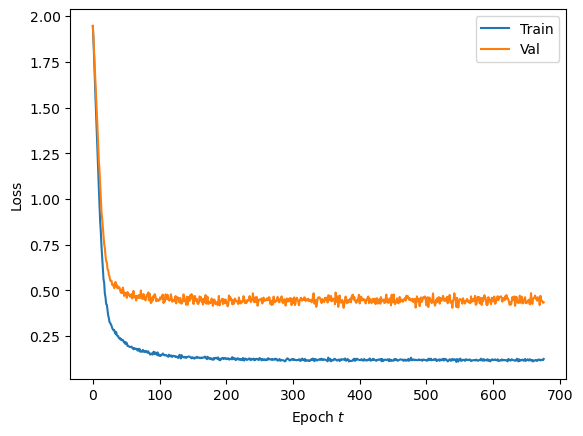

Accuracy of the model: 85.65%


GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)

In [3]:
import torch

train_statistics = experiment_train.run(
    data_dir='./data',
    dataset=DATASET,
    model_params=dict(
        label=MODEL_LABEL,
        model=MODEL_NAME,
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=DROPOUT_VICTIM,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64},
    ),
    train_params=dict(
        lr=LR_VICTIM,
        weight_decay=WEIGHT_DECAY_VICTIM,
        patience=PATIENCE_VICTIM,
        max_epochs=MAX_EPOCHS_VICTIM,
    ),
    binary_attr=False,
    make_undirected=True,
    seed=SEED,
    artifact_dir='cache',
    model_storage_type='demo_custom_split',
    ppr_cache_params=dict(),
    device="cpu",
    data_device="cpu",
    display_steps=100,
    debug_level="info",
    custom_split_ratios=(TRAIN_RATIO, VAL_RATIO, TEST_RATIO),
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
plt.show()

clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

model = train_statistics["model"]
graph = train_statistics["graph"]
idx_train = train_statistics["idx_train"]
idx_val = train_statistics["idx_val"]
idx_test = train_statistics["idx_test"]
model.eval()

In [4]:
import torch

attr_matrix, adj_matrix, labels_raw = graph[:3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Display ────────────────────────────────────────────────────────────────
n_nodes = adj_matrix.sizes()[0]
n_edges_directed = adj_matrix.nnz()
n_undirected = n_edges_directed // 2

print(f"nodes={n_nodes}")
print(f"Directed edges: {n_edges_directed}")
print(f"Undirected edges: {n_undirected}")
print(f"features={attr_matrix.shape}")
print(f"classes={len(torch.unique(labels_raw))}")

# ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
row, col, value = adj_matrix.coo()

edge_index = torch.stack([row, col], dim=0).long().to(device)

if value is None:
    edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
else:
    edge_weight = value.float().to(device)

# ── Convert features / labels ──────────────────────────────────────────────
attr = attr_matrix.float().to(device)
labels = labels_raw.long().to(device)

# ── Safety checks ──────────────────────────────────────────────────────────
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("max node id in edge_index:", int(edge_index.max()))
print("n_nodes:", n_nodes)

assert int(edge_index.max()) < n_nodes
assert attr.shape[0] == n_nodes
assert labels.shape[0] == n_nodes
'''
train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
    graph.labels,
    train_size=0.05,
    val_size=0.05,
    test_size=0.9,
    mode="stratified",
    seed=SEED,
)

train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

nodes=2810
Directed edges: 15962
Undirected edges: 7981
features=torch.Size([2810, 2879])
classes=7
edge_index shape: torch.Size([2, 15962])
edge_weight shape: torch.Size([15962])
max node id in edge_index: 2809
n_nodes: 2810


'\ntrain_idx_np, val_idx_np, test_idx_np = train_val_test_split(\n    graph.labels,\n    train_size=0.05,\n    val_size=0.05,\n    test_size=0.9,\n    mode="stratified",\n    seed=SEED,\n)\n\ntrain_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)\nval_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)\ntest_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'

In [5]:
from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
import random

# Fraction of the final pool that should come from PRBCD:
# 0.0 = entirely random
# 0.5 = half PRBCD, half random
# 1.0 = entirely PRBCD, provided enough unique PRBCD candidates exist
PRBCD_CANDIDATE_FRACTION = 0.5

if not 0.0 <= PRBCD_CANDIDATE_FRACTION <= 1.0:
    raise ValueError("PRBCD_CANDIDATE_FRACTION must be in [0, 1].")

# ── Candidate counts ────────────────────────────────────────────────────────

# Attack budget used in each PRBCD run.
budget = max(
    1,
    round(PRBCD_BUDGET_FRACTION * n_undirected),
)

# Keep the same total candidate-pool size as before:
# num_edges × budget_fraction × num_PRBCD_runs
n_total_candidates = max(
    1,
    round(
        n_undirected
        * PRBCD_BUDGET_FRACTION
        * N_PRBCD_RUNS * 2
    ),
)

rng = random.Random(SEED)


def sample_random_candidates(
    count: int,
    *,
    forbidden=None,
) -> set[tuple[int, int]]:
    """
    Sample unique unordered node pairs, excluding pairs in `forbidden`.
    Existing graph edges are allowed, so the result can contain both
    additions and removals.
    """
    forbidden = set() if forbidden is None else set(forbidden)

    n_possible = n_nodes * (n_nodes - 1) // 2
    n_available = n_possible - len(forbidden)

    if count > n_available:
        raise ValueError(
            f"Cannot sample {count} random candidates: only "
            f"{n_available} unordered pairs are available after exclusions."
        )

    sampled: set[tuple[int, int]] = set()

    while len(sampled) < count:
        u = rng.randrange(n_nodes)
        v = rng.randrange(n_nodes)

        if u == v:
            continue

        edge = (min(u, v), max(u, v))

        if edge in forbidden:
            continue

        sampled.add(edge)

    return sampled


# ── Mine and blend candidates ───────────────────────────────────────────────

prbcd_candidates: set[tuple[int, int]] = set()

if USE_PRBCD_CANDIDATES and PRBCD_CANDIDATE_FRACTION > 0.0:
    scorer = EndpointPRBCDV4Scorer(
        n=n_nodes,
        edge_index=edge_index,
        edge_weight=edge_weight,
        attr=attr,
        labels=labels,
        attacked_model=model,
        idx_attack=idx_test,
        test_idx=idx_val,
        device=device,
        block_size=PRBCD_SEARCH_SPACE,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
        n_subsets=N_SUBSETS,
        subset_fraction=SUBSET_FRACTION,
        balance_ratio=BALANCE_RATIO,
        store_candidates=True,
    )

    mined_candidates = scorer.mine_prbcd_endpoint_candidates(
        n_perturbations=budget,
        tag="endpointPRBCD",
        rng_seed=SEED,
        n_candidates=PRBCD_SEARCH_SPACE,
        prbcd_epochs=PRBCD_EPOCHS,
        n_prbcd_runs=N_PRBCD_RUNS,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
    )

    prbcd_candidates = {
        (min(int(u), int(v)), max(int(u), int(v)))
        for u, v in mined_candidates
        if int(u) != int(v)
    }


# Requested PRBCD count in the final pool.
if USE_PRBCD_CANDIDATES:
    n_prbcd_requested = round(
        PRBCD_CANDIDATE_FRACTION * n_total_candidates
    )
else:
    n_prbcd_requested = 0

# Select a reproducible subset if PRBCD mined more than needed.
if len(prbcd_candidates) > n_prbcd_requested:
    selected_prbcd = set(
        rng.sample(
            sorted(prbcd_candidates),
            n_prbcd_requested,
        )
    )
else:
    selected_prbcd = prbcd_candidates

# Any missing PRBCD candidates are automatically replaced by random ones.
n_random_needed = n_total_candidates - len(selected_prbcd)

random_candidates = sample_random_candidates(
    n_random_needed,
    forbidden=selected_prbcd,
)

candidate_set = selected_prbcd | random_candidates
candidates = list(candidate_set)

# Optional deterministic shuffle so PRBCD and random candidates are mixed.
rng.shuffle(candidates)


# ── Inspect mined / sampled candidates ──────────────────────────────────────

orig_edges = _edge_set(edge_index)

n_cands = len(candidates)
n_removals = sum(edge in orig_edges for edge in candidates)
n_adds = n_cands - n_removals

actual_prbcd_fraction = (
    len(selected_prbcd) / n_cands
    if n_cands > 0
    else 0.0
)

print(f"Candidates: {n_cands}")
print(
    f"Sources: {len(selected_prbcd)} PRBCD, "
    f"{len(random_candidates)} random "
    f"(actual PRBCD fraction={actual_prbcd_fraction:.3f})"
)
print(
    f"Actions: {n_adds} additions, "
    f"{n_removals} removals"
)

[endpointPRBCD] Mining actual endpointPRBCD flips: budget=3990, block=200000, epochs=5, runs=6
[endpointPRBCD] PRBCD run 1/6 (seed=0)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/01/26 13:04:17] INFO                                                           ]8;id=923356;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=901924;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.7095789313316345 Accuracy:                                   
                             85.646 %                                                                              
                                                                                                                   

[07/01/26 13:04:19] INFO                                                           ]8;id=175180;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=342803;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.7095 Accuracy: 81.851 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 1: 3990 flips, 3990 new, 3990 total unique
[endpointPRBCD] PRBCD run 2/6 (seed=1)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/01/26 13:04:36] INFO                                                           ]8;id=605600;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=391458;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.7095789313316345 Accuracy:                                   
                             85.646 %                                                                              
                                                                                                                   

...

[07/01/26 13:05:34] INFO                                                           ]8;id=684768;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=140601;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.7096 Accuracy: 81.732 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 5: 3990 flips, 3356 new, 18352 total unique
[endpointPRBCD] PRBCD run 6/6 (seed=5)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/01/26 13:05:47] INFO                                                           ]8;id=90331;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=264028;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.7095789313316345 Accuracy:                                   
                             85.646 %                                                                              
                                                                                                                   

[07/01/26 13:05:49] INFO                                                           ]8;id=132094;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=702761;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.7096 Accuracy: 81.732 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 6: 3990 flips, 3248 new, 21600 total unique
[endpointPRBCD] Mined 21600 unique actual PRBCD flips.
Candidates: 47886
Sources: 21600 PRBCD, 26286 random (actual PRBCD fraction=0.451)
Actions: 47710 additions, 176 removals


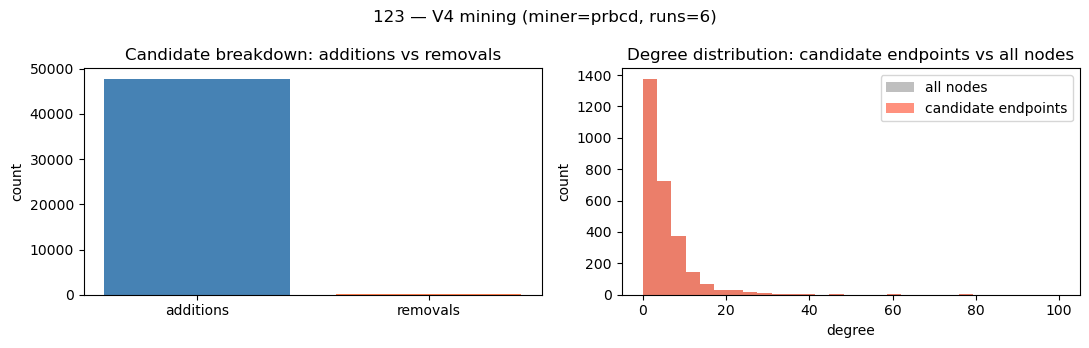

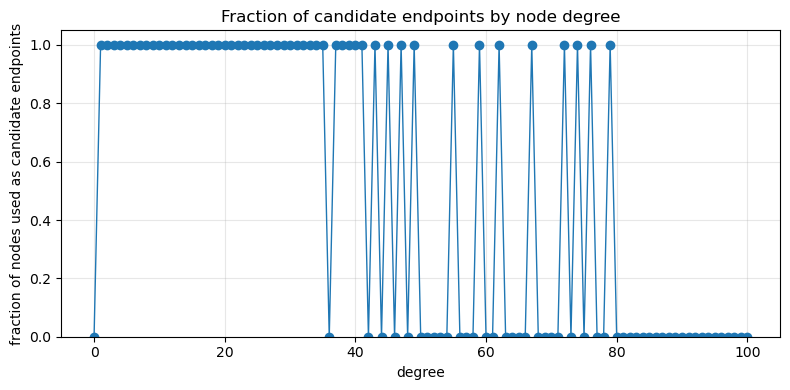

In [8]:
degrees    = np.bincount(edge_index[0].cpu().numpy(), minlength=n_nodes)
cand_nodes = set(u for u, v in candidates) | set(v for u, v in candidates)
cand_degs  = degrees[list(cand_nodes)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['additions', 'removals'], [n_adds, n_removals], color=['steelblue', 'coral'])
axes[0].set_title('Candidate breakdown: additions vs removals')
axes[0].set_ylabel('count')

bins = np.linspace(0, min(degrees.max(), 100), 30)
axes[1].hist(degrees,     bins=bins, alpha=0.5, label='all nodes',          color='grey')
axes[1].hist(cand_degs,   bins=bins, alpha=0.7, label='candidate endpoints', color='tomato')
axes[1].set_title('Degree distribution: candidate endpoints vs all nodes')
axes[1].set_xlabel('degree'); axes[1].set_ylabel('count'); axes[1].legend()

plt.suptitle(f'{123} — V4 mining (miner={MINER}, runs={N_PRBCD_RUNS})', fontsize=12)
plt.tight_layout()
plt.show()

# Fraction of nodes per degree that appear as candidate endpoints
all_degree_counts = np.bincount(degrees)

candidate_endpoint_mask = np.zeros(n_nodes, dtype=bool)
candidate_endpoint_mask[list(cand_nodes)] = True

candidate_degree_counts = np.bincount(
    degrees[candidate_endpoint_mask],
    minlength=len(all_degree_counts)
)

candidate_fraction_by_degree = np.divide(
    candidate_degree_counts,
    all_degree_counts,
    out=np.zeros_like(candidate_degree_counts, dtype=float),
    where=all_degree_counts > 0
)

# Optional: restrict to visible degree range
max_degree_plot = min(degrees.max(), 100)
degree_values = np.arange(max_degree_plot + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    degree_values,
    candidate_fraction_by_degree[:max_degree_plot + 1],
    marker="o",
    linewidth=1,
)

plt.title("Fraction of candidate endpoints by node degree")
plt.xlabel("degree")
plt.ylabel("fraction of nodes used as candidate endpoints")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("vor breakpoint")
print("nach breakpoint")

import sys
print(sys.executable)
print(sys.version)

vor breakpoint
nach breakpoint
E:\Anaconda\envs\Masterarbeit\python.exe
3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [10]:
from pathlib import Path

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    save_mining_output,
    load_mining_output,
    _dense_adj,
)

adj_orig    = _dense_adj(edge_index, n_nodes, device=device)
cand_src    = [u for u, v in candidates]
cand_dst    = [v for u, v in candidates]
exists_list = [float(adj_orig[u, v].item()) for u, v in candidates]

MINING_MODE = "endpoint"
CACHE_PATH = Path(
    "cache"
) / (
    f"candidate_mining_"
    f"mode-{MINING_MODE}_"
    f"seed-{SEED}_"
    f"candidates-{len(candidates)}.pt"
)

cache_metadata = {
    "mode": MINING_MODE,
    "seed": int(SEED),
    "n_nodes": int(n_nodes),
    "n_candidates": int(len(candidates)),
    "subset_fraction": float(SUBSET_FRACTION),
    "n_subsets": int(N_SUBSETS),
    "endpoint_require_correct_to_incorrect": True,
}


if CACHE_PATH.exists():
    mining_result, cached_candidates, stored_metadata = (
        load_mining_output(
            CACHE_PATH,
            device=device,
            expected_metadata=cache_metadata,
        )
    )

    # Optional additional safety check.
    if cached_candidates != candidates:
        raise ValueError(
            "The candidates in the cache differ from the "
            "current candidates."
        )

else:
    mining_result = mine_candidate_edge_scores(
        model=model,
        attr=attr,
        edge_index=edge_index,
        labels=labels,
        eval_idx=idx_test,
        candidates=candidates,
        n_nodes=n_nodes,
        mode=MINING_MODE,

        subset_fraction=SUBSET_FRACTION,
        n_subsets=N_SUBSETS,

        endpoint_k_samples=None,
        endpoint_require_correct_to_incorrect=True,

        two_hop_k_samples=None,

        seed=SEED,
        device=device,
        verbose=True,
    )

    save_mining_output(
        CACHE_PATH,
        mining_result,
        candidates=candidates,
        metadata=cache_metadata,
    )

labels_raw = mining_result["labels_raw"]
labels_norm = mining_result["labels_norm"]
clean_acc_v = mining_result["clean_accuracy"]

print(f"Clean test accuracy: {clean_acc_v:.4f}")


if MINING_MODE == "subset_accuracy_drop":
    drop_per_subset = mining_result["drop_per_subset"]
    subset_size = mining_result["subset_size"]

    max_raw = (
        float(labels_raw.max())
        if len(labels_raw) > 0
        else 0.0
    )

    n_pos = int((labels_norm > 0).sum())

    print(
        f"Subset size: {subset_size} "
        f"({SUBSET_FRACTION:.0%} of "
        f"{len(candidates)} candidates)"
    )

    print(f"\nSubsets run: {N_SUBSETS}")

    print(
        "Accuracy drop per subset: "
        f"mean={drop_per_subset.mean():.4f}  "
        f"max={drop_per_subset.max():.4f}  "
        f"zero_rate={(drop_per_subset == 0).mean():.2%}"
    )

    print(
        f"Edges with score > 0: "
        f"{n_pos}/{len(candidates)} "
        f"({100 * n_pos / len(candidates):.1f}%)"
    )

    print(
        f"Raw score stats: "
        f"max={max_raw:.4f}  "
        f"mean={labels_raw.mean():.4f}"
    )

elif MINING_MODE == "endpoint":
    endpoint_labels = np.asarray(
        mining_result["endpoint_labels"]
    )

    u_hit_labels = np.asarray(
        mining_result["u_hit_labels"]
    )

    v_hit_labels = np.asarray(
        mining_result["v_hit_labels"]
    )

    both_hit_labels = np.asarray(
        mining_result["both_hit_labels"]
    )

    sampled_edge_index = mining_result[
        "sampled_edge_index"
    ]

    n_selected = int(
        mining_result["n_samples"]
    )

    endpoint_hits = int(
        endpoint_labels.sum()
    )

    u_hits = int(
        u_hit_labels.sum()
    )

    v_hits = int(
        v_hit_labels.sum()
    )

    both_hits = int(
        both_hit_labels.sum()
    )

    n_positive = endpoint_hits

    endpoint_hit_rate = (
        endpoint_hits / n_selected
        if n_selected > 0
        else 0.0
    )

    print(
        f"Original candidate pairs evaluated: "
        f"{n_selected}"
    )

    print(
        f"Endpoint hits: "
        f"{endpoint_hits}/{n_selected} "
        f"({endpoint_hit_rate:.2%})"
    )

    print(
        f"u hits={u_hits}  "
        f"v hits={v_hits}  "
        f"both hits={both_hits}"
    )

    print(
        f"Positive endpoint labels: "
        f"{n_positive}/{n_selected}"
    )

    print(
        f"Candidate edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )

    assert sampled_edge_index.ndim == 2
    assert sampled_edge_index.shape[0] == 2
    assert sampled_edge_index.shape[1] == n_selected
    assert endpoint_labels.shape[0] == n_selected
    assert u_hit_labels.shape[0] == n_selected
    assert v_hit_labels.shape[0] == n_selected
    assert both_hit_labels.shape[0] == n_selected


elif MINING_MODE == "two_hop_correct_to_incorrect":
    sampled_edge_index = mining_result["sampled_edge_index"]

    n_samples = mining_result["n_samples"]
    n_unique_candidates = mining_result[
        "n_unique_candidates"
    ]

    positive_flips = mining_result["positive_flips"]

    total_correct_to_incorrect = mining_result[
        "total_correct_to_incorrect"
    ]

    mean_raw_score = mining_result["mean_raw_score"]
    raw_score_min = mining_result["raw_score_min"]
    raw_score_max = mining_result["raw_score_max"]

    mean_neighborhood_size = mining_result[
        "mean_neighborhood_size"
    ]

    neighborhood_sizes = mining_result[
        "neighborhood_sizes"
    ]

    print(
        f"Two-hop candidate edges evaluated: "
        f"{n_samples}/{n_unique_candidates}"
    )

    print(
        f"Flips causing at least one "
        f"correct-to-incorrect transition: "
        f"{positive_flips}/{n_samples} "
        f"({positive_flips / n_samples:.2%})"
    )

    print(
        f"Total correct-to-incorrect transitions: "
        f"{total_correct_to_incorrect}"
    )

    print(
        f"Raw score stats: "
        f"min={raw_score_min:.0f}  "
        f"max={raw_score_max:.0f}  "
        f"mean={mean_raw_score:.4f}"
    )

    print(
        f"Normalized score stats: "
        f"min={labels_norm.min():.4f}  "
        f"max={labels_norm.max():.4f}  "
        f"mean={labels_norm.mean():.4f}"
    )

    print(
        f"Mean two-hop union-neighborhood size: "
        f"{mean_neighborhood_size:.2f}"
    )

    print(
        f"Neighborhood-size range: "
        f"{neighborhood_sizes.min()}–"
        f"{neighborhood_sizes.max()}"
    )

    print(
        f"Sampled edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )


else:
    raise ValueError(
        f"Unknown MINING_MODE: {MINING_MODE}"
    )

[MINING CACHE] Loaded mining output from: cache\candidate_mining_mode-endpoint_seed-0_candidates-47886.pt
Clean test accuracy: 0.8565
Original candidate pairs evaluated: 47886
Endpoint hits: 9008/47886 (18.81%)
u hits=4858  v hits=4222  both hits=72
Positive endpoint labels: 9008/47886
Candidate edge tensor shape: (2, 47886)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Drop per subset over time
axes[0].plot(np.arange(1, N_SUBSETS + 1), drop_per_subset,
             marker='o', markersize=3, linewidth=1, color='steelblue')
axes[0].axhline(drop_per_subset.mean(), color='tomato', linestyle='--', linewidth=1.2,
                label=f'mean = {drop_per_subset.mean():.4f}')
axes[0].set_xlabel('subset index'); axes[0].set_ylabel('accuracy drop')
axes[0].set_title('Accuracy drop per sampled subset')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Distribution of accuracy drops
axes[1].hist(drop_per_subset, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('accuracy drop'); axes[1].set_ylabel('count')
axes[1].set_title('Distribution of per-subset accuracy drops')
axes[1].grid(True, alpha=0.3)

# Distribution of raw edge scores
axes[2].hist(labels_raw[labels_raw > 0], bins=30, color='tomato',
             edgecolor='white', label=f'scored ({n_pos})')
axes[2].set_xlabel('raw accumulated drop sum'); axes[2].set_ylabel('count')
axes[2].set_title(f'Per-edge raw score distribution  ({n_cands - n_pos} edges at 0 not shown)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{234} — V4 subset scoring  (n_subsets={N_SUBSETS}, subset_size={subset_size})', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'drop_per_subset' is not defined

---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [12]:
n_pos = int((labels_norm > 0).sum())

Label stats:
  min=0.0000  mean=0.1881  max=1.0000  std=0.3908
  Fraction with label > 0: 0.188
  Fraction with label > 0.5: 0.188


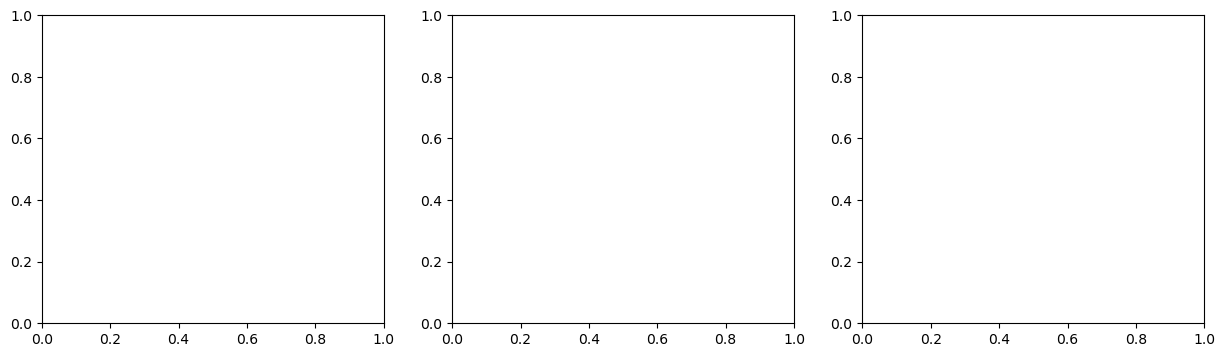

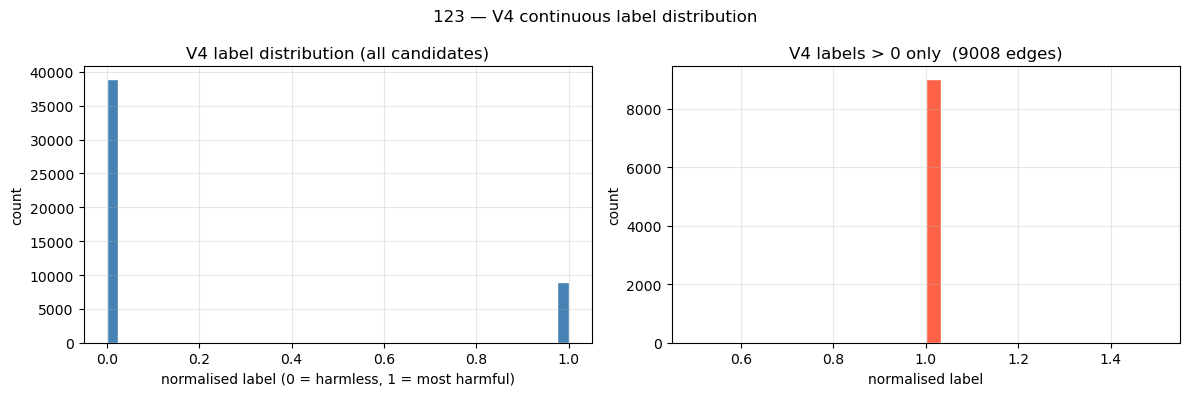

In [13]:
''# Convert to tensors for scorer use
src    = torch.tensor(cand_src,    dtype=torch.long,    device=device)
dst    = torch.tensor(cand_dst,    dtype=torch.long,    device=device)
labels_changed = torch.tensor(labels_norm, dtype=torch.float32, device=device)
exists = torch.tensor(exists_list, dtype=torch.float32, device=device)

print('Label stats:')
print(f'  min={float(labels_changed.min()):.4f}  mean={float(labels_changed.mean()):.4f}  '
      f'max={float(labels_changed.max()):.4f}  std={float(labels_changed.std()):.4f}')
print(f'  Fraction with label > 0: {(labels_changed > 0).float().mean():.3f}')
print(f'  Fraction with label > 0.5: {(labels_changed > 0.5).float().mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lbl_np = labels_changed.cpu().numpy()
axes[0].hist(lbl_np, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('normalised label (0 = harmless, 1 = most harmful)')
axes[0].set_ylabel('count')
axes[0].set_title('V4 label distribution (all candidates)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(lbl_np[lbl_np > 0], bins=30, color='tomato', edgecolor='white')
axes[1].set_xlabel('normalised label')
axes[1].set_ylabel('count')
axes[1].set_title(f'V4 labels > 0 only  ({n_pos} edges)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 continuous label distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [14]:
from helpers.selector_pipeline_helpers import accuracy
import pandas as pd

BLOCK_STEP_ORACLE = 10

sort_order = labels_changed.cpu().argsort(descending=True)
print(labels_changed[1])
print(labels_changed[2993])
print(labels_changed[3221])
all_idx = np.arange(n_cands)
block_sizes = list(range(0, n_cands, BLOCK_STEP_ORACLE))
if not block_sizes or block_sizes[-1] != n_cands:
    block_sizes.append(n_cands)

rng_o = np.random.default_rng(42)
rows_o = []

for k in block_sizes:
    # Top-k by V4 label
    adj_top = adj_orig.clone()
    if k > 0:
        for i in sort_order[:k].tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_top[u, v] = 1.0 - exists_list[i]
            adj_top[v, u] = 1.0 - exists_list[i]

    test_acc = accuracy(model, attr, labels, idx_test, edge_index=adj_top)

    rows_o.append({
        'k': k,
        'attack': 'top-k by V4 label',
        'test_accuracy': test_acc
    })

    # Random k from all candidates
    adj_rnd = adj_orig.clone()
    if k > 0:
        for i in rng_o.choice(all_idx, size=min(k, n_cands), replace=False).tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_rnd[u, v] = 1.0 - exists_list[i]
            adj_rnd[v, u] = 1.0 - exists_list[i]

    rows_o.append({
        'k': k,
        'attack': 'random candidates',
        'test_accuracy': accuracy(model, attr, labels, idx_test, edge_index=adj_rnd)
    })

oracle_df = pd.DataFrame(rows_o)
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').tail(20))

tensor(1.)
tensor(0.)
tensor(1.)


KeyboardInterrupt: 

In [12]:
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').head(20))

attack,random candidates,top-k by V4 label
k,,
0,0.856465,0.856465
10,0.855279,0.850534
20,0.856465,0.839858
30,0.855279,0.837485
40,0.849348,0.832740
50,0.849348,0.830368
60,0.848161,0.825623
70,0.852906,0.822064
80,0.837485,0.816133


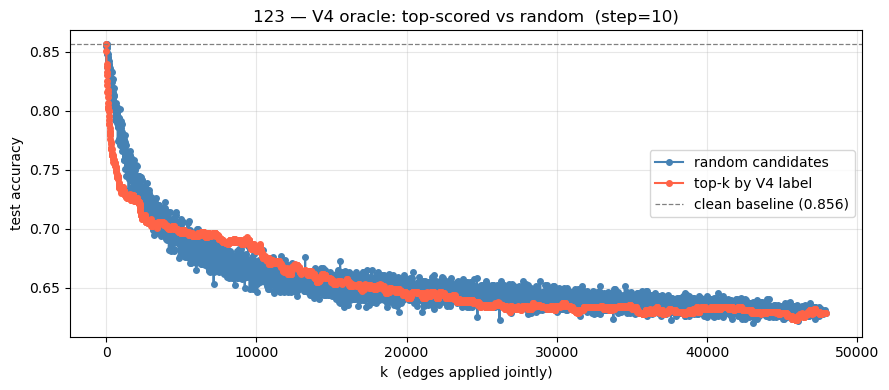

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for attack, grp in oracle_df.groupby('attack'):
    color = 'tomato' if 'V4' in attack else 'steelblue'
    ax.plot(grp['k'], grp['test_accuracy'], marker='o', markersize=4,
            label=attack, color=color)
ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=0.9,
           label=f'clean baseline ({clean_acc:.3f})')
ax.set_xlabel('k  (edges applied jointly)'); ax.set_ylabel('test accuracy')
ax.set_title(f'{123} — V4 oracle: top-scored vs random  (step={BLOCK_STEP_ORACLE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from helpers.selector_pipeline_helpers import train_link_prediction_gnn

LABEL_MODE = "continuous"  # "projected" or "continuous"
EXTREME_FRACTION = 0.2

attacker_x = attr
edge_index_struct = edge_index

scores = labels_changed.float().flatten()

valid_mask = torch.isfinite(scores)

src_valid = src[valid_mask]
dst_valid = dst[valid_mask]
scores_valid = scores[valid_mask]
exists_valid = exists[valid_mask]

if LABEL_MODE == "continuous":
    # Use the continuous values directly.
    src_bal = src_valid
    dst_bal = dst_valid
    lbl_bal = scores_valid
    ex_bal = exists_valid

elif LABEL_MODE == "projected":
    if not 0.0 < EXTREME_FRACTION <= 0.5:
        raise ValueError(
            "EXTREME_FRACTION must be between 0 and 0.5."
        )

    n_valid = scores_valid.numel()
    n_per_class = max(
        1,
        min(
            int(n_valid * EXTREME_FRACTION),
            n_valid // 2,
        ),
    )

    # Sort from lowest to highest score.
    order = torch.argsort(scores_valid)

    low_idx = order[:n_per_class]
    high_idx = order[-n_per_class:]

    # Lowest scores -> 0
    # Highest scores -> 1
    selected_idx = torch.cat([low_idx, high_idx])

    src_bal = src_valid[selected_idx]
    dst_bal = dst_valid[selected_idx]
    ex_bal = exists_valid[selected_idx]

    lbl_bal = torch.cat([
        torch.zeros(
            n_per_class,
            device=scores_valid.device,
            dtype=torch.float32,
        ),
        torch.ones(
            n_per_class,
            device=scores_valid.device,
            dtype=torch.float32,
        ),
    ])

else:
    raise ValueError(
        "LABEL_MODE must be 'continuous' or 'projected'."
    )

edge_index_bal = torch.stack(
    [src_bal.long(), dst_bal.long()],
    dim=0,
)

lbl_bal = lbl_bal.float()

lp_model = train_link_prediction_gnn(
    x=attacker_x,
    edge_index_struct=edge_index_struct,
    edge_index_lab=edge_index_bal,
    y_label=lbl_bal,
    device=device,
    num_epochs=500,
    hidden_dim=64,
    out_dim=64,
    lr=5e-4,
    weight_decay=5e-4,
    use_tqdm=True,
    verbose=True,

    early_stop=True,
    early_stop_metric="val_loss",
    min_epochs_before_early_stop=300,
    early_stop_patience=15,
    early_stop_min_delta=1e-4,
    restore_best=True,

    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    threshold=0.5,
)

[LP-GNN] Training:   0%|          | 0/500 [00:00<?, ?it/s]

[LP-GNN] Labeled pairs: M=47886 | mode=hard_binary | pos=9008 | neg=38878
[LP-GNN] Split strategy=threshold_stratified | train=33519 | val=7182 | test=7185


[LP-GNN] Training:   0%|          | 1/500 [00:00<02:31,  3.29it/s, tr_bce=1.1255, tr_obj=1.1987, va_loss=1.1255, va_mae=0.498, va_rmse=0.498, va_ap=0.198, va_auc=0.529, va_f1=0.000, pat=15]

[LP-GNN] Epoch 001/500 | train_bce=1.1256 | train_objective=1.1992 | val_loss=1.1256 | test_loss=1.1257 | val_mae=0.4972 | val_rmse=0.4972 | train_acc=0.8119 | val_acc=0.8119 | test_acc=0.8118 | val_precision=0.0000 | val_recall=0.0000 | val_f1=0.0000 | val_TP/FP/TN/FN=0/0/5831/1351 | val_R2=-0.6190 | val_Pearson=0.0286 | val_AUC=0.5276 | val_AP=0.1989 | best_val_loss=1.1256 (epoch 1) | patience_left=15 | new_best


[LP-GNN] Training:   4%|▍         | 20/500 [00:04<01:42,  4.70it/s, tr_bce=1.1254, tr_obj=1.1891, va_loss=1.1256, va_mae=0.516, va_rmse=0.517, va_ap=0.285, va_auc=0.651, va_f1=0.317, pat=15]

...

[LP-GNN] Epoch 460/500 | train_bce=0.3980 | train_objective=0.6640 | val_loss=0.5379 | test_loss=0.5423 | val_mae=0.2627 | val_rmse=0.3299 | train_acc=0.9197 | val_acc=0.8688 | test_acc=0.8714 | val_precision=0.6023 | val_recall=0.8912 | val_f1=0.7188 | val_TP/FP/TN/FN=1204/795/5036/147 | val_R2=0.2873 | val_Pearson=0.7295 | val_AUC=0.9440 | val_AP=0.8248 | best_val_loss=0.5379 (epoch 460) | patience_left=15 | new_best


[LP-GNN] Training:  96%|█████████▌| 480/500 [01:51<00:06,  3.28it/s, tr_bce=0.3943, tr_obj=0.6572, va_loss=0.5395, va_mae=0.267, va_rmse=0.336, va_ap=0.826, va_auc=0.944, va_f1=0.713, pat=10]

[LP-GNN] Epoch 480/500 | train_bce=0.3943 | train_objective=0.6572 | val_loss=0.5395 | test_loss=0.5426 | val_mae=0.2671 | val_rmse=0.3360 | train_acc=0.9155 | val_acc=0.8644 | test_acc=0.8664 | val_precision=0.5923 | val_recall=0.8956 | val_f1=0.7130 | val_TP/FP/TN/FN=1210/833/4998/141 | val_R2=0.2609 | val_Pearson=0.7263 | val_AUC=0.9441 | val_AP=0.8261 | best_val_loss=0.5367 (epoch 475) | patience_left=10


[LP-GNN] Training: 100%|██████████| 500/500 [01:56<00:00,  4.30it/s, tr_bce=0.3895, tr_obj=0.6514, va_loss=0.5401, va_mae=0.269, va_rmse=0.339, va_ap=0.828, va_auc=0.944, va_f1=0.711, pat=5] 

[LP-GNN] Epoch 500/500 | train_bce=0.3895 | train_objective=0.6514 | val_loss=0.5401 | test_loss=0.5432 | val_mae=0.2688 | val_rmse=0.3387 | train_acc=0.9141 | val_acc=0.8626 | test_acc=0.8635 | val_precision=0.5883 | val_recall=0.8971 | val_f1=0.7106 | val_TP/FP/TN/FN=1212/848/4983/139 | val_R2=0.2487 | val_Pearson=0.7251 | val_AUC=0.9441 | val_AP=0.8277 | best_val_loss=0.5350 (epoch 490) | patience_left=5
[LP-GNN] Restored best model from epoch 490 (val_loss=0.5350).
[LP-GNN] Training complete after 500 epoch(s). stop_reason=completed | label_mode=hard_binary | best_epoch=490 | best_val_loss=0.5350335240364075.


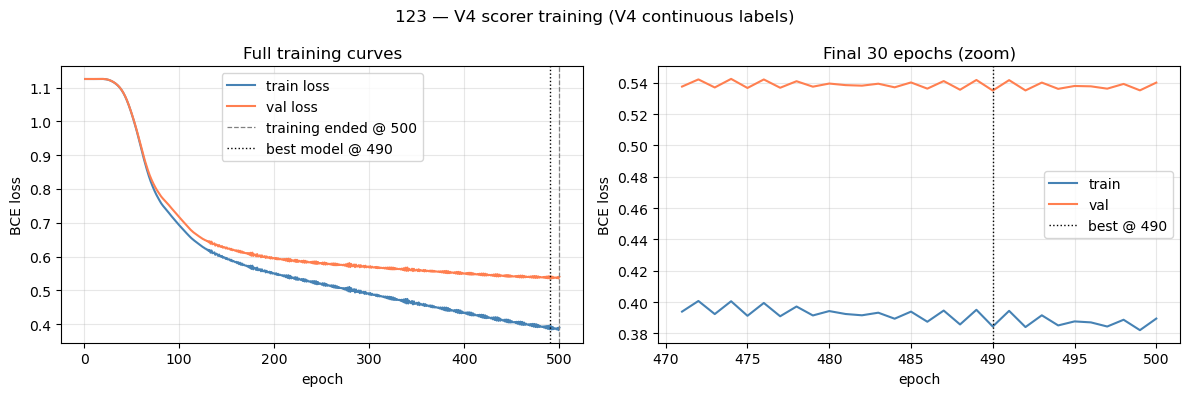

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Use `self.lp_model` inside the PRBCD class/notebook context.
# Replace with `model` when the returned model is stored under another name.
history = lp_model.training_history

train_losses = np.asarray(
    history["train_losses"],
    dtype=float,
)
val_losses = np.asarray(
    history["val_losses"],
    dtype=float,
)

stopped_at = int(history["stopped_at"])
best_epoch = history.get("best_epoch")
early_stopped = bool(history.get("early_stopped", False))

epochs_run = len(train_losses)

if epochs_run == 0:
    raise RuntimeError(
        "No completed training epochs are available for plotting."
    )

if len(val_losses) != epochs_run:
    raise RuntimeError(
        "train_losses and val_losses have different lengths: "
        f"{epochs_run} and {len(val_losses)}."
    )

ep_axis = np.arange(1, epochs_run + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

# ==========================================================
# Full training curves
# ==========================================================

axes[0].plot(
    ep_axis,
    train_losses,
    label="train loss",
    color="steelblue",
)

axes[0].plot(
    ep_axis,
    val_losses,
    label="val loss",
    color="coral",
)

stop_label = (
    f"early stop @ {stopped_at}"
    if early_stopped
    else f"training ended @ {stopped_at}"
)

axes[0].axvline(
    stopped_at,
    color="grey",
    linestyle="--",
    linewidth=0.9,
    label=stop_label,
)

if best_epoch is not None:
    axes[0].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best model @ {best_epoch}",
    )

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Full training curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================================
# Final epochs
# ==========================================================

z = min(30, epochs_run)

axes[1].plot(
    ep_axis[-z:],
    train_losses[-z:],
    label="train",
    color="steelblue",
)

axes[1].plot(
    ep_axis[-z:],
    val_losses[-z:],
    label="val",
    color="coral",
)

if best_epoch is not None and best_epoch >= ep_axis[-z]:
    axes[1].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best @ {best_epoch}",
    )

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("BCE loss")
axes[1].set_title(f"Final {z} epochs (zoom)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "123 — V4 scorer training (V4 continuous labels)",
    fontsize=12,
)

plt.tight_layout()
plt.show()

Random candidate pool:
  nodes:                    2,810
  all possible pairs:       3,946,645
  sampled candidates:       47,886
  edge-addition candidates: 47,794
  edge-deletion candidates: 92

Selector score statistics:
  min:    0.022799
  mean:   0.298336
  median: 0.209665
  max:    0.999367

Top 10 candidates predicted by the LP-GNN:


,rank,candidate_idx,src,dst,exists,action,selector_score
0,1,11909,1249,2063,0,add,0.999367
1,2,13763,218,1410,0,add,0.998205
2,3,3030,1901,2058,0,add,0.998054
3,4,15003,2063,2229,0,add,0.998025
4,5,16166,1509,2379,0,add,0.997896
5,6,17353,2643,2808,0,add,0.997749
6,7,12505,489,2063,0,add,0.997655
7,8,12226,406,861,0,add,0.997577
8,9,6436,1901,1916,0,add,0.997461
9,10,31173,231,1344,0,add,0.997278


,k,lp_gnn_accuracy,random_mean,random_std,random_min,random_max,lp_gnn_advantage
0,0,0.856465,0.856465,0.000000,0.856465,0.856465,0.000000
1,10,0.851720,0.856346,0.000673,0.855279,0.857651,0.004626
2,20,0.850534,0.856465,0.001250,0.854093,0.857651,0.005931
3,30,0.850534,0.856702,0.001090,0.855279,0.857651,0.006168
4,40,0.850534,0.857058,0.001281,0.854093,0.858837,0.006524
5,50,0.846975,0.857177,0.001601,0.854093,0.858837,0.010202
6,60,0.843416,0.856465,0.002166,0.852906,0.860024,0.013049
7,70,0.843416,0.856465,0.001479,0.855279,0.858837,0.013049
8,80,0.842230,0.855991,0.002251,0.852906,0.860024,0.013760
9,90,0.839858,0.856228,0.002488,0.851720,0.861210,0.016370


,k,lp_gnn_accuracy,random_mean,random_std,random_min,random_max,lp_gnn_advantage
4770,47700,0.73191,0.731079,0.001485,0.729537,0.734282,-0.000830
4771,47710,0.73191,0.731079,0.001587,0.729537,0.734282,-0.000830
4772,47720,0.73191,0.731079,0.001587,0.729537,0.734282,-0.000830
4773,47730,0.73191,0.731079,0.001587,0.729537,0.734282,-0.000830
4774,47740,0.73191,0.731198,0.001500,0.729537,0.734282,-0.000712
4775,47750,0.73191,0.731198,0.001500,0.729537,0.734282,-0.000712
4776,47760,0.73191,0.730961,0.001562,0.729537,0.734282,-0.000949
4777,47770,0.73191,0.730961,0.001347,0.729537,0.733096,-0.000949
4778,47780,0.73191,0.730961,0.001347,0.729537,0.733096,-0.000949
4779,47790,0.73191,0.730961,0.001347,0.729537,0.733096,-0.000949


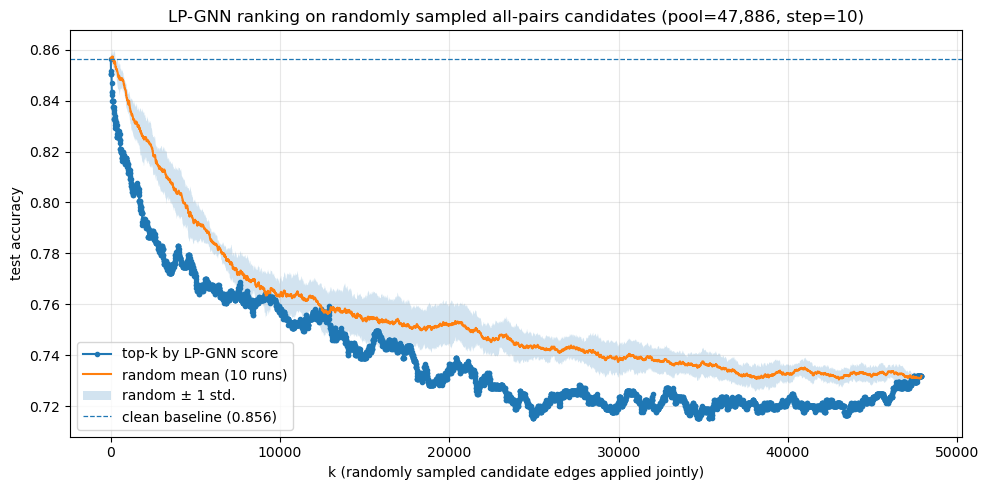

In [16]:
from helpers.selector_pipeline_helpers import accuracy

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ============================================================
# Configuration
# ============================================================

# Number of randomly sampled candidate edges.
N_RANDOM_CANDIDATES = n_cands

# Evaluate the cumulative attack every this many candidates.
BLOCK_STEP_SELECTOR = 10

# Batch size when scoring candidates with the LP-GNN.
SCORE_BATCH_SIZE = 100_000

# Several random orderings produce a more reliable baseline.
N_RANDOM_RUNS = 10

# Reproducibility.
RANDOM_SEED = 42
CANDIDATE_RANDOM_SEED = 123


# ============================================================
# Models
# ============================================================

# LP-GNN trained to prioritize harmful candidate edge flips.
selector_model = lp_model

# Original node-classification model whose accuracy is attacked.
victim_model = model

selector_device = next(
    selector_model.parameters()
).device


# ============================================================
# Random candidate sampling
# ============================================================

def sample_random_undirected_pairs(
    num_nodes: int,
    num_candidates: int,
    seed: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Uniformly sample unique undirected node pairs (u, v), where u < v.

    The complete set of N(N-1)/2 node pairs is never explicitly
    constructed.

    Returns
    -------
    cand_src:
        Source nodes of shape (num_candidates,).

    cand_dst:
        Destination nodes of shape (num_candidates,).
    """

    if num_nodes < 2:
        raise ValueError(
            "The graph must contain at least two nodes."
        )

    total_possible_edges = (
        num_nodes * (num_nodes - 1) // 2
    )

    num_candidates = min(
        int(num_candidates),
        total_possible_edges,
    )

    if num_candidates <= 0:
        raise ValueError(
            "num_candidates must be greater than zero."
        )

    rng = random.Random(seed)

    # Sample unique positions from the flattened upper triangle.
    # range(...) does not construct a Python list containing all
    # possible edge indices.
    sampled_linear_indices = torch.tensor(
        rng.sample(
            range(total_possible_edges),
            num_candidates,
        ),
        dtype=torch.long,
    )

    # Upper-triangle row lengths:
    #
    # row 0 contains N-1 pairs
    # row 1 contains N-2 pairs
    # ...
    # row N-2 contains 1 pair
    row_lengths = torch.arange(
        num_nodes - 1,
        0,
        -1,
        dtype=torch.long,
    )

    # Starting flattened index of each upper-triangle row.
    #
    # For N=4:
    #
    # row 0: (0,1), (0,2), (0,3), start=0
    # row 1: (1,2), (1,3),        start=3
    # row 2: (2,3),               start=5
    row_starts = torch.zeros(
        num_nodes,
        dtype=torch.long,
    )

    row_starts[1:] = torch.cumsum(
        row_lengths,
        dim=0,
    )

    # Find the upper-triangle row belonging to every sampled
    # flattened index.
    cand_src = (
        torch.searchsorted(
            row_starts,
            sampled_linear_indices,
            right=True,
        )
        - 1
    )

    offset_within_row = (
        sampled_linear_indices
        - row_starts[cand_src]
    )

    cand_dst = (
        cand_src
        + 1
        + offset_within_row
    )

    assert torch.all(cand_src < cand_dst)
    assert cand_src.numel() == num_candidates
    assert cand_dst.numel() == num_candidates

    return cand_src, cand_dst


if adj_orig.ndim != 2:
    raise ValueError(
        "adj_orig must be a two-dimensional adjacency matrix."
    )

if adj_orig.size(0) != adj_orig.size(1):
    raise ValueError(
        "adj_orig must be square."
    )

num_nodes = int(adj_orig.size(0))

cand_src_t, cand_dst_t = sample_random_undirected_pairs(
    num_nodes=num_nodes,
    num_candidates=N_RANDOM_CANDIDATES,
    seed=CANDIDATE_RANDOM_SEED,
)

n_cands = cand_src_t.numel()

total_possible_edges = (
    num_nodes * (num_nodes - 1) // 2
)


# ============================================================
# Determine candidate actions
# ============================================================

# Move the candidate endpoints temporarily to the adjacency
# matrix device for indexing.
cand_src_adj = cand_src_t.to(adj_orig.device)
cand_dst_adj = cand_dst_t.to(adj_orig.device)

# exists_t = 1 means that the edge currently exists and should
# therefore be deleted.
#
# exists_t = 0 means that the edge is absent and should
# therefore be added.
exists_t = (
    adj_orig[cand_src_adj, cand_dst_adj] != 0
).to(
    device="cpu",
    dtype=torch.float32,
)

del cand_src_adj
del cand_dst_adj

candidate_edge_index = torch.stack(
    [cand_src_t, cand_dst_t],
    dim=0,
).to(selector_device)

n_add_candidates = int(
    (exists_t < 0.5).sum().item()
)

n_delete_candidates = int(
    (exists_t > 0.5).sum().item()
)

print(
    "Random candidate pool:"
    f"\n  nodes:                    {num_nodes:,}"
    f"\n  all possible pairs:       {total_possible_edges:,}"
    f"\n  sampled candidates:       {n_cands:,}"
    f"\n  edge-addition candidates: {n_add_candidates:,}"
    f"\n  edge-deletion candidates: {n_delete_candidates:,}"
)


# ============================================================
# Produce candidate scores with the trained LP-GNN
# ============================================================

selector_model.eval()

with torch.no_grad():
    # Compute node embeddings once using the clean graph.
    node_embeddings = selector_model.encoder(
        attr.to(selector_device),
        edge_index.to(selector_device),
    )

    selector_scores = torch.empty(
        n_cands,
        dtype=torch.float32,
        device=selector_device,
    )

    for start in range(
        0,
        n_cands,
        SCORE_BATCH_SIZE,
    ):
        end = min(
            start + SCORE_BATCH_SIZE,
            n_cands,
        )

        candidate_batch = candidate_edge_index[
            :,
            start:end,
        ]

        logits = selector_model.edge_head(
            node_embeddings,
            candidate_batch,
        ).view(-1)

        # The selector was trained using BCEWithLogitsLoss.
        selector_scores[start:end] = torch.sigmoid(
            logits
        )

selector_scores = selector_scores.cpu()

assert torch.isfinite(selector_scores).all(), (
    "The selector produced NaN or infinite candidate scores."
)

# Highest predicted harmfulness first.
sort_order = torch.argsort(
    selector_scores,
    descending=True,
)


# ============================================================
# Score diagnostics
# ============================================================

print(
    "\nSelector score statistics:"
    f"\n  min:    {selector_scores.min().item():.6f}"
    f"\n  mean:   {selector_scores.mean().item():.6f}"
    f"\n  median: {selector_scores.median().item():.6f}"
    f"\n  max:    {selector_scores.max().item():.6f}"
)

print(
    "\nTop 10 candidates predicted by the LP-GNN:"
)

top_examples = []

for rank, candidate_idx in enumerate(
    sort_order[:10].tolist(),
    start=1,
):
    edge_exists = (
        exists_t[candidate_idx].item() > 0.5
    )

    top_examples.append({
        "rank": rank,
        "candidate_idx": candidate_idx,
        "src": int(
            cand_src_t[candidate_idx].item()
        ),
        "dst": int(
            cand_dst_t[candidate_idx].item()
        ),
        "exists": int(edge_exists),
        "action": (
            "delete"
            if edge_exists
            else "add"
        ),
        "selector_score": float(
            selector_scores[candidate_idx].item()
        ),
    })

display(pd.DataFrame(top_examples))


# ============================================================
# Evaluation block sizes
# ============================================================

block_sizes = list(
    range(
        0,
        n_cands,
        BLOCK_STEP_SELECTOR,
    )
)

if not block_sizes or block_sizes[-1] != n_cands:
    block_sizes.append(n_cands)


# ============================================================
# Helper for applying a candidate flip
# ============================================================

def apply_candidate_flip(
    adjacency: torch.Tensor,
    candidate_idx: int,
) -> None:
    """
    Apply one undirected candidate edge flip in place.

    Existing edge:
        1 -> 0

    Missing edge:
        0 -> 1
    """

    u = int(
        cand_src_t[candidate_idx].item()
    )

    v = int(
        cand_dst_t[candidate_idx].item()
    )

    original_exists = float(
        exists_t[candidate_idx].item()
    )

    new_value = 1.0 - original_exists

    adjacency[u, v] = new_value
    adjacency[v, u] = new_value


# ============================================================
# Model-ranked cumulative attack
# ============================================================

rows = []

adj_selector = adj_orig.clone()
previous_k = 0

for k in block_sizes:
    # Apply only candidates newly included since the previous
    # evaluation point.
    newly_selected = sort_order[
        previous_k:k
    ].tolist()

    for candidate_idx in newly_selected:
        apply_candidate_flip(
            adj_selector,
            candidate_idx,
        )

    selector_acc = accuracy(
        victim_model,
        attr,
        labels,
        idx_test,
        edge_index=adj_selector,
    )

    rows.append({
        "k": k,
        "attack": "top-k by LP-GNN score",
        "run": 0,
        "test_accuracy": float(selector_acc),
    })

    previous_k = k


# ============================================================
# Random cumulative baselines
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

for random_run in range(N_RANDOM_RUNS):
    # A fixed random permutation per run ensures nested
    # candidate sets as k increases.
    random_order = rng.permutation(n_cands)

    adj_random = adj_orig.clone()
    previous_k = 0

    for k in block_sizes:
        newly_selected = random_order[
            previous_k:k
        ].tolist()

        for candidate_idx in newly_selected:
            apply_candidate_flip(
                adj_random,
                candidate_idx,
            )

        random_acc = accuracy(
            victim_model,
            attr,
            labels,
            idx_test,
            edge_index=adj_random,
        )

        rows.append({
            "k": k,
            "attack": "random candidates",
            "run": random_run,
            "test_accuracy": float(random_acc),
        })

        previous_k = k


# ============================================================
# Data frames
# ============================================================

selector_df = pd.DataFrame(rows)

model_results = (
    selector_df[
        selector_df["attack"]
        == "top-k by LP-GNN score"
    ][
        ["k", "test_accuracy"]
    ]
    .rename(
        columns={
            "test_accuracy": "lp_gnn_accuracy",
        }
    )
)

random_summary = (
    selector_df[
        selector_df["attack"]
        == "random candidates"
    ]
    .groupby("k")["test_accuracy"]
    .agg(
        random_mean="mean",
        random_std="std",
        random_min="min",
        random_max="max",
    )
    .reset_index()
)

analysis_df = model_results.merge(
    random_summary,
    on="k",
    how="left",
)

analysis_df["lp_gnn_advantage"] = (
    analysis_df["random_mean"]
    - analysis_df["lp_gnn_accuracy"]
)

display(analysis_df.head(20))
display(analysis_df.tail(20))


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    analysis_df["k"],
    analysis_df["lp_gnn_accuracy"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="top-k by LP-GNN score",
)

ax.plot(
    analysis_df["k"],
    analysis_df["random_mean"],
    linewidth=1.5,
    label=(
        f"random mean "
        f"({N_RANDOM_RUNS} runs)"
    ),
)

random_lower = (
    analysis_df["random_mean"]
    - analysis_df["random_std"].fillna(0.0)
)

random_upper = (
    analysis_df["random_mean"]
    + analysis_df["random_std"].fillna(0.0)
)

ax.fill_between(
    analysis_df["k"],
    random_lower,
    random_upper,
    alpha=0.2,
    label="random ± 1 std.",
)

ax.axhline(
    clean_acc,
    linestyle="--",
    linewidth=0.9,
    label=f"clean baseline ({clean_acc:.3f})",
)

ax.set_xlabel(
    "k (randomly sampled candidate edges applied jointly)"
)

ax.set_ylabel(
    "test accuracy"
)

ax.set_title(
    "LP-GNN ranking on randomly sampled all-pairs candidates "
    f"(pool={n_cands:,}, step={BLOCK_STEP_SELECTOR})"
)

ax.legend()
ax.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [17]:
import torch
import numpy as np

# Your trained LinkPredictionGNN
scorer = lp_model
# Or:
# scorer = model

scorer.eval()

device = next(scorer.parameters()).device

# Node features used during scorer training
x_dev = attacker_x.to(device)

# Structural edges used by the GNN encoder
edge_index_struct_dev = edge_index.to(device)

# Candidate endpoint pairs to evaluate
src_dev = src.long().to(device)
dst_dev = dst.long().to(device)

if src_dev.numel() != dst_dev.numel():
    raise ValueError(
        f"src and dst must have equal length, got "
        f"{src_dev.numel()} and {dst_dev.numel()}."
    )

edge_index_lab_all = torch.stack(
    [src_dev, dst_dev],
    dim=0,
)

with torch.no_grad():
    all_logits = scorer(
        x_dev,
        edge_index_struct_dev,
        edge_index_lab_all,
    ).view(-1)

    all_probs = torch.sigmoid(all_logits)

all_logits_cpu = all_logits.cpu()
all_probs_cpu = all_probs.cpu()

labels_binary = labels_changed.view(-1).cpu() > 0

if labels_binary.numel() != all_logits_cpu.numel():
    raise ValueError(
        "labels_changed must contain one value per candidate pair. "
        f"Got {labels_binary.numel()} labels and "
        f"{all_logits_cpu.numel()} scorer outputs."
    )

pos_mask = labels_binary
neg_mask = ~labels_binary

pos_logits = all_logits_cpu[pos_mask]
neg_logits = all_logits_cpu[neg_mask]

pos_probs = all_probs_cpu[pos_mask]
neg_probs = all_probs_cpu[neg_mask]

print("Scorer output statistics")

if pos_logits.numel() > 0:
    print(
        f"Positive pairs ({pos_logits.numel()}): "
        f"logit mean={pos_logits.mean().item():.3f}, "
        f"logit std={pos_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={pos_probs.mean().item():.3f}"
    )
else:
    print("Positive pairs: none")

if neg_logits.numel() > 0:
    print(
        f"Negative pairs ({neg_logits.numel()}): "
        f"logit mean={neg_logits.mean().item():.3f}, "
        f"logit std={neg_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={neg_probs.mean().item():.3f}"
    )
else:
    print("Negative pairs: none")

fraction_predicted_positive = (
    all_probs_cpu >= 0.5
).float().mean().item()

print(
    f"Fraction predicted positive at threshold 0.5: "
    f"{fraction_predicted_positive:.3f}"
)

Scorer output statistics
Positive pairs (9008): logit mean=2.446, logit std=1.437, prob mean=0.862
Negative pairs (38878): logit mean=-1.137, logit std=0.879, prob mean=0.262
Fraction predicted positive at threshold 0.5: 0.262


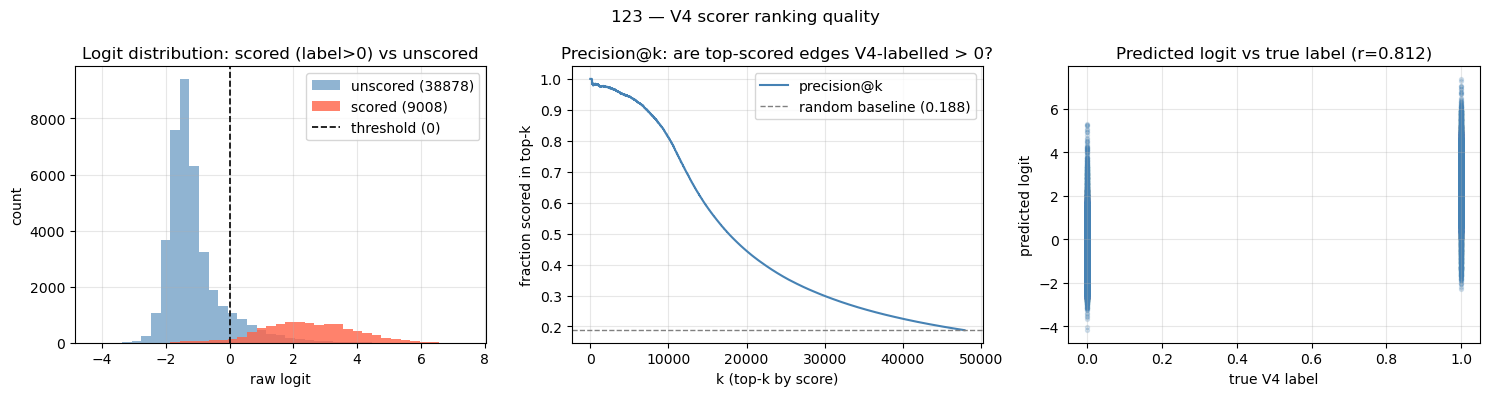

In [18]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

clear_output(wait=True)
plt.close("all")

lbl_bin = (lbl_bal.cpu() > 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logit histogram: scored vs unscored
all_vals = np.concatenate([pos_logits, neg_logits])
lo, hi = all_vals.min() - 0.1, all_vals.max() + 0.1
bins = np.linspace(lo, hi, 40)

axes[0].hist(neg_logits, bins=bins, alpha=0.6, label=f'unscored ({len(neg_logits)})', color='steelblue')
axes[0].hist(pos_logits, bins=bins, alpha=0.8, label=f'scored ({len(pos_logits)})', color='tomato')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold (0)')
axes[0].set_xlabel('raw logit')
axes[0].set_ylabel('count')
axes[0].set_title('Logit distribution: scored (label>0) vs unscored')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision@k
sort_order_logit = all_logits.argsort(descending=True)
sorted_lbl_bin = lbl_bin[sort_order_logit].numpy().astype(float)
cum_pos = sorted_lbl_bin.cumsum()
rank = np.arange(1, len(sorted_lbl_bin) + 1)
random_base = lbl_bin.float().mean().item()

axes[1].plot(rank, cum_pos / rank, color='steelblue', linewidth=1.5, label='precision@k')
axes[1].axhline(random_base, color='grey', linestyle='--', linewidth=1, label=f'random baseline ({random_base:.3f})')
axes[1].set_xlabel('k (top-k by score)')
axes[1].set_ylabel('fraction scored in top-k')
axes[1].set_title('Precision@k: are top-scored edges V4-labelled > 0?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Correlation
lbl_cont = labels_changed.detach().cpu().numpy().reshape(-1)
lg_np = all_logits.detach().cpu().numpy().reshape(-1)

print(lbl_cont.shape, lg_np.shape)

axes[2].scatter(lbl_cont, lg_np, alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('true V4 label')
axes[2].set_ylabel('predicted logit')
axes[2].set_title('Predicted logit vs true continuous label')

if lbl_cont.std() > 1e-8 and lg_np.std() > 1e-8:
    corr = float(np.corrcoef(lbl_cont, lg_np)[0, 1])
    axes[2].set_title(f'Predicted logit vs true label (r={corr:.3f})')

axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 scorer ranking quality', fontsize=12)
plt.tight_layout()
plt.show()

AUC-ROC (scored vs unscored): 0.9751
Avg Precision:                0.9097  (random baseline = 0.1881)


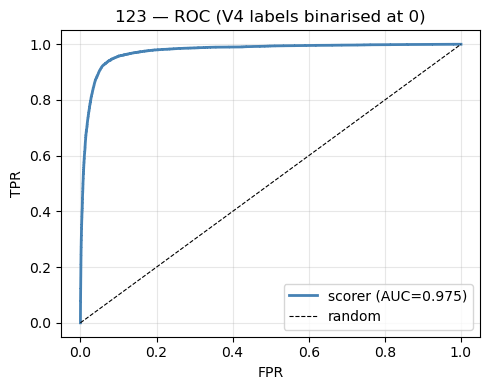

In [19]:
try:
    from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
    y_true  = lbl_bin.numpy().astype(int)
    y_score = all_logits.numpy()

    auc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    print(f'AUC-ROC (scored vs unscored): {auc:.4f}')
    print(f'Avg Precision:                {ap:.4f}  (random baseline = {random_base:.4f})')

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'scorer (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='random')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{123} — ROC (V4 labels binarised at 0)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('sklearn not available — skipping ROC')

---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [21]:
from collections import defaultdict

src_np    = src.cpu().numpy()
dst_np    = dst.cpu().numpy()
lbl_np_cn = labels_changed.cpu().numpy()
lg_np_cn  = all_logits.numpy()

node_to_cands = defaultdict(list)
for i in range(len(src_np)):
    u, v  = int(src_np[i]), int(dst_np[i])
    entry = (i, bool(lbl_np_cn[i] > 0), float(lbl_np_cn[i]), float(lg_np_cn[i]))
    node_to_cands[u].append(entry)
    node_to_cands[v].append(entry)

node_rows = []
for node, cands in node_to_cands.items():
    n_inc     = len(cands)
    n_pos_cn  = sum(1 for _, is_pos, _, _ in cands if is_pos)
    p_lgts    = [lg for _, is_pos, _, lg in cands if is_pos]
    n_lgts    = [lg for _, is_pos, _, lg in cands if not is_pos]
    node_rows.append({
        'node':           node,
        'degree':         int(degrees[node]),
        'n_incident':     n_inc,
        'n_scored':       n_pos_cn,
        'scored_rate':    n_pos_cn / n_inc,
        'mean_score_pos': float(np.mean(p_lgts)) if p_lgts else float('nan'),
        'mean_score_neg': float(np.mean(n_lgts)) if n_lgts else float('nan'),
    })

node_df = pd.DataFrame(node_rows)
print(f'Nodes with at least one incident candidate: {len(node_df)}')
print(f"Nodes with >= 1 scored candidate: {(node_df['n_scored'] > 0).sum()}")
display(node_df.describe())

Nodes with at least one incident candidate: 2810
Nodes with >= 1 scored candidate: 2628


,node,degree,n_incident,n_scored,scored_rate,mean_score_pos,mean_score_neg
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2628.000000,2809.000000
mean,1404.500000,5.680427,34.082562,6.411388,0.154113,2.197874,-1.124986
std,811.321453,8.453357,41.114817,22.667363,0.138650,0.948618,0.530718
min,0.000000,1.000000,9.000000,0.000000,0.000000,-1.681744,-2.160065
25%,702.250000,2.000000,23.000000,2.000000,0.068966,1.600005,-1.421043
50%,1404.500000,4.000000,27.000000,3.000000,0.121212,2.244667,-1.242670
75%,2106.750000,7.000000,33.000000,6.000000,0.200000,2.845431,-1.010341
max,2809.000000,246.000000,696.000000,606.000000,1.000000,5.417044,3.669188


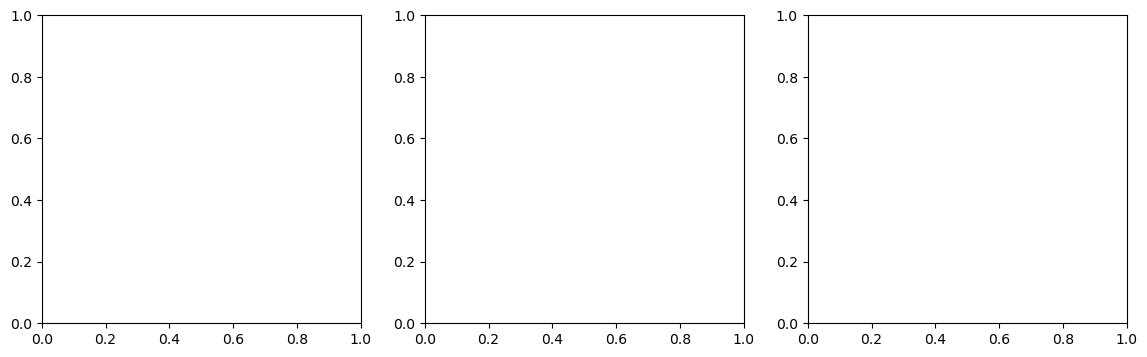

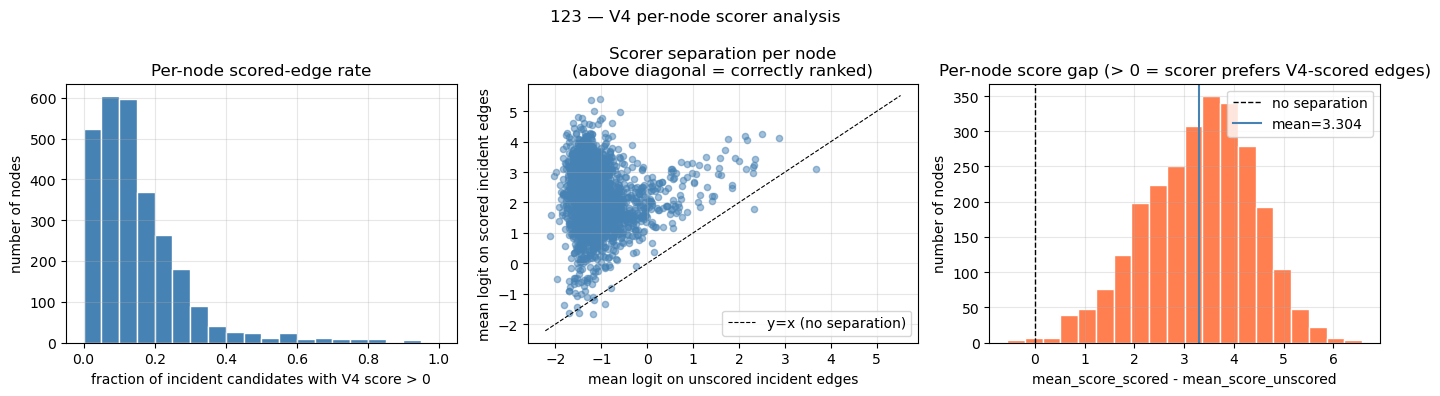

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(node_df['scored_rate'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('fraction of incident candidates with V4 score > 0')
axes[0].set_ylabel('number of nodes')
axes[0].set_title('Per-node scored-edge rate')
axes[0].grid(True, alpha=0.3)

has_both = node_df.dropna(subset=['mean_score_pos', 'mean_score_neg'])
axes[1].scatter(has_both['mean_score_neg'], has_both['mean_score_pos'],
                alpha=0.5, s=20, color='steelblue')
lo = min(has_both['mean_score_neg'].min(), has_both['mean_score_pos'].min()) - 0.1
hi = max(has_both['mean_score_neg'].max(), has_both['mean_score_pos'].max()) + 0.1
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y=x (no separation)')
axes[1].set_xlabel('mean logit on unscored incident edges')
axes[1].set_ylabel('mean logit on scored incident edges')
axes[1].set_title('Scorer separation per node\n(above diagonal = correctly ranked)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

hb = has_both.copy()
hb['score_gap'] = hb['mean_score_pos'] - hb['mean_score_neg']
axes[2].hist(hb['score_gap'], bins=20, color='coral', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='no separation')
axes[2].axvline(hb['score_gap'].mean(), color='steelblue', linestyle='-',
                linewidth=1.5, label=f"mean={hb['score_gap'].mean():.3f}")
axes[2].set_xlabel('mean_score_scored - mean_score_unscored')
axes[2].set_ylabel('number of nodes')
axes[2].set_title('Per-node score gap (> 0 = scorer prefers V4-scored edges)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 per-node scorer analysis', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Model Guided PR-BCD

In [23]:
# %% Cell 1: define the sweep
from copy import deepcopy
from itertools import product

# Values in these dictionaries are combined with a Cartesian product.
EXPERIMENT_SWEEP = {
    "attack": ["PRBCD"],
    "semi": [True],
    "epsilon": [0.05],
    "use_cert": ["accuracy_drop_selector", "none", "accuracy_drop_selector_with_resampling"],
    "seed": [SEED],
}

ATTACK_SWEEP = {
    "block_size": [4000],
    "epochs": [100],
    "fine_tune_epochs": [50],
    "keep_heuristic": ["WeightOnly"],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

SELECTOR_SWEEP = {
    "accuracy_drop_selector_mode": ["one_sample"],
    "n_candidates_k_sample": [2_000],
    "n_candidates_one_sample": [5_000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],
    "training_data_node_cap": [15],
    "tau": [0.8],
    "score_batch_size": [1_000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],
}

# Passed to every selector run, but not expanded as sweep dimensions.
SELECTOR_FIXED = {
    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",
}

# Keep Python model objects out of the CSV. The key is logged; the object is passed.
LP_MODEL_VARIANTS = {
    "default": lp_model,
}

ADS_CERTS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "direct_selector",
}

ADS_ONLY_SELECTOR_KEYS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
    "training_data_node_cap",
}


def expand_grid(grid):
    """Yield one dictionary for every Cartesian-product combination."""
    keys = list(grid)
    for values in product(*(grid[key] for key in keys)):
        yield dict(zip(keys, values))


def build_sweep_configs():
    experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
    attack_configs = list(expand_grid(ATTACK_SWEEP))
    selector_configs = list(expand_grid(SELECTOR_SWEEP))

    configs = []
    for experiment_cfg in experiment_configs:
        use_cert = experiment_cfg["use_cert"]

        for attack_cfg in attack_configs:
            for selector_cfg_full in selector_configs:
                selector_cfg = deepcopy(selector_cfg_full)
                selector_cfg.update(deepcopy(SELECTOR_FIXED))

                # Do not pass ADS-only parameters to unrelated attack modes.
                if use_cert not in ADS_CERTS:
                    selector_cfg = {
                        key: value
                        for key, value in selector_cfg.items()
                        if key not in ADS_ONLY_SELECTOR_KEYS
                    }

                for lp_model_label, lp_model_object in LP_MODEL_VARIANTS.items():
                    configs.append({
                        "experiment": deepcopy(experiment_cfg),
                        "attack_params": {
                            **deepcopy(attack_cfg),
                            "lp_model": lp_model_object,
                        },
                        "selector_params": deepcopy(selector_cfg),
                        "log_values": {
                            "lp_model_label": lp_model_label,
                        },
                    })

    return configs


EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
ATTACK_COLUMNS = list(ATTACK_SWEEP)
SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
    key for key in SELECTOR_FIXED if key not in SELECTOR_SWEEP
]
LOG_COLUMNS = ["lp_model_label"]

ALL_CONFIG_COLUMNS = (
    [f"experiment__{key}" for key in EXPERIMENT_COLUMNS]
    + [f"attack__{key}" for key in ATTACK_COLUMNS]
    + [f"selector__{key}" for key in SELECTOR_COLUMNS]
    + [f"log__{key}" for key in LOG_COLUMNS]
)


def config_to_row(cfg):
    row = {}
    for key in EXPERIMENT_COLUMNS:
        row[f"experiment__{key}"] = cfg["experiment"].get(key, "")
    for key in ATTACK_COLUMNS:
        row[f"attack__{key}"] = cfg["attack_params"].get(key, "")
    for key in SELECTOR_COLUMNS:
        row[f"selector__{key}"] = cfg["selector_params"].get(key, "")
    for key in LOG_COLUMNS:
        row[f"log__{key}"] = cfg["log_values"].get(key, "")
    return row


sweep_configs = build_sweep_configs()
print(f"Number of configurations: {len(sweep_configs)}")

for index, cfg in enumerate(sweep_configs, start=1):
    exp = cfg["experiment"]
    selector = cfg["selector_params"]
    print(
        f"{index:03d}: attack={exp['attack']}, cert={exp['use_cert']}, "
        f"epsilon={exp['epsilon']}, seed={exp['seed']}, "
        f"mode={selector.get('accuracy_drop_selector_mode', '-')}, "
        f"drop_mode={selector.get('drop_mode', '-')}, "
        f"tau={selector.get('tau', '-')}"
    )


Number of configurations: 3
001: attack=PRBCD, cert=accuracy_drop_selector, epsilon=0.05, seed=0, mode=one_sample, drop_mode=endpoint, tau=0.8
002: attack=PRBCD, cert=none, epsilon=0.05, seed=0, mode=-, drop_mode=-, tau=0.8
003: attack=PRBCD, cert=accuracy_drop_selector_with_resampling, epsilon=0.05, seed=0, mode=one_sample, drop_mode=endpoint, tau=0.8


In [23]:
# %% Cell 2: run the sweep and append CSV logs
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer
from datetime import datetime
import csv
import gc
import hashlib
import json
import os
import traceback

import numpy as np
import torch
from sparse_smoothing.utils import load_and_standardize

# -------------------------
# Behaviour
# -------------------------
STOP_ON_ERROR = False
SAVE_RAW_RESULTS = False

MODEL_STORAGE_TYPE = "demo_custom_split"
ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

def _folder_safe_value(value):
    """Convert a config value into a compact, filesystem-safe string."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (list, tuple)):
        return "-".join(_folder_safe_value(item) for item in value)
    if value is None:
        return "na"

    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _read_nested_config(cfg, candidate_paths):
    """Return the first configured value found among the candidate paths."""
    for section_name, key in candidate_paths:
        section = cfg.get(section_name, {})
        if key in section and section[key] is not None:
            return section[key]
    return None


def _collect_sweep_values(candidate_paths):
    """Collect unique values in sweep order for one signature field."""
    values = []
    seen = set()

    for cfg in sweep_configs:
        value = _read_nested_config(cfg, candidate_paths)
        safe_value = _folder_safe_value(value)
        if safe_value not in seen:
            seen.add(safe_value)
            values.append(safe_value)

    return "+".join(values) if values else "na"


FOLDER_SIGNATURE = "__".join([
    "block_size-" + _collect_sweep_values([
        ("attack_params", "block_size"),
    ]),
    "tau-" + _collect_sweep_values([
        ("selector_params", "tau"),
        ("attack_params", "tau"),
        ("experiment", "tau"),
    ]),
    "epsilon-" + _collect_sweep_values([
        ("experiment", "epsilon"),
        ("attack_params", "epsilon"),
        ("attack_params", "eps"),
    ]),
    "epochs-" + _collect_sweep_values([
        ("attack_params", "epochs"),
    ]),
])

RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = os.path.join(
    "extendedPlotting",
    "sweeps",
    f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
)
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
if SAVE_RAW_RESULTS:
    os.makedirs(RAW_RESULT_DIR, exist_ok=True)

SUMMARY_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "status",
    "dataset",
    "model_label",
    "model_storage_type",
    "use_cert_label",
    "accuracy",
    "runtime_seconds",
    "error_type",
    "error_message",
    "raw_result_path",
] + ALL_CONFIG_COLUMNS

EPOCHS_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "dataset",
    "model_label",
    "use_cert_label",
    "stat_idx",
    "epoch_idx",
    "phase",
    "accuracy",
    "loss",
    "nonzero_weights",
    "prob_mass_update",
    "prob_mass_projected",
] + ALL_CONFIG_COLUMNS


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return str(value.detach().cpu().tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return ""
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def append_dict_rows(path, fieldnames, rows):
    rows = list(rows)
    if not rows:
        return

    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, "r", newline="", encoding="utf-8") as handle:
            existing_header = next(csv.reader(handle), None)
        if existing_header != fieldnames:
            raise RuntimeError(
                f"CSV header mismatch in {path}.\n"
                f"Found:    {existing_header}\n"
                f"Expected: {fieldnames}"
            )

    with open(path, "a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)
        handle.flush()
        os.fsync(handle.fileno())


def make_use_cert_label(experiment_cfg, selector_params):
    use_cert = experiment_cfg["use_cert"]
    parts = [str(use_cert)]

    if use_cert in ADS_CERTS:
        for key, prefix in (
            ("accuracy_drop_selector_mode", "mode"),
            ("drop_mode", "drop"),
            ("training_data_node_cap", "cap"),
        ):
            value = selector_params.get(key)
            if value not in (None, ""):
                parts.append(f"{prefix}-{value}")

    return "__".join(parts)


def make_run_id(config_index, cfg):
    serializable_cfg = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }
    digest = hashlib.sha1(
        json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


def as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [to_python_scalar(item) for item in value]
    return [to_python_scalar(value)]


def is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def find_attack_statistics(obj, seen=None):
    """Find a nested PRBCD attack-statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                is_metric_series(candidate.get("accuracy"))
                or is_metric_series(candidate.get("loss"))
            ):
                return candidate

        if (
            is_metric_series(obj.get("accuracy"))
            and is_metric_series(obj.get("loss"))
        ):
            return obj

        for value in obj.values():
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return to_python_scalar(first["accuracy"])

        accuracy = result.get("accuracy")
        if accuracy is not None and not is_metric_series(accuracy):
            return to_python_scalar(accuracy)

    raise KeyError("Could not find final accuracy in the experiment result.")


def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
    if not stats:
        return []

    metric_lists = {
        "accuracy": as_list(stats.get("accuracy")),
        "loss": as_list(stats.get("loss")),
        "nonzero_weights": as_list(stats.get("nonzero_weights")),
        "prob_mass_update": as_list(stats.get("probability_mass_update")),
        "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
    }

    length = max((len(values) for values in metric_lists.values()), default=0)
    configured_epochs = int(cfg["attack_params"].get("epochs", 0))
    has_baseline = configured_epochs > 0 and length == configured_epochs + 1
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    rows = []
    for stat_idx in range(length):
        is_baseline = has_baseline and stat_idx == 0
        epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

        row = {
            "run_group_id": RUN_GROUP_ID,
            "run_id": run_id,
            "config_index": config_index,
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "use_cert_label": use_cert_label,
            "stat_idx": stat_idx,
            "epoch_idx": epoch_idx,
            "phase": "baseline" if is_baseline else "attack",
        }

        for metric_name, values in metric_lists.items():
            row[metric_name] = (
                to_python_scalar(values[stat_idx])
                if stat_idx < len(values)
                else ""
            )

        row.update(config_row)
        rows.append(row)

    return rows


# -------------------------
# Load the exact graph type required by the current run call
# -------------------------
graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Sweep
# -------------------------
results_global_prbcd_cert = []

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_cfg = dict(cfg["experiment"])
    attack_params = dict(cfg["attack_params"])
    selector_params = dict(cfg["selector_params"])

    epsilon = experiment_cfg["epsilon"]
    semi = experiment_cfg["semi"]
    use_cert = experiment_cfg["use_cert"]
    seed = experiment_cfg["seed"]
    attack_name = experiment_cfg["attack"]

    use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
    run_id = make_run_id(config_index, cfg)
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    print("=" * 80)
    print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
    print("attack:", attack_name)
    print("use_cert:", use_cert)
    print("attack_params:", attack_params)
    print("selector_params:", selector_params)

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    start = timer()
    result = None
    raw_result_path = ""

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack=attack_name,
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=semi,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = extract_final_accuracy(result)

        stats = find_attack_statistics(result)
        epoch_rows = build_epoch_rows(
            stats=stats,
            cfg=cfg,
            run_id=run_id,
            config_index=config_index,
            use_cert_label=use_cert_label,
        )
        append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

        if not epoch_rows:
            print("[warn] No per-epoch attack statistics found in the returned result.")

        if SAVE_RAW_RESULTS:
            raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
            torch.save(result, raw_result_path)

        summary_row = {
            "run_group_id": RUN_GROUP_ID,
            "run_id": run_id,
            "config_index": config_index,
            "status": "ok",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "error_type": "",
            "error_message": "",
            "raw_result_path": raw_result_path,
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
        })

        print(f"Final accuracy: {final_accuracy}")
        print(f"Runtime: {elapsed:.2f} seconds")

        clear_output(wait=True)

    except Exception as exc:
        elapsed = timer() - start
        error_message = "".join(
            traceback.format_exception_only(type(exc), exc)
        ).strip()

        summary_row = {
            "run_group_id": RUN_GROUP_ID,
            "run_id": run_id,
            "config_index": config_index,
            "status": "error",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": elapsed,
            "error_type": type(exc).__name__,
            "error_message": error_message,
            "raw_result_path": "",
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": elapsed,
            "status": "error",
            "error": error_message,
        })

        print(f"[error] {error_message}")
        traceback.print_exc()

        if STOP_ON_ERROR:
            raise

    finally:
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("=" * 80)
print("Sweep finished.")
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)


Found 7 epoch CSV file(s).
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260623_161227\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\epochs.csv

Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260623_161227\epochs.csv

Run identifier: 20260623_161227
Block sizes: [50000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260623_161227\p

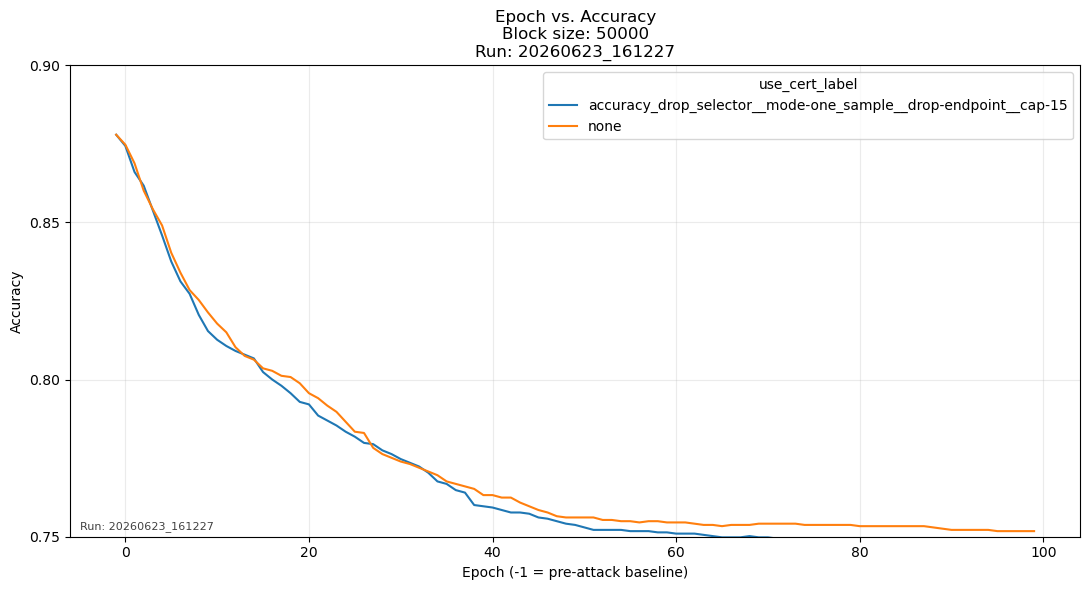


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv

Run identifier: 20260624_132926
Block sizes: [50000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926\epoch_accuracy__run-20260624_132926__block_size-50000.png


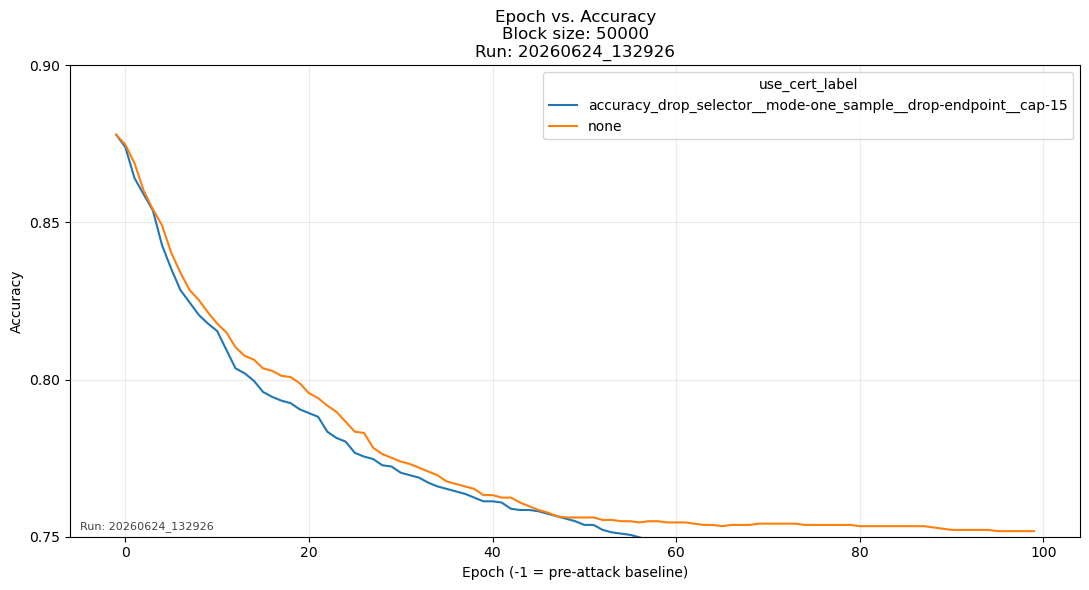


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv

Run identifier: 20260624_133732
Block sizes: [50000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732\epoch_accuracy__run-20260624_133732__block_size-50000.png


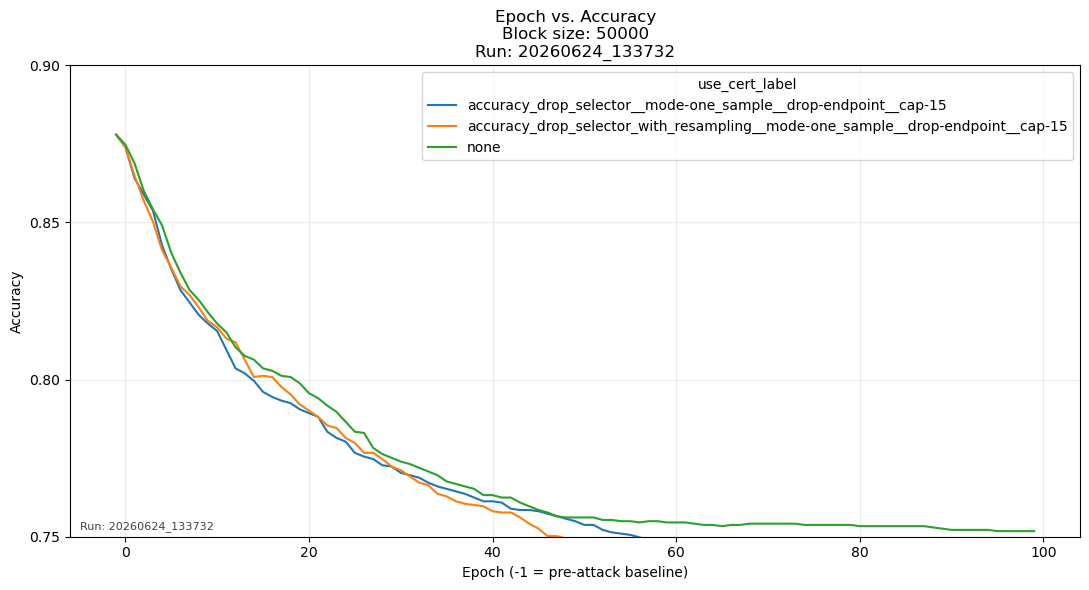


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv

Run identifier: 20260624_145533
Block sizes: [2000, 4000, 6000, 8000, 10000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy_3d__run-20260624_145533.png


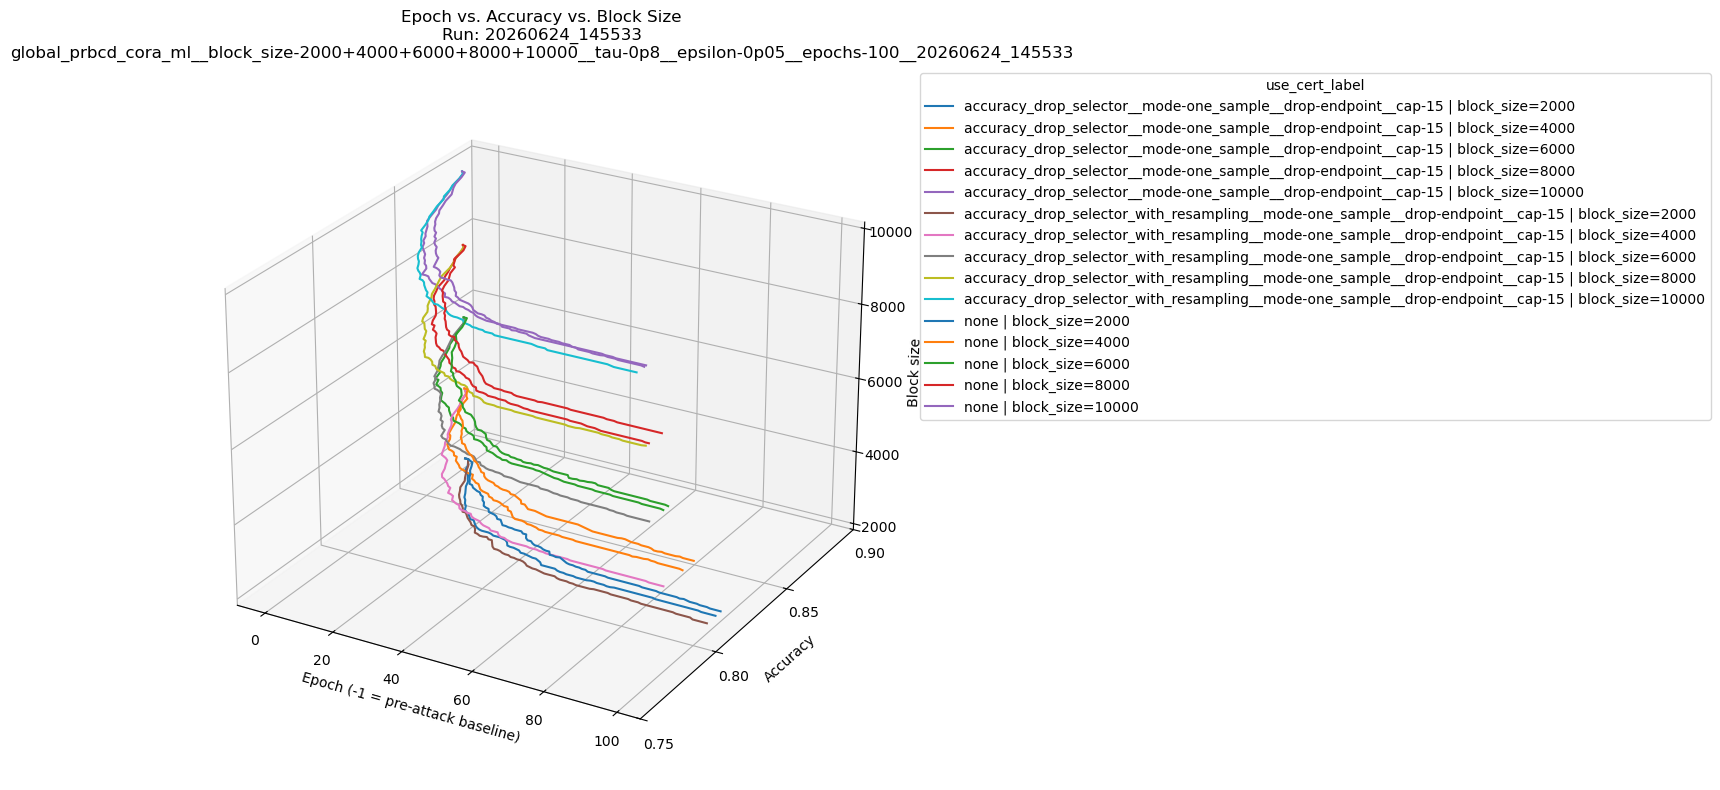

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-2000.png


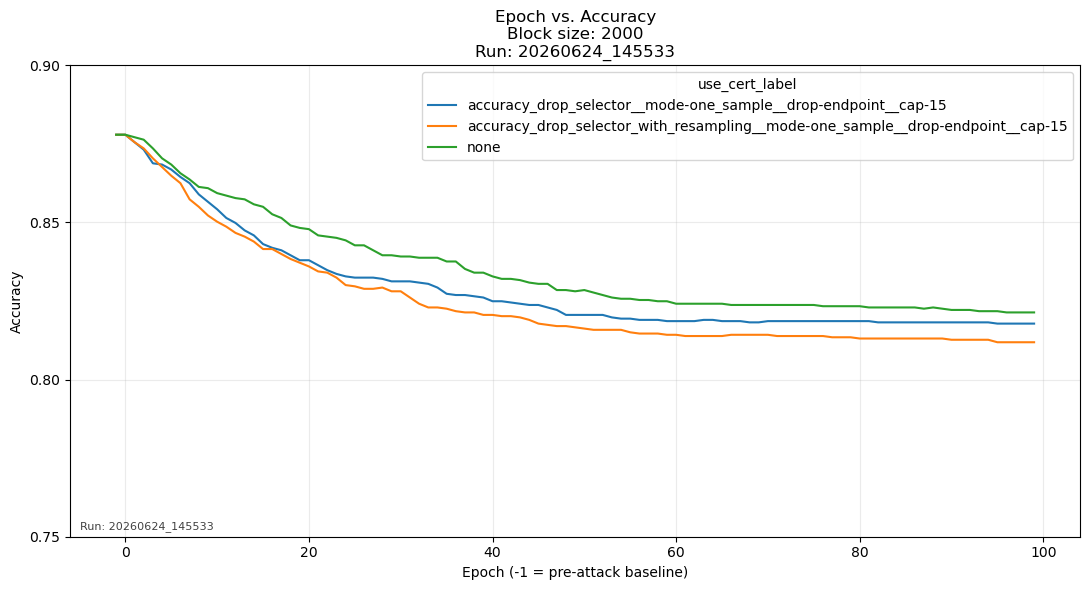

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-4000.png


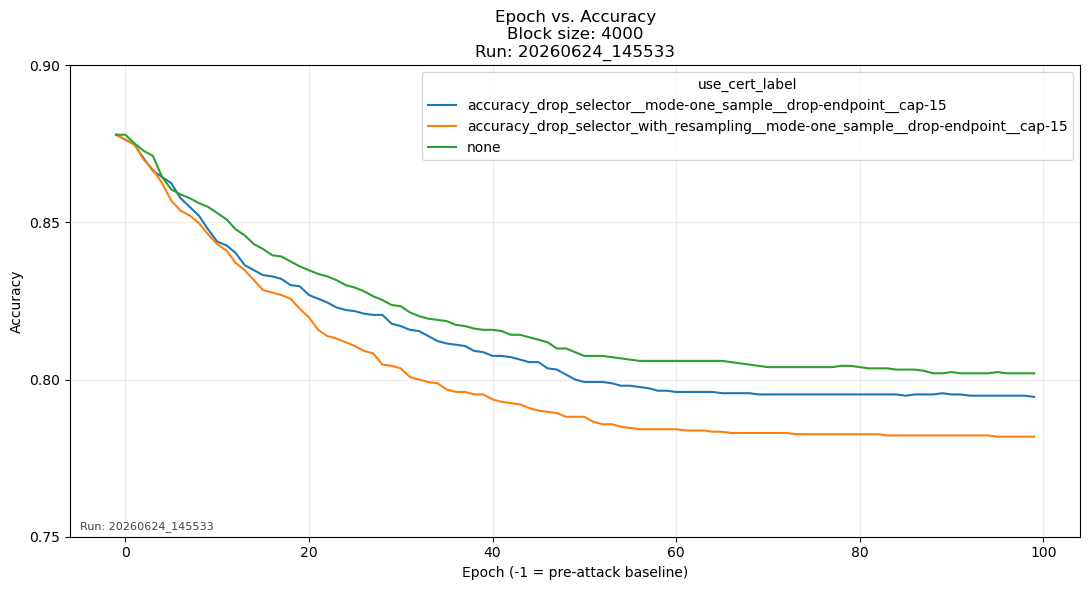

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-6000.png


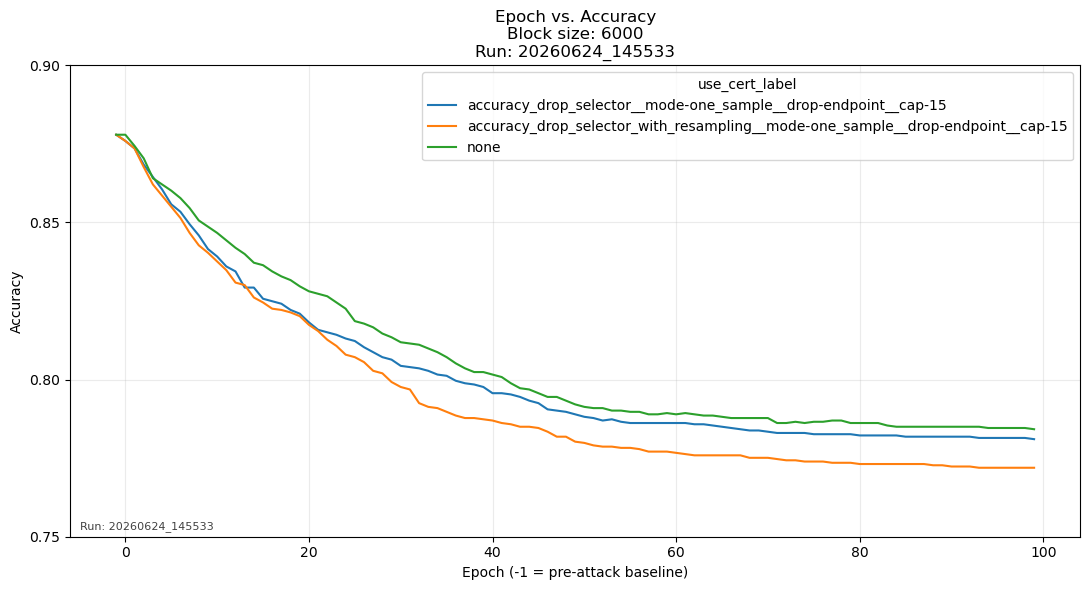

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-8000.png


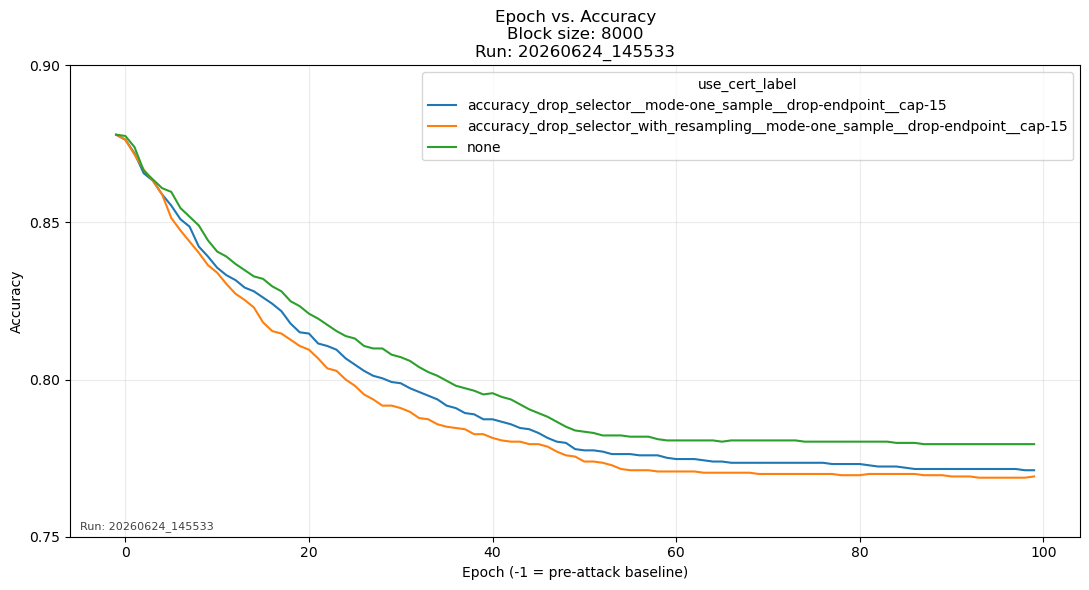

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-10000.png


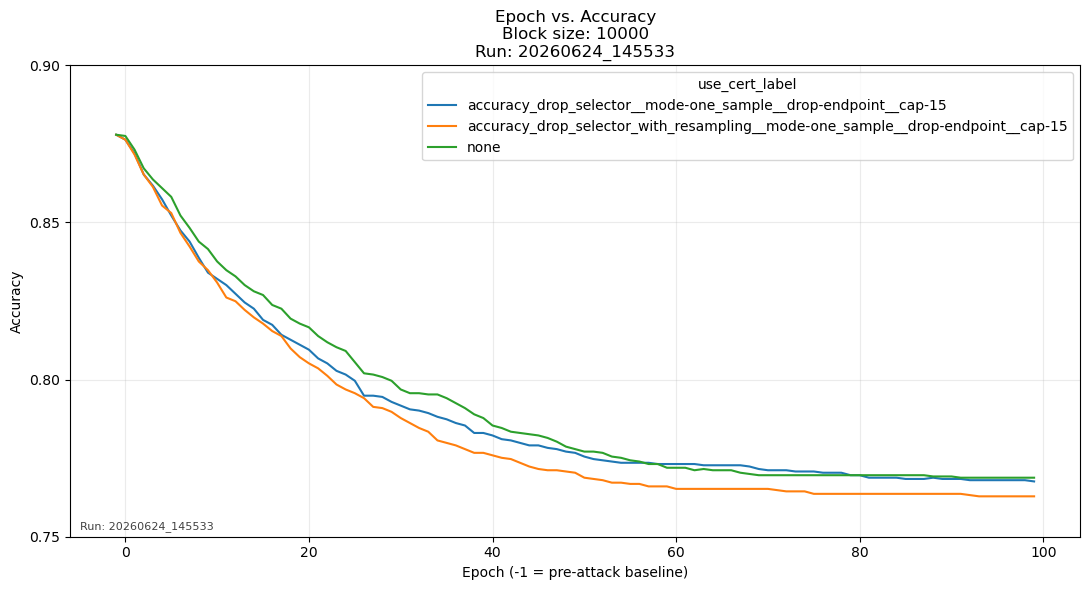


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv

Run identifier: 20260624_142349
Block sizes: [20000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349\epoch_accuracy__run-20260624_142349__block_size-20000.png


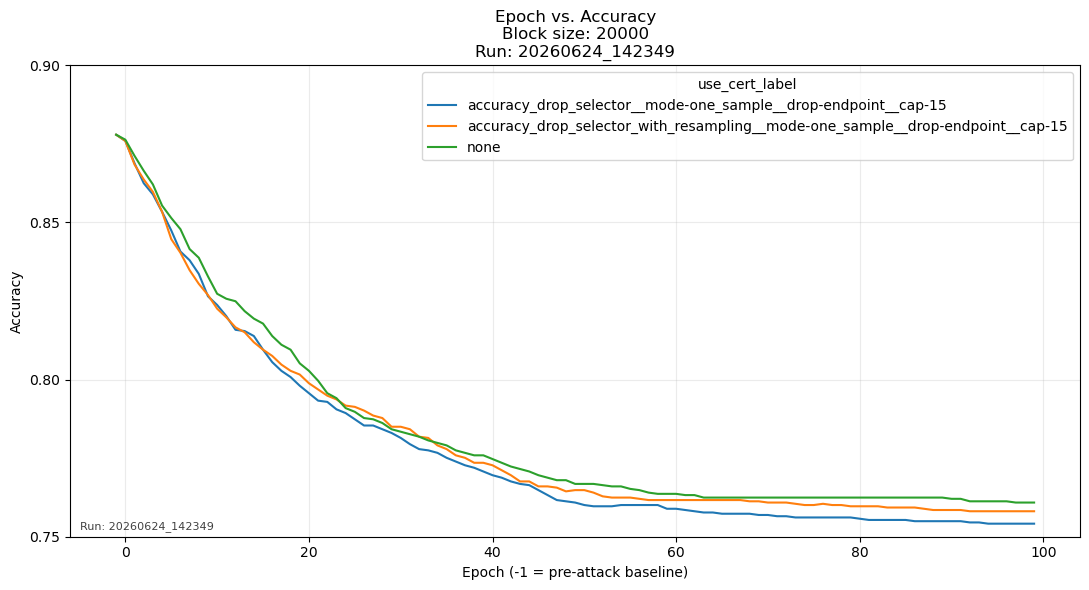


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv

Run identifier: 20260624_144122
Block sizes: [2000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122\epoch_accuracy__run-20260624_144122__block_size-2000.png


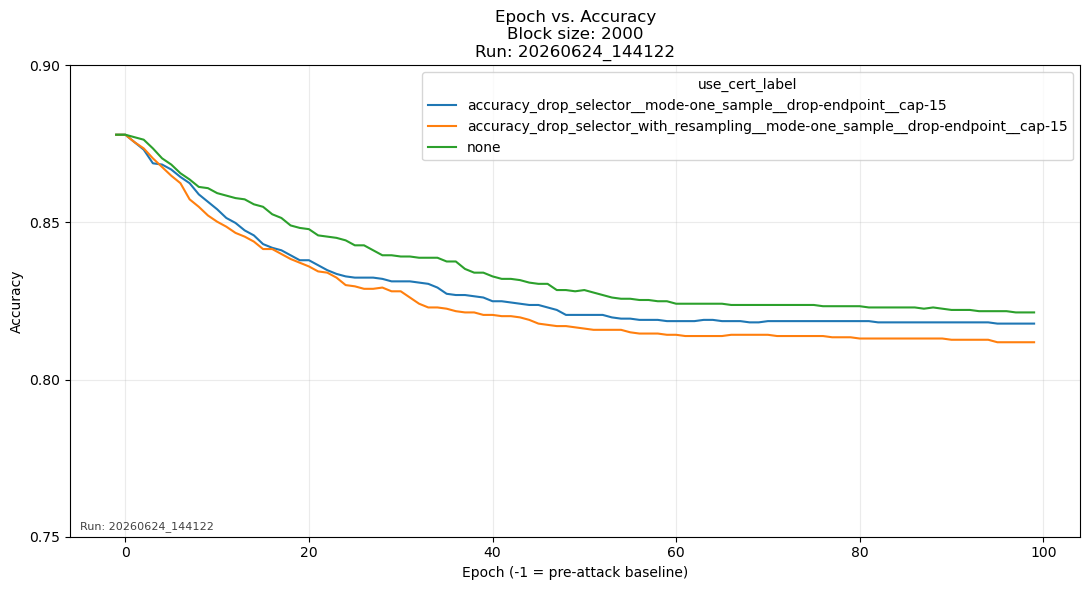


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\epochs.csv

Run identifier: 20260624_143059
Block sizes: [5000]
Plot folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059\epoch_accuracy__run-20260624_143059__block_size-5000.png


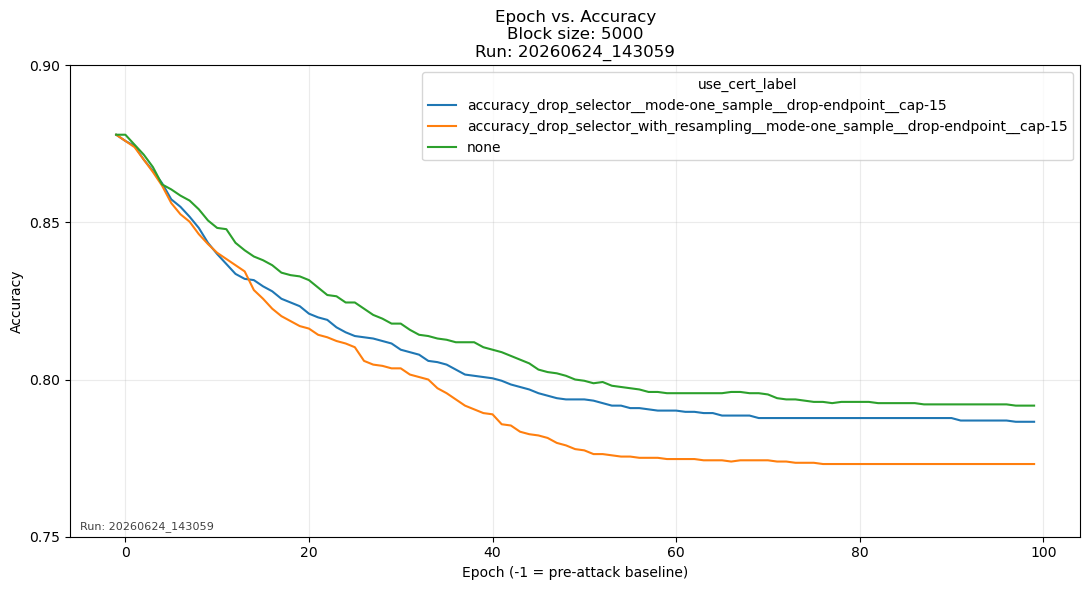

In [50]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Include epoch -1, representing the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90


# ============================================================
# Possible column names
# ============================================================

epoch_candidates = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

accuracy_candidates = [
    "accuracy",
    "acc",
    "Accuracy",
]

method_candidates = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

block_size_candidates = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

run_group_candidates = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]


# ============================================================
# Helper functions
# ============================================================

def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_block_size_column(dataframe):
    """
    Search known block-size column names first. If none is found,
    use a column whose normalized name ends in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        block_size_candidates,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if column
            .lower()
            .replace(".", "_")
            .replace("-", "_")
            .endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier or method name into a safe filename.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-")


def format_block_size(block_size):
    """
    Format block sizes without an unnecessary decimal point.
    """
    block_size = float(block_size)

    if block_size.is_integer():
        return str(int(block_size))

    return str(block_size).replace(".", "p")


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


# ============================================================
# Find all epochs.csv files recursively
# ============================================================

csv_files = sorted(
    SWEEP_ROOT.rglob("epochs.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No epochs.csv files found below: "
        f"{SWEEP_ROOT.resolve()}"
    )

print(
    f"Found {len(csv_files)} epoch CSV file(s)."
)

for path in csv_files:
    print(" -", path)


# ============================================================
# Process every epochs.csv file
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 80)
    print("Processing:", csv_path)

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        epoch_candidates,
    )

    accuracy_col = find_first_existing_column(
        df,
        accuracy_candidates,
    )

    method_col = find_first_existing_column(
        df,
        method_candidates,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        run_group_candidates,
    )

    if epoch_col is None:
        print(
            f"Skipping {csv_path}: "
            "no compatible epoch column found."
        )
        continue

    if accuracy_col is None:
        print(
            f"Skipping {csv_path}: "
            "no compatible accuracy column found."
        )
        continue

    if block_size_col is None:
        print(
            f"Skipping {csv_path}: "
            "no block-size column found."
        )
        continue

    # --------------------------------------------------------
    # Convert columns
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print(
            f"Skipping {csv_path}: "
            "no valid rows remained."
        )
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split the CSV into distinct run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        # Treat the complete CSV as one run.
        fallback_run_id = csv_path.parent.name

        run_groups = [
            (
                fallback_run_id,
                df,
            )
        ]

    # ========================================================
    # Process each run separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        safe_run_identifier = safe_filename(
            run_identifier
        )

        run_folder_name = csv_path.parent.name

        # All plots belonging to this run are placed together.
        plot_output_dir = (
            csv_path.parent
            / f"plots__run-{safe_run_identifier}"
        )

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        print()
        print("Run identifier:", run_identifier)
        print("Block sizes:", block_sizes)
        print("Plot folder:", plot_output_dir)

        # ====================================================
        # 3D plot for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = str(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if (
                    method_label
                    == "accuracy_drop_selector_k_hop"
                ):
                    continue

                if pd.isna(block_size):
                    continue

                series = (
                    group
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if series.empty:
                    continue

                epoch_values = (
                    series.index.to_numpy()
                )

                accuracy_values = (
                    series.to_numpy()
                )

                block_size_values = [
                    float(block_size)
                ] * len(series)

                axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Epoch vs. Accuracy vs. Block Size\n"
                    f"Run: {run_identifier}\n"
                    f"{run_folder_name}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for "
                    "the 3D plot."
                )

        # ====================================================
        # Separate 2D plot for every block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(11, 6)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = str(method)

                    if (
                        method_label
                        == "accuracy_drop_selector_k_hop"
                    ):
                        continue

                    series = (
                        method_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                        label=method_label,
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                series = (
                    block_df
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if not series.empty:
                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                    )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    "Skipping block size "
                    f"{block_size}: no valid series."
                )

                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Epoch vs. Accuracy\n"
                f"Block size: {block_size_label}\n"
                f"Run: {run_identifier}"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            # Additional visible run distinguisher.
            add_run_label(
                axis,
                run_identifier,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

Found 9 epoch CSV file(s).
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260623_161227\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p0

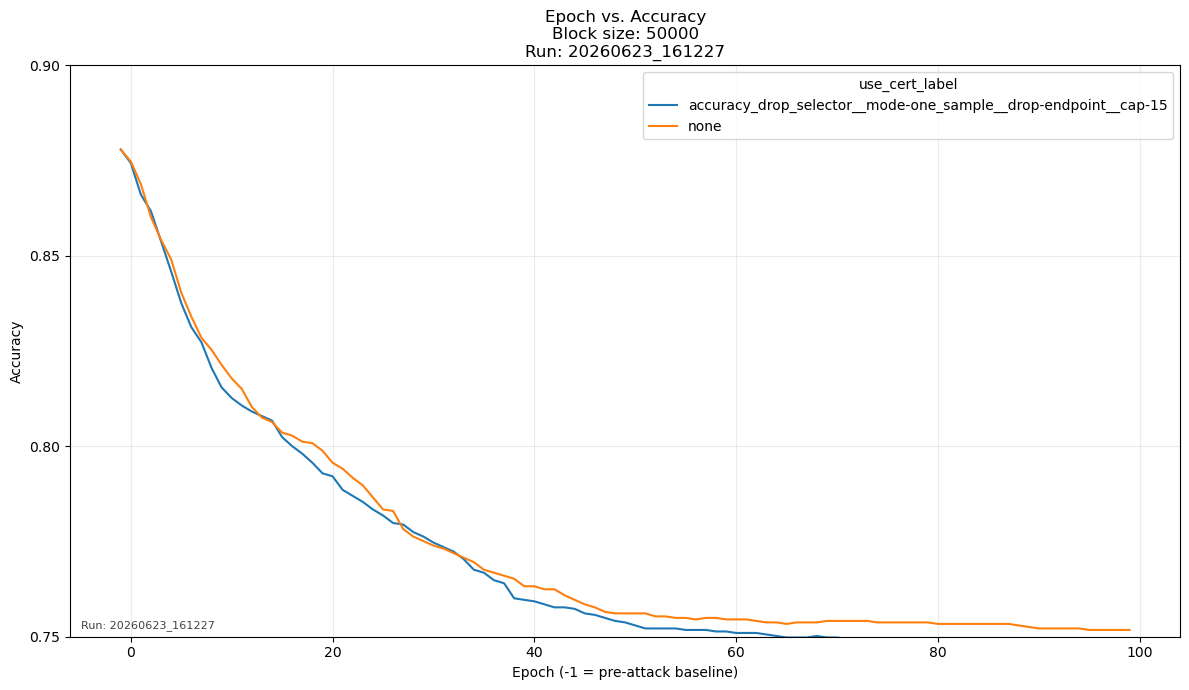


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_132926
Block sizes: ['50000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926\epoch_accuracy__run-20260624_132926__block_size-50000.png


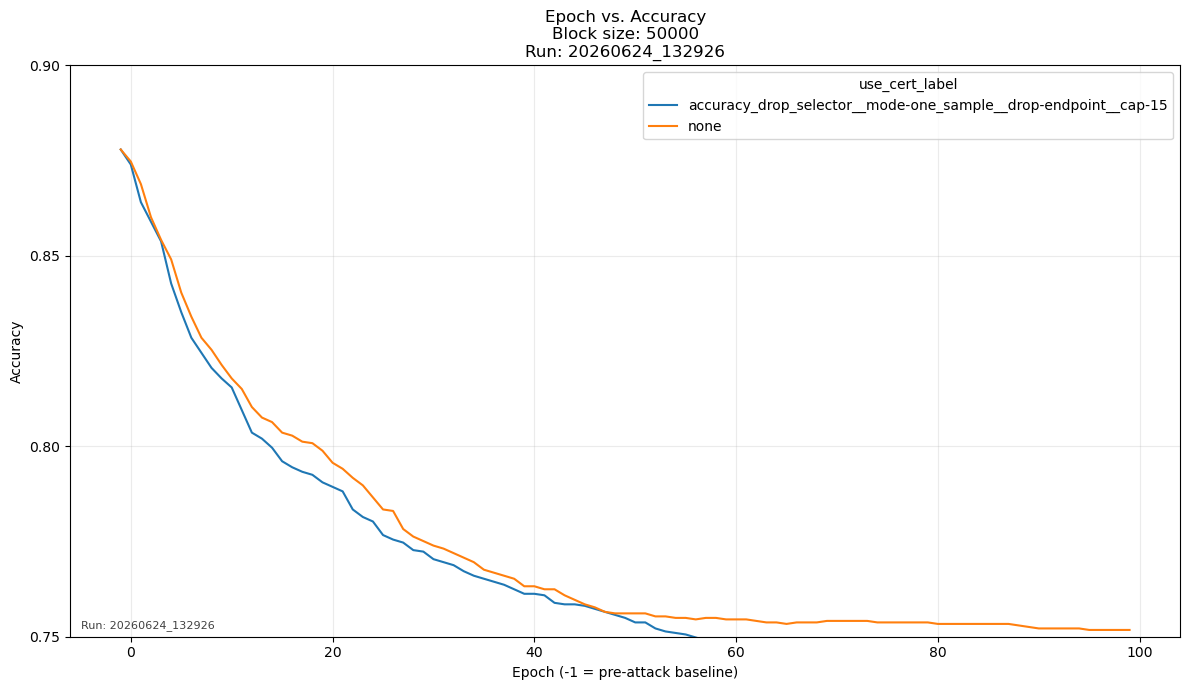


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_133732
Block sizes: ['50000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732\epoch_accuracy__run-20260624_133732__block_size-50000.png


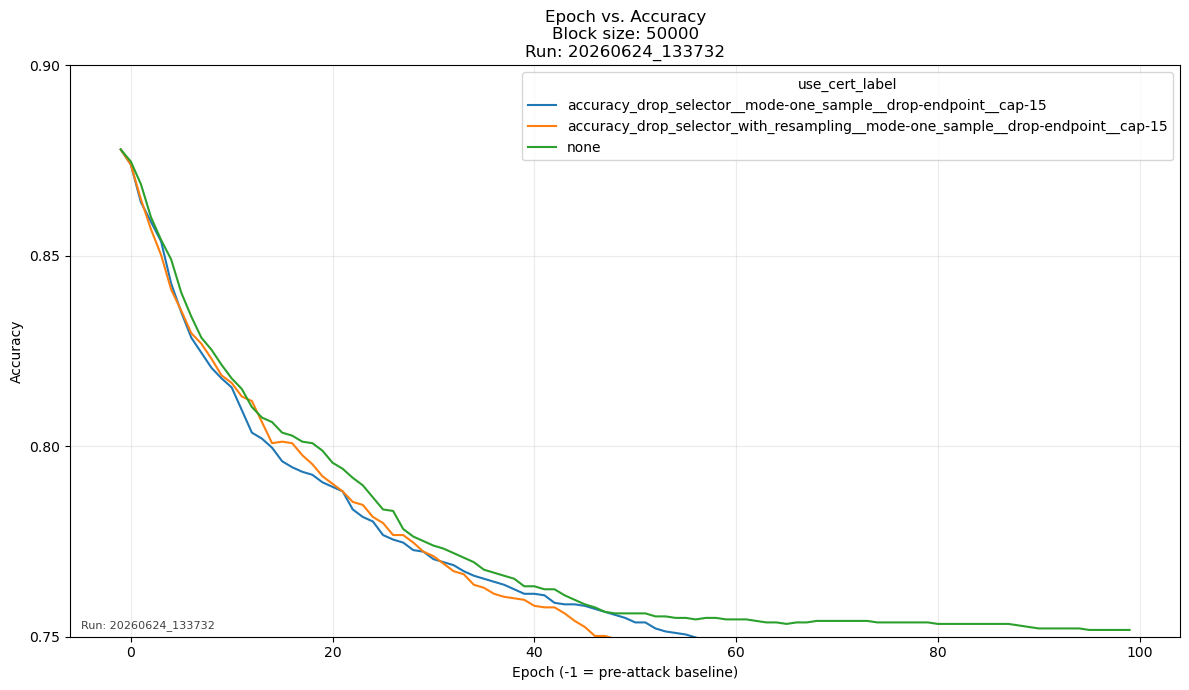


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_145533
Block sizes: ['2000', '4000', '6000', '8000', '10000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy_3d__run-20260624_145533.png


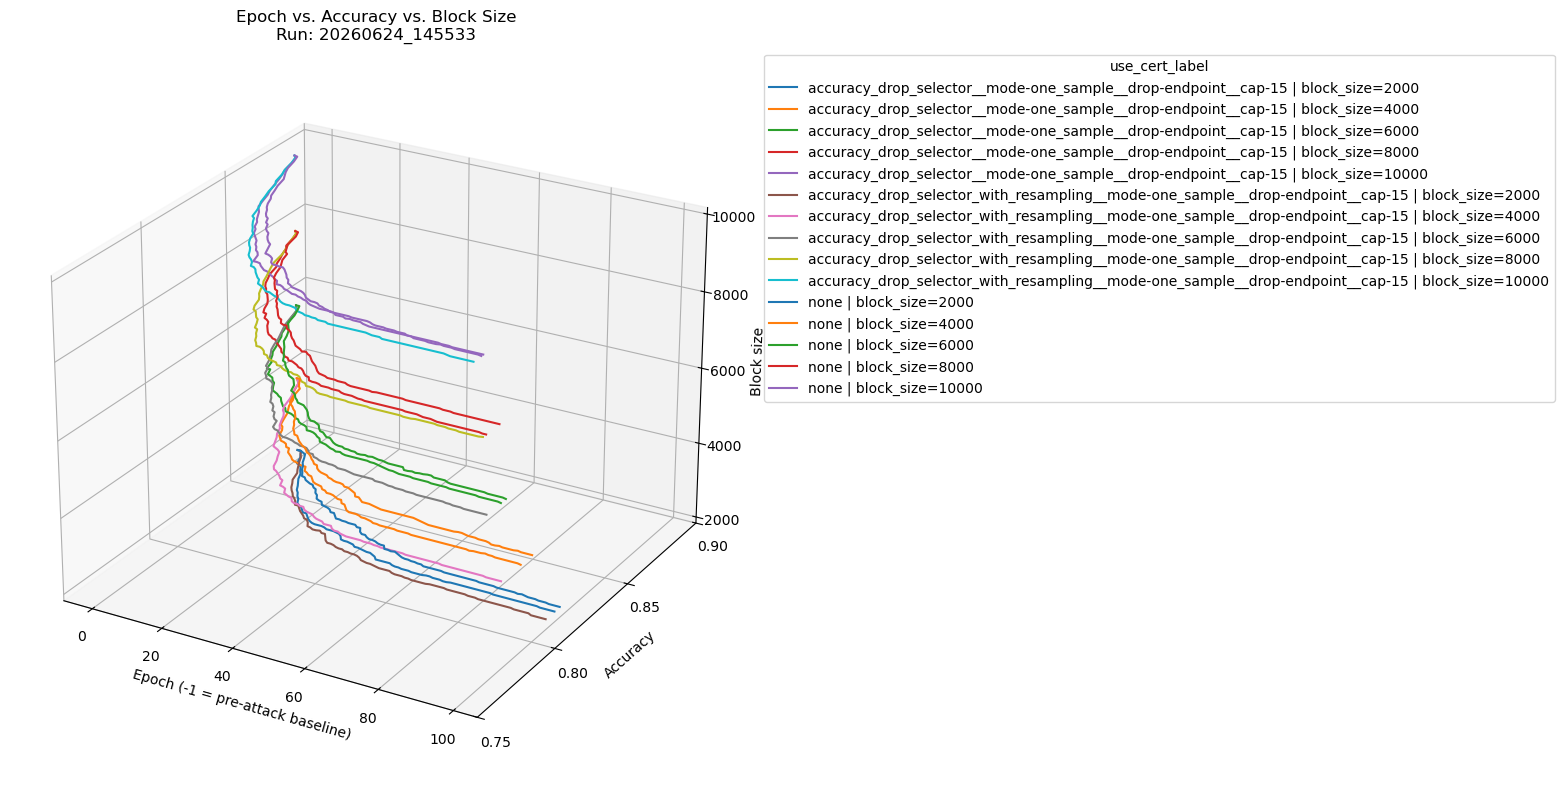

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-2000.png


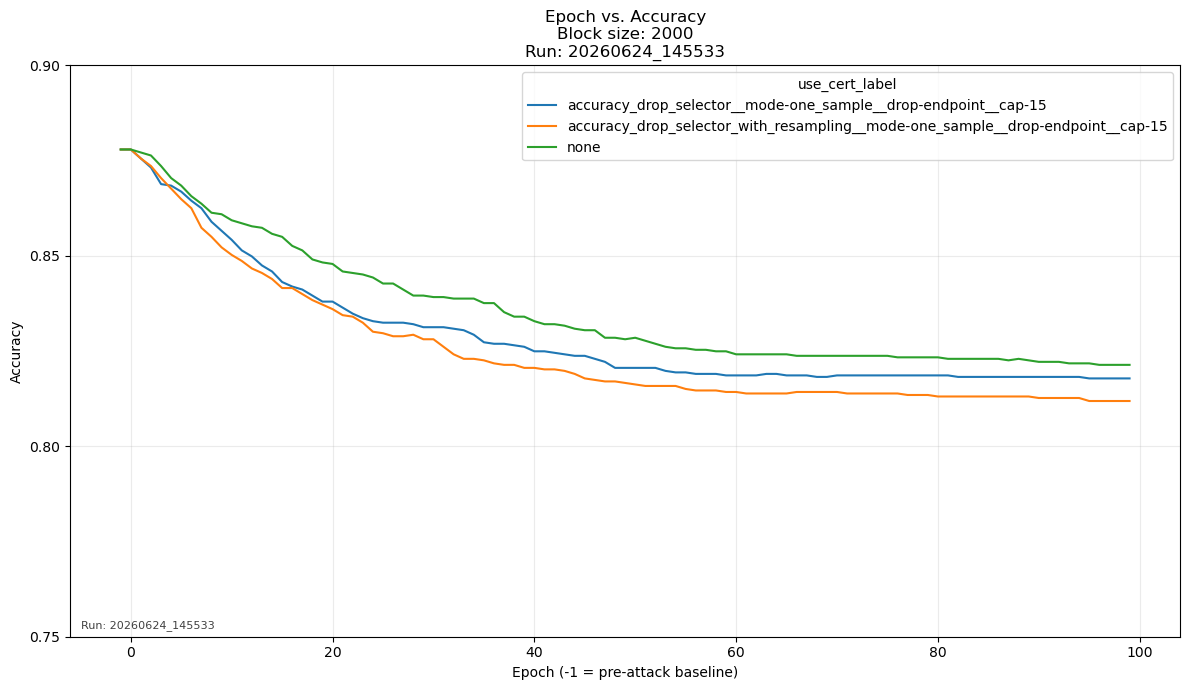

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-4000.png


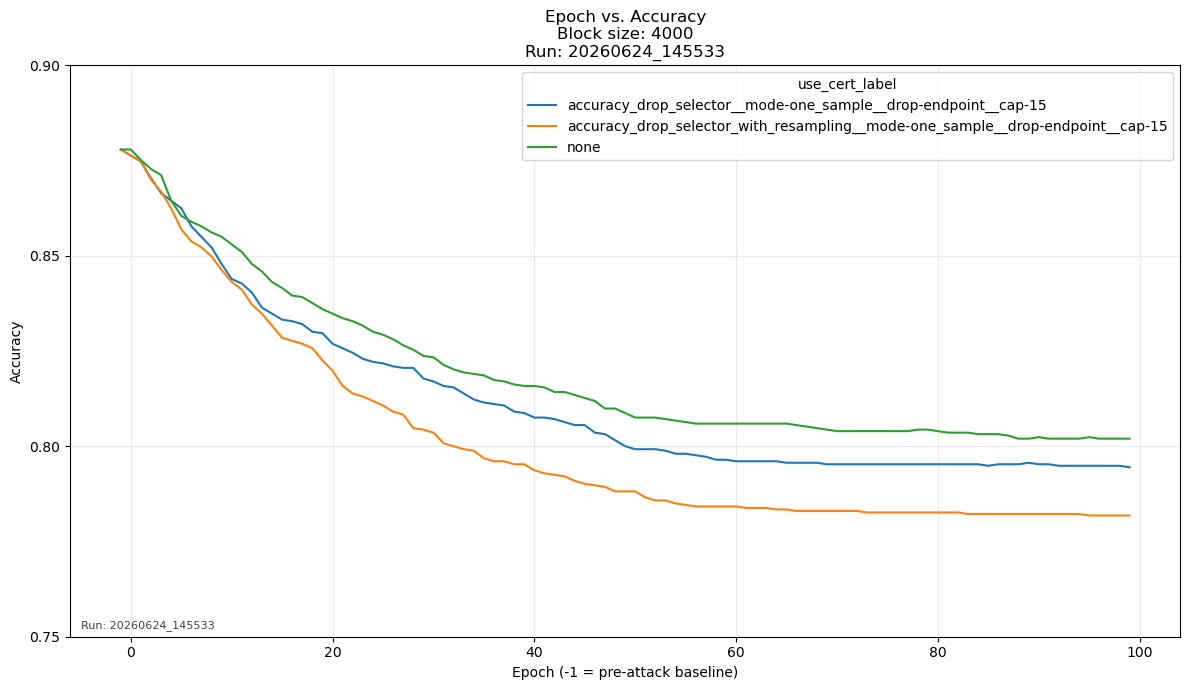

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-6000.png


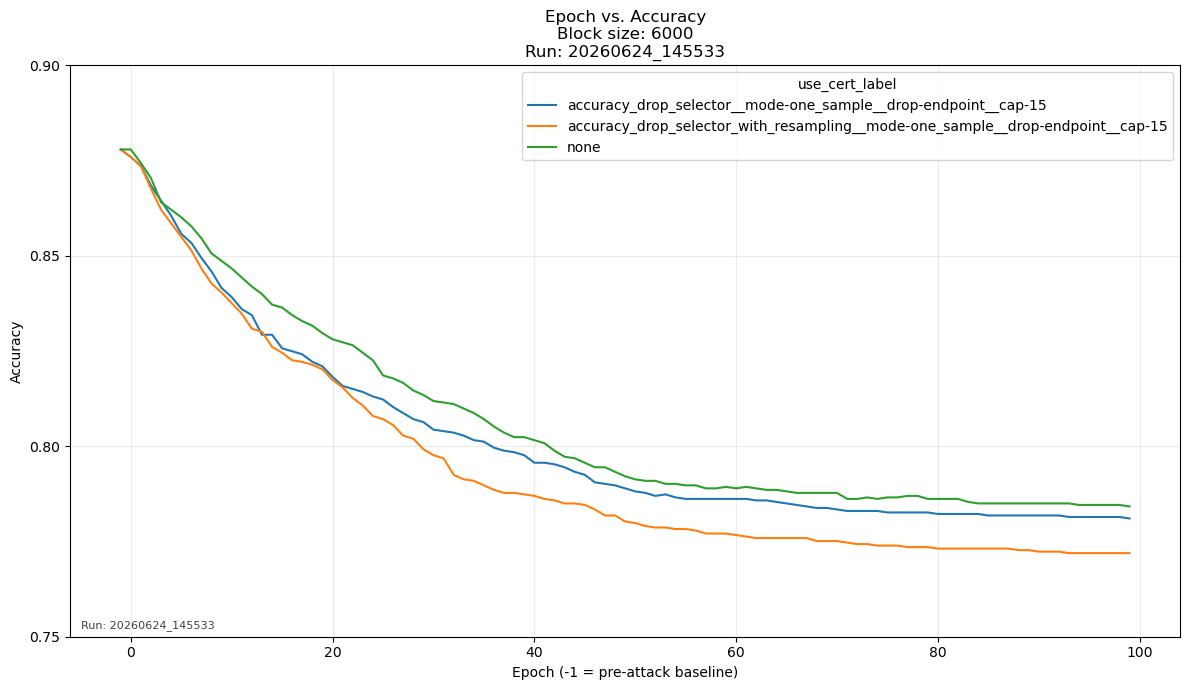

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-8000.png


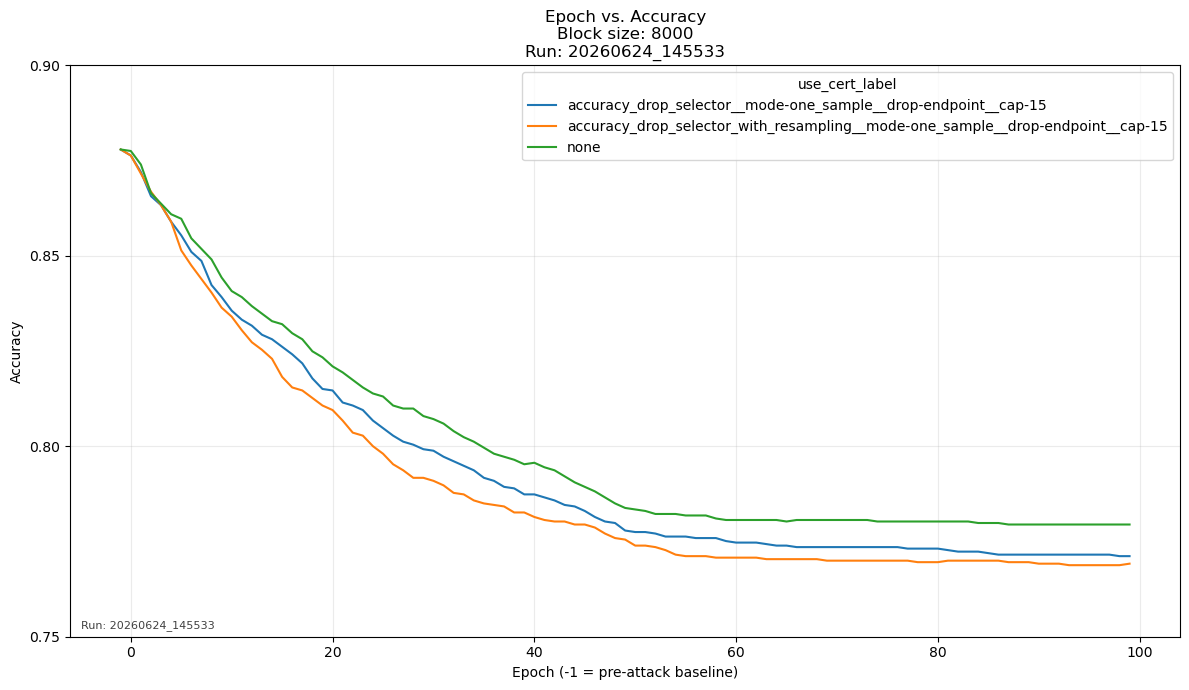

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-10000.png


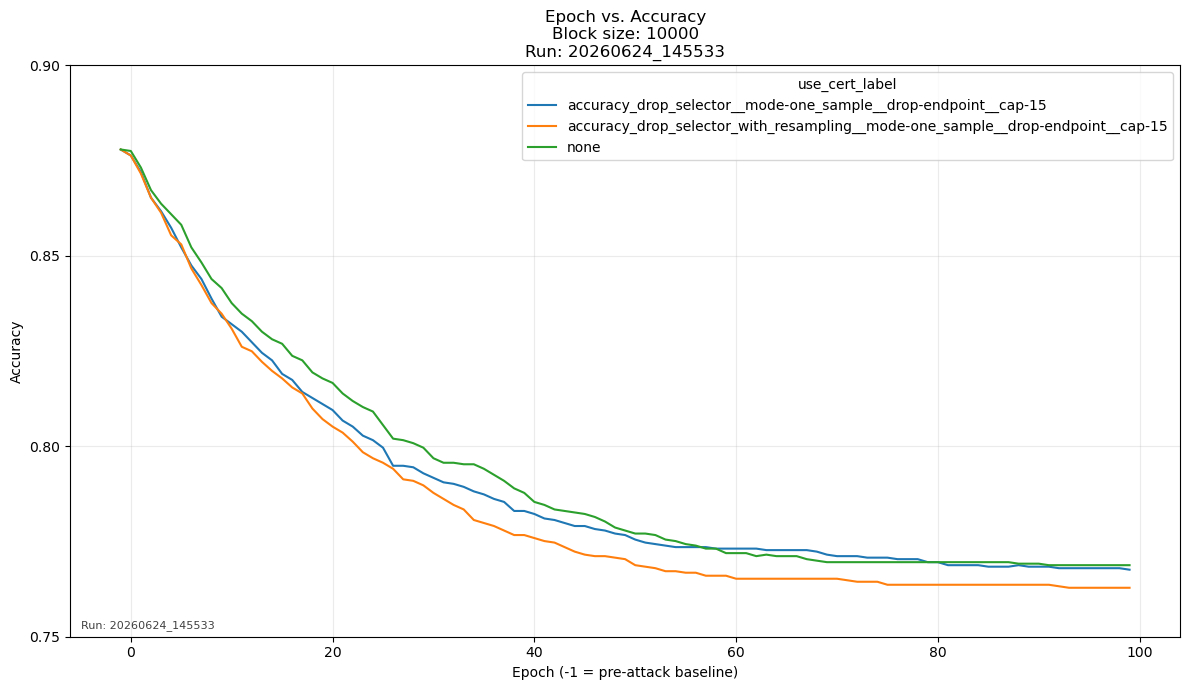

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_differences__run-20260624_145533.csv
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-2000.png


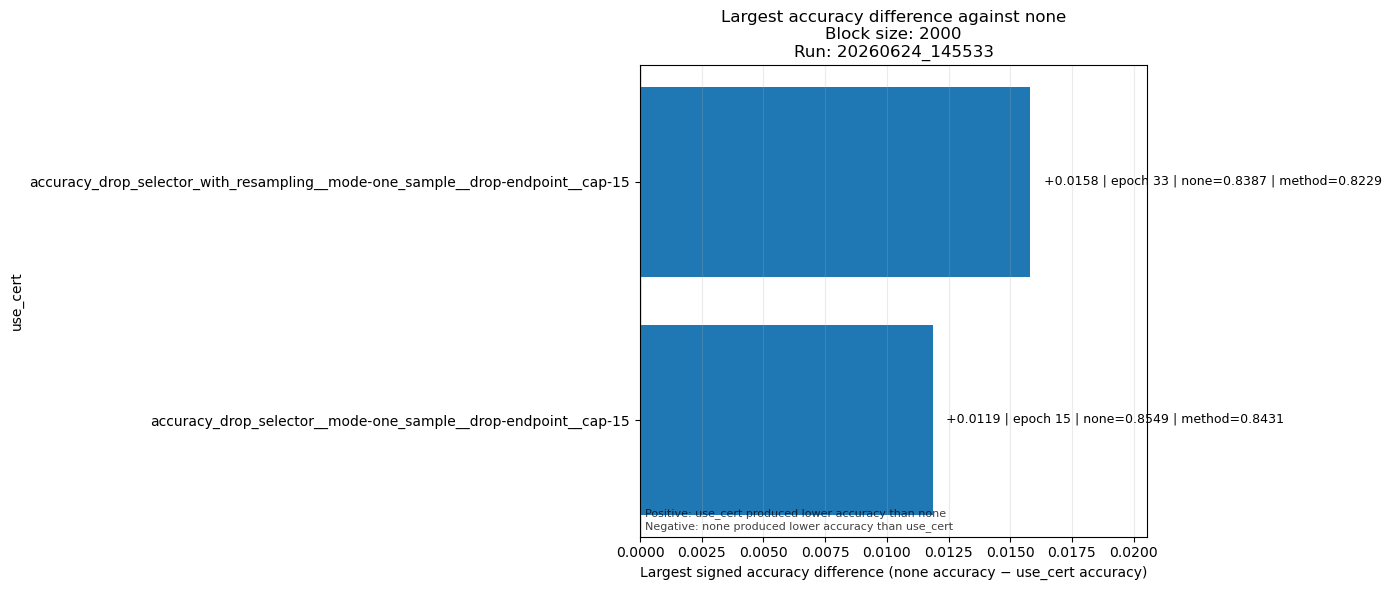

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-4000.png


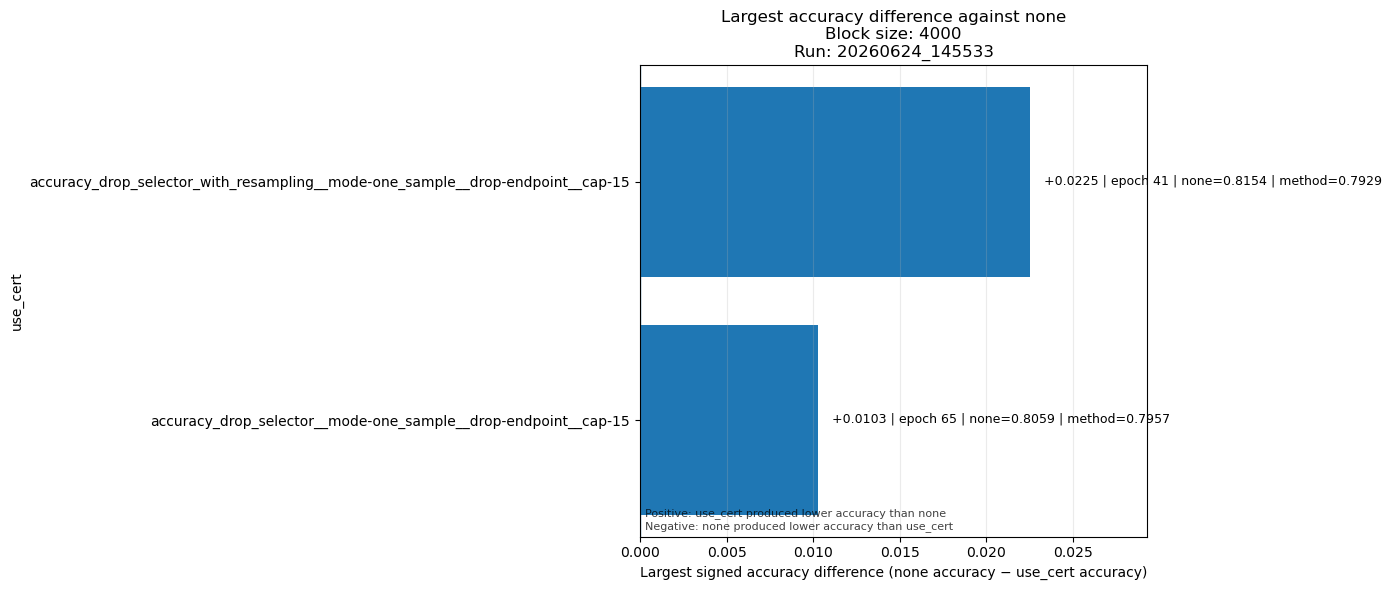

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-6000.png


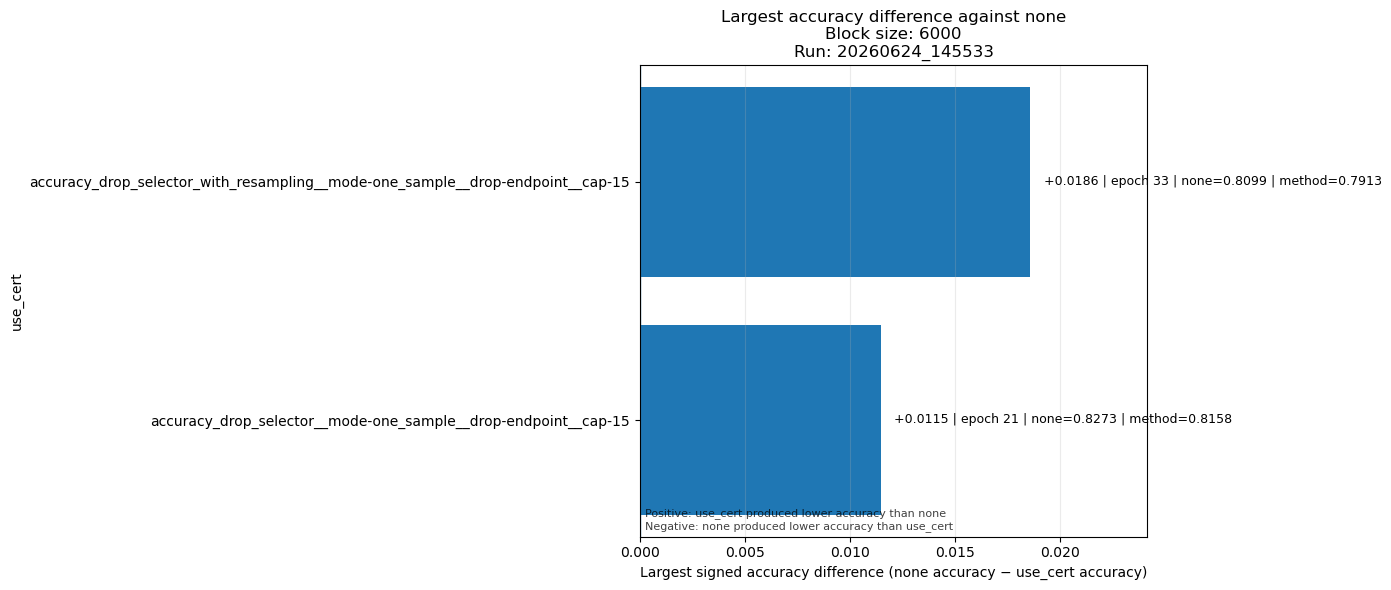

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-8000.png


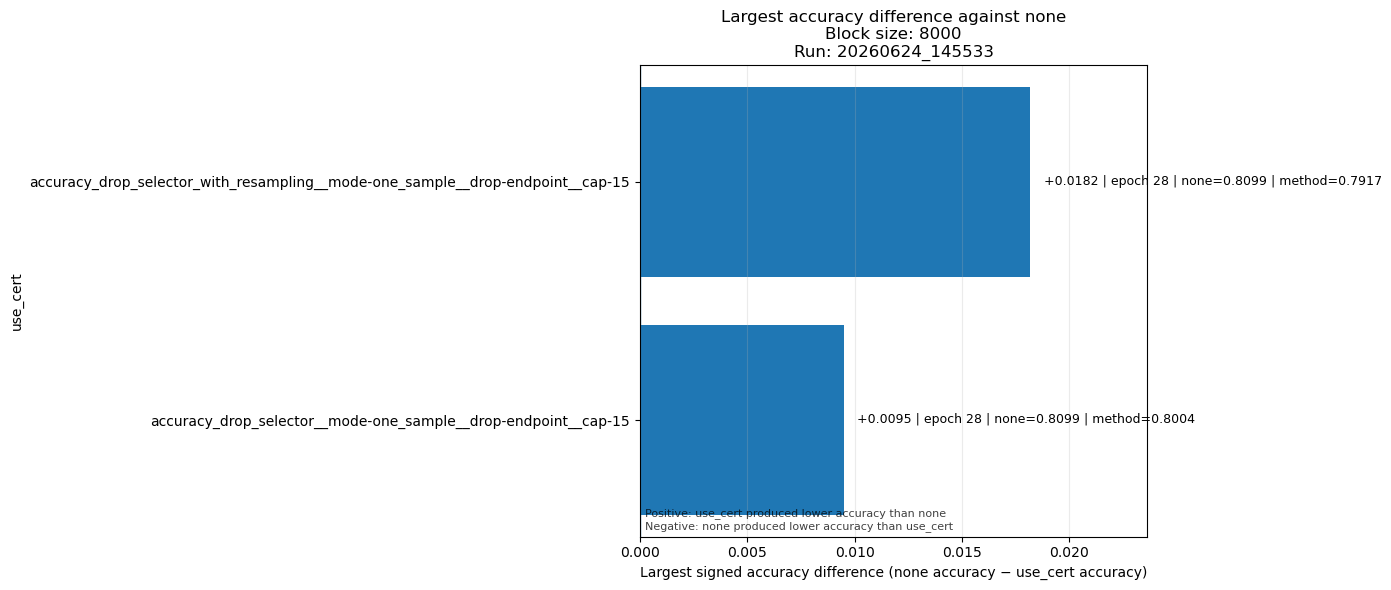

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-10000.png


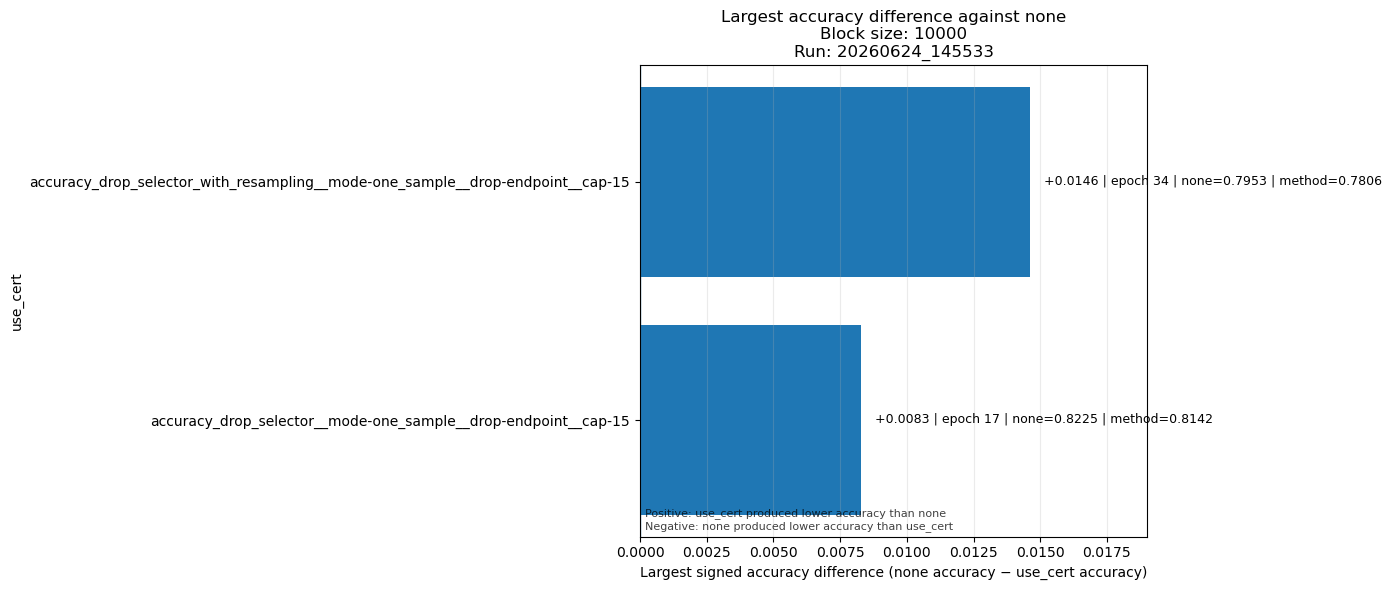


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_142349
Block sizes: ['20000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349\epoch_accuracy__run-20260624_142349__block_size-20000.png


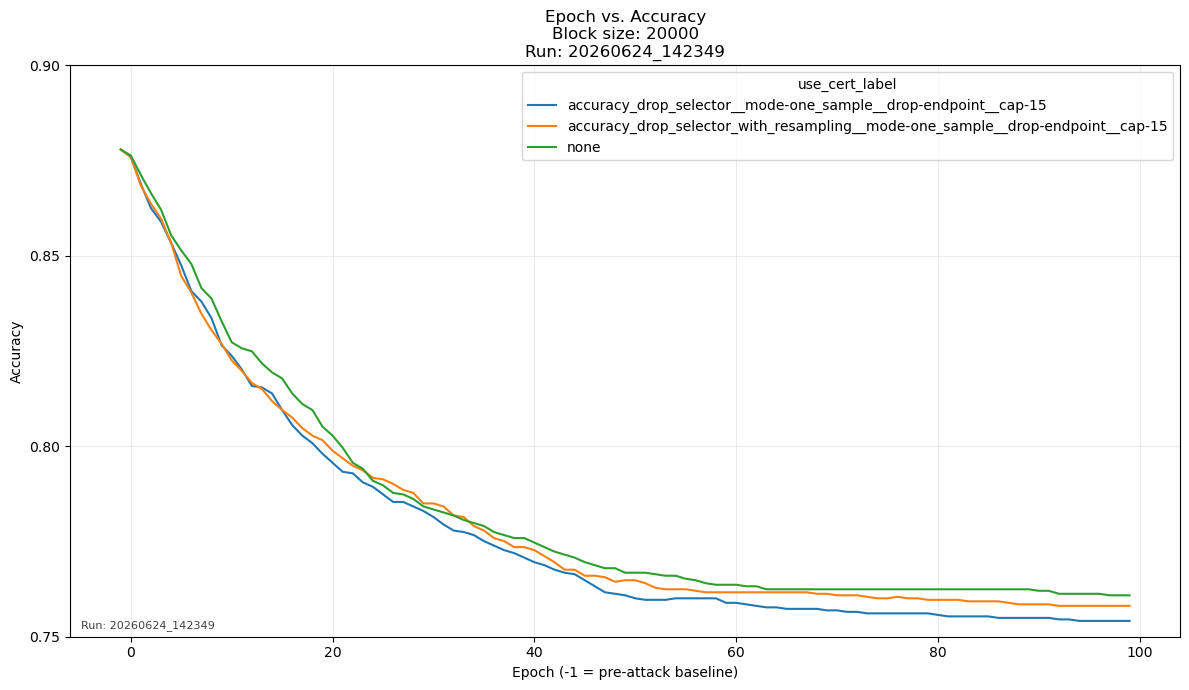


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_144122
Block sizes: ['2000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122\epoch_accuracy__run-20260624_144122__block_size-2000.png


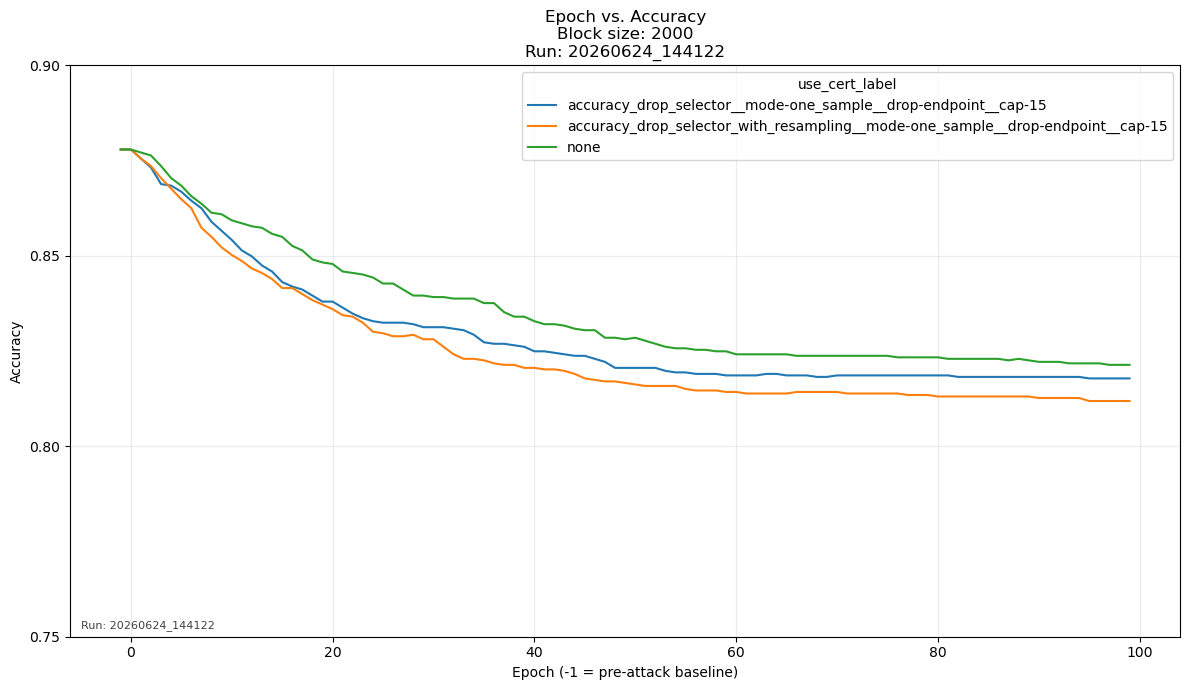


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260628_133648
Block sizes: ['4000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\plots__run-20260628_133648
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\plots__run-20260628_133648\epoch_accuracy__run-20260628_133648__block_size-4000.png


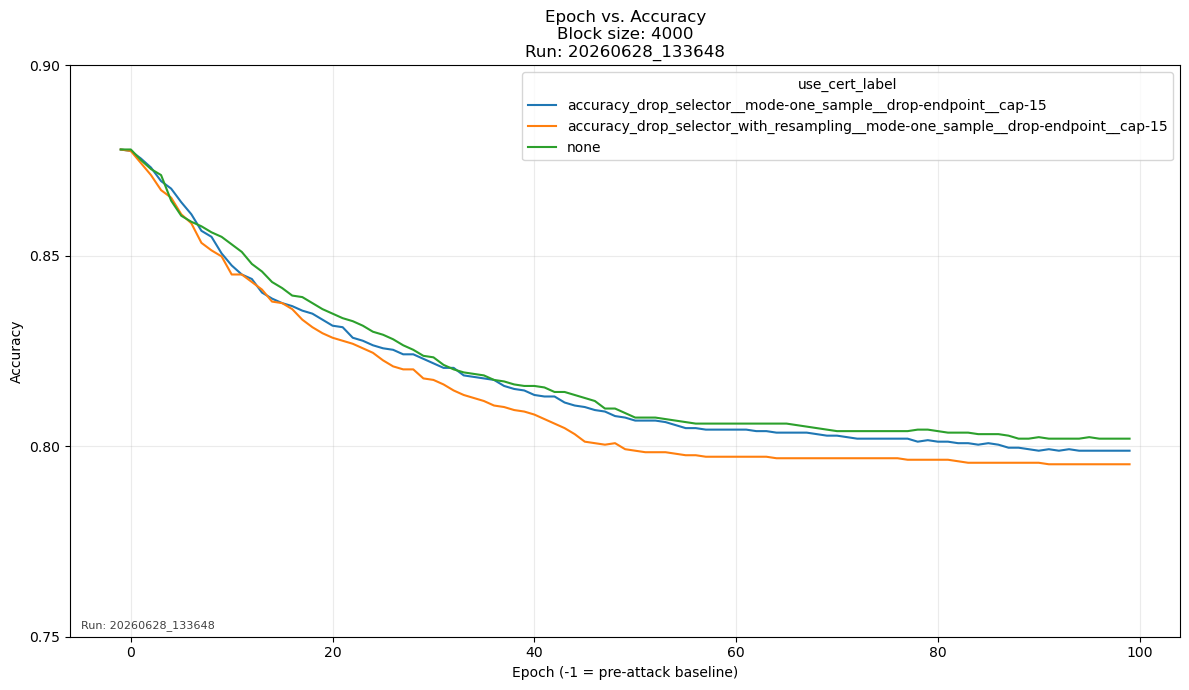


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260629_020044
Block sizes: ['4000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\plots__run-20260629_020044
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\plots__run-20260629_020044\epoch_accuracy__run-20260629_020044__block_size-4000.png


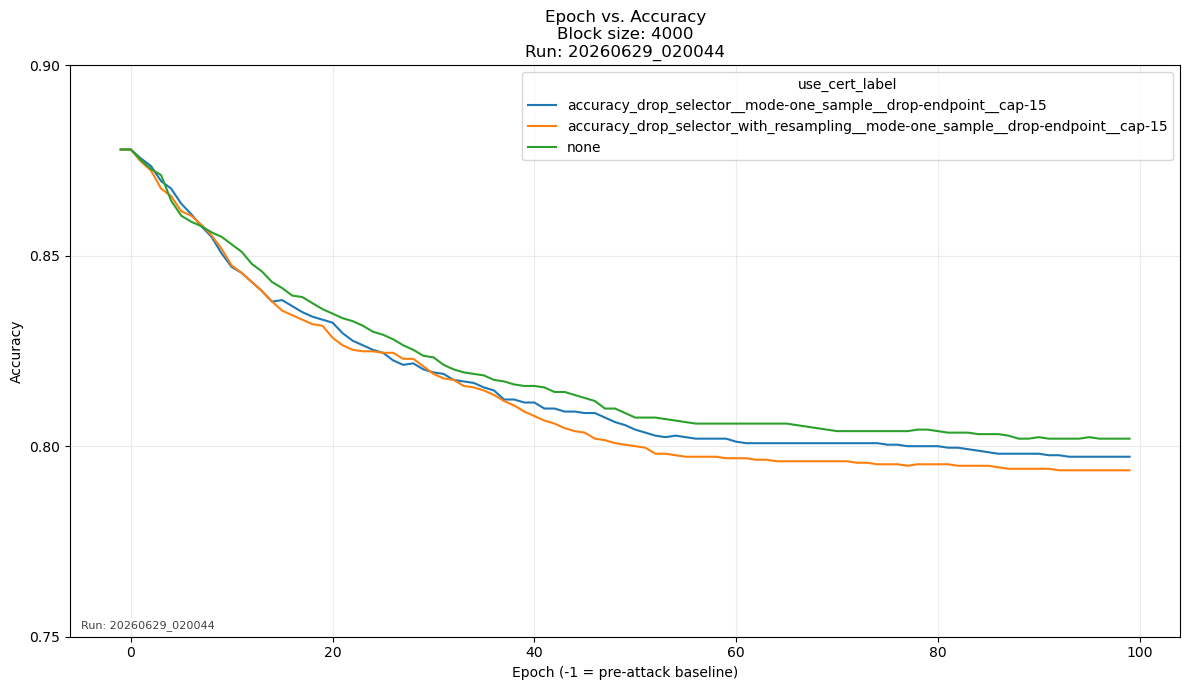


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_143059
Block sizes: ['5000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059\epoch_accuracy__run-20260624_143059__block_size-5000.png


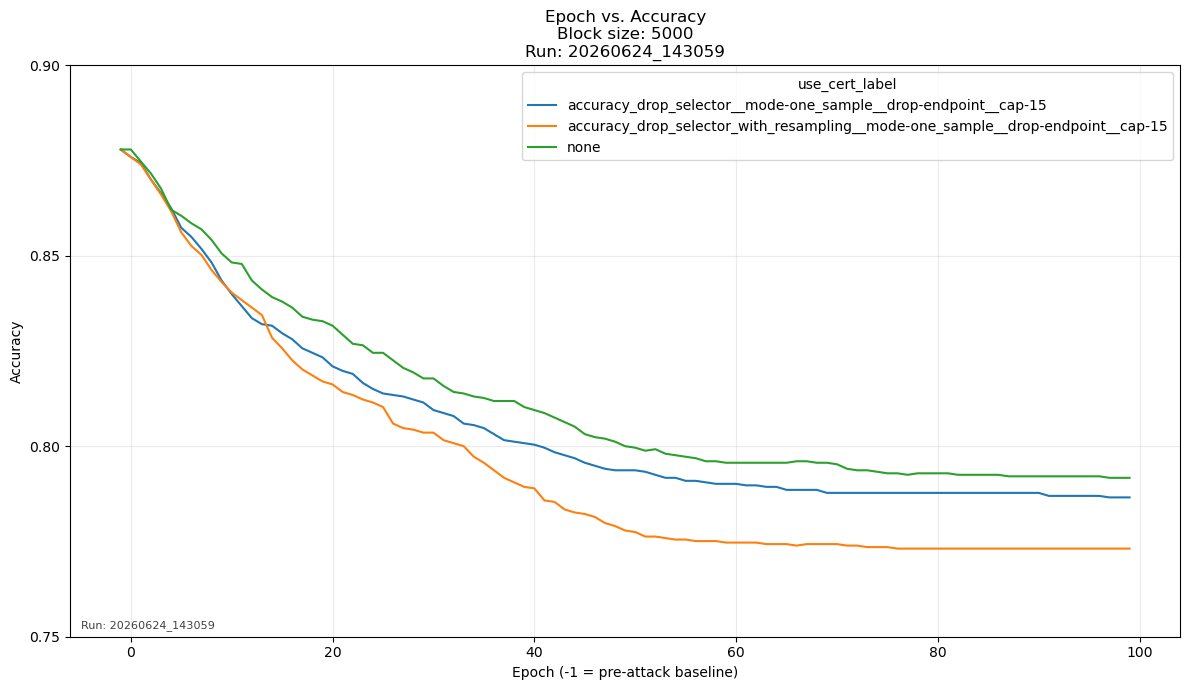


Finished processing all epoch CSV files.


In [28]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Epoch -1 represents the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]


# ============================================================
# Helper functions
# ============================================================

def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if (
                column.lower()
                .replace(".", "_")
                .replace("-", "_")
                .endswith("block_size")
            )
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def calculate_max_accuracy_differences(
    run_df,
    epoch_col,
    accuracy_col,
    method_col,
    block_size_col,
):
    """
    For every block size and every non-'none' method:

    1. Average duplicate rows for each epoch and method.
    2. Align the method with 'none' by epoch.
    3. Calculate:

           signed_difference = none_accuracy - method_accuracy

    4. Select the epoch with the largest absolute difference.

    Interpretation:
        positive -> use_cert achieved lower accuracy than none
        negative -> none achieved lower accuracy than use_cert
    """
    rows = []

    if method_col is None:
        return pd.DataFrame()

    for block_size, block_df in run_df.groupby(
        block_size_col,
        dropna=False,
    ):
        if pd.isna(block_size):
            continue

        averaged = (
            block_df
            .groupby(
                [epoch_col, method_col],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        pivot = averaged.pivot(
            index=epoch_col,
            columns=method_col,
            values=accuracy_col,
        )

        none_column = next(
            (
                column
                for column in pivot.columns
                if str(column).strip().lower() == "none"
            ),
            None,
        )

        if none_column is None:
            print(
                f"Skipping difference analysis for "
                f"block_size={format_block_size(block_size)}: "
                "no 'none' method found."
            )
            continue

        for method in pivot.columns:
            method_label = normalize_method_name(method)

            if method == none_column:
                continue

            if is_excluded_method(method_label):
                continue

            comparison = pivot[
                [none_column, method]
            ].dropna()

            if comparison.empty:
                continue

            signed_difference = (
                comparison[none_column]
                - comparison[method]
            )

            max_epoch = signed_difference.abs().idxmax()

            none_accuracy = float(
                comparison.loc[max_epoch, none_column]
            )

            method_accuracy = float(
                comparison.loc[max_epoch, method]
            )

            max_signed_difference = float(
                signed_difference.loc[max_epoch]
            )

            rows.append({
                "block_size": float(block_size),
                "use_cert": method_label,
                "epoch": int(max_epoch),
                "none_accuracy": none_accuracy,
                "use_cert_accuracy": method_accuracy,
                "signed_difference": max_signed_difference,
                "absolute_difference": abs(max_signed_difference),
                "better_method": (
                    method_label
                    if max_signed_difference > 0
                    else "none"
                    if max_signed_difference < 0
                    else "equal"
                ),
            })

    return pd.DataFrame(rows)


# ============================================================
# Find all epochs.csv files recursively
# ============================================================

csv_files = sorted(
    SWEEP_ROOT.rglob("epochs.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No epochs.csv files found below: "
        f"{SWEEP_ROOT.resolve()}"
    )

print(f"Found {len(csv_files)} epoch CSV file(s).")

for path in csv_files:
    print(" -", path)


# ============================================================
# Process every epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        EPOCH_CANDIDATES,
    )

    accuracy_col = find_first_existing_column(
        df,
        ACCURACY_CANDIDATES,
    )

    method_col = find_first_existing_column(
        df,
        METHOD_CANDIDATES,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        RUN_GROUP_CANDIDATES,
    )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue

    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue

    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    # --------------------------------------------------------
    # Convert relevant columns to numeric
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split CSV into run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        run_groups = [
            (
                csv_path.parent.name,
                df,
            )
        ]

    # ========================================================
    # Process every run group separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        safe_run_identifier = safe_filename(
            run_identifier
        )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        plot_output_dir = (
            csv_path.parent
            / f"plots__run-{safe_run_identifier}"
        )

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        print()
        print("-" * 100)
        print("Run:", run_identifier)
        print(
            "Block sizes:",
            [
                format_block_size(value)
                for value in block_sizes
            ],
        )
        print("Output folder:", plot_output_dir)

        # ====================================================
        # 1. 3D plot when the run has multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = normalize_method_name(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if is_excluded_method(method_label):
                    continue

                if pd.isna(block_size):
                    continue

                series = (
                    group
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if series.empty:
                    continue

                epoch_values = series.index.to_numpy()
                accuracy_values = series.to_numpy()

                block_size_values = [
                    float(block_size)
                ] * len(series)

                axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Epoch vs. Accuracy vs. Block Size\n"
                    f"Run: {run_identifier}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for the 3D plot."
                )

        # ====================================================
        # 2. Separate epoch-accuracy plot for each block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(12, 7)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = normalize_method_name(method)

                    if is_excluded_method(method_label):
                        continue

                    series = (
                        method_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                        label=method_label,
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                series = (
                    block_df
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if not series.empty:
                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                    )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    f"Skipping block_size="
                    f"{format_block_size(block_size)}: "
                    "no valid series."
                )
                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Epoch vs. Accuracy\n"
                f"Block size: {block_size_label}\n"
                f"Run: {run_identifier}"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            add_run_label(
                axis,
                run_identifier,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

        # ====================================================
        # 3. Maximum difference against "none"
        #    Only for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1 and method_col is not None:
            max_difference_df = (
                calculate_max_accuracy_differences(
                    run_df=run_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            )

            if max_difference_df.empty:
                print(
                    "No valid none-vs-use_cert comparisons "
                    f"found for run {run_identifier}."
                )

            else:
                # Save all numerical difference results.
                difference_csv_path = (
                    plot_output_dir
                    / (
                        "max_accuracy_differences"
                        f"__run-{safe_run_identifier}.csv"
                    )
                )

                if SAVE_PLOTS:
                    max_difference_df.to_csv(
                        difference_csv_path,
                        index=False,
                    )

                    print(
                        "Saved:",
                        difference_csv_path,
                    )

                # --------------------------------------------
                # One difference plot for each block size
                # --------------------------------------------

                for block_size in sorted(
                    max_difference_df[
                        "block_size"
                    ].unique()
                ):
                    block_result = (
                        max_difference_df[
                            max_difference_df["block_size"]
                            == block_size
                        ]
                        .sort_values(
                            "absolute_difference",
                            ascending=True,
                        )
                        .copy()
                    )

                    if block_result.empty:
                        continue

                    figure_height = max(
                        6,
                        0.65 * len(block_result) + 3,
                    )

                    figure, axis = plt.subplots(
                        figsize=(13, figure_height)
                    )

                    methods = (
                        block_result["use_cert"]
                        .astype(str)
                        .tolist()
                    )

                    signed_differences = (
                        block_result[
                            "signed_difference"
                        ]
                        .to_numpy()
                    )

                    bars = axis.barh(
                        methods,
                        signed_differences,
                    )

                    axis.axvline(
                        0,
                        linewidth=1,
                        alpha=0.75,
                    )

                    largest_absolute_difference = max(
                        float(
                            block_result[
                                "absolute_difference"
                            ].max()
                        ),
                        0.001,
                    )

                    annotation_offset = (
                        largest_absolute_difference * 0.035
                    )

                    for bar, row in zip(
                        bars,
                        block_result.itertuples(
                            index=False
                        ),
                    ):
                        width = float(bar.get_width())

                        if width >= 0:
                            annotation_x = (
                                width + annotation_offset
                            )
                            horizontal_alignment = "left"
                        else:
                            annotation_x = (
                                width - annotation_offset
                            )
                            horizontal_alignment = "right"

                        axis.text(
                            annotation_x,
                            (
                                bar.get_y()
                                + bar.get_height() / 2
                            ),
                            (
                                f"{width:+.4f} | "
                                f"epoch {row.epoch} | "
                                f"none={row.none_accuracy:.4f} | "
                                f"method={row.use_cert_accuracy:.4f}"
                            ),
                            horizontalalignment=(
                                horizontal_alignment
                            ),
                            verticalalignment="center",
                            fontsize=9,
                        )

                    block_size_label = format_block_size(
                        block_size
                    )

                    axis.set_xlabel(
                        "Largest signed accuracy difference "
                        "(none accuracy − use_cert accuracy)"
                    )

                    axis.set_ylabel("use_cert")

                    axis.set_title(
                        "Largest accuracy difference against none\n"
                        f"Block size: {block_size_label}\n"
                        f"Run: {run_identifier}"
                    )

                    axis.grid(
                        visible=True,
                        axis="x",
                        alpha=0.25,
                    )

                    axis.margins(
                        x=0.30,
                    )

                    axis.text(
                        0.01,
                        0.01,
                        (
                            "Positive: use_cert produced lower accuracy "
                            "than none\n"
                            "Negative: none produced lower accuracy "
                            "than use_cert"
                        ),
                        transform=axis.transAxes,
                        fontsize=8,
                        alpha=0.75,
                        horizontalalignment="left",
                        verticalalignment="bottom",
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_difference_vs_none"
                            f"__run-{safe_run_identifier}"
                            f"__block_size-{block_size_label}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

print()
print("=" * 100)
print("Finished processing all epoch CSV files.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [25]:

# ============================================================
# RQ1 EXPERIMENT:
# When and why does PR-BCD miss harmful candidate edges?
#
# This cell:
#   1. instruments PRBCD without changing its optimization,
#   2. constructs an empirical high-budget reference,
#   3. runs a block-size sweep,
#   4. measures discovery, survival, final overlap and accuracy,
#   5. saves raw/aggregated results and plots.
#
# Prerequisites:
#   - Run the notebook through victim training and graph preparation.
#   - For selector methods, also run the LP-GNN training cell first.
# ============================================================

from __future__ import annotations

from collections import Counter
from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer
import gc
import json
import math
import os
import random
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

try:
    from scipy.stats import t as student_t
except Exception:
    student_t = None

from DeleteCache import delete_pert_files_and_folders
from experiments import experiment_global_attack_direct
from sparse_smoothing.utils import load_and_standardize
from rgnn_at_scale.attacks.prbcd import PRBCD


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

# The current notebook has one victim model cached for SEED.
# Add further victim seeds only after training/caching one victim per seed.
RQ1_VICTIM_SEEDS = [int(SEED)]

# Independent PRBCD sampling repetitions for the same victim.
# Use 3 while developing; use at least 5 (preferably 10) for final results.
RQ1_REFERENCE_RUNS = 3
RQ1_EVAL_REPEATS = 3

RQ1_EPSILON = 0.05

# High-budget block used only to construct the empirical reference.
RQ1_REFERENCE_BLOCK_SIZE = min(
    int(PRBCD_SEARCH_SPACE),
    int(n_nodes * (n_nodes - 1) // 2),
)

# Ordinary PRBCD blocks to compare.
RQ1_BLOCK_SIZES = [1_000, 2_000, 4_000, 8_000, 16_000]

RQ1_EPOCHS = 100
RQ1_FINE_TUNE_EPOCHS = 50

# Core RQ1 should first be run with vanilla PRBCD only.
# After that works, uncomment the selector variants.
RQ1_METHODS = [
    "none",
    # "accuracy_drop_selector",
    # "accuracy_drop_selector_with_resampling",
]

# Number of high-ranked gradient/weight edges per reference definition.
RQ1_ATTACK_BUDGET = max(1, round(RQ1_EPSILON * n_undirected))
RQ1_REFERENCE_TOP_K = max(4 * RQ1_ATTACK_BUDGET, 500)

RQ1_MODEL_STORAGE_TYPE = "demo_custom_split"
RQ1_ARTIFACT_DIR = "cache"
RQ1_PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
RQ1_PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

RQ1_STOP_ON_ERROR = True

RQ1_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RQ1_OUT_DIR = (
    Path("extendedPlotting")
    / "rq1_prbcd_miss_conditions"
    / f"{DATASET}__{RQ1_RUN_ID}"
)
RQ1_RAW_DIR = RQ1_OUT_DIR / "raw"
RQ1_OUT_DIR.mkdir(parents=True, exist_ok=True)
RQ1_RAW_DIR.mkdir(parents=True, exist_ok=True)

print("RQ1 output:", RQ1_OUT_DIR.resolve())
print("Attack budget:", RQ1_ATTACK_BUDGET)
print("Reference block size:", RQ1_REFERENCE_BLOCK_SIZE)
print("Reference top-k:", RQ1_REFERENCE_TOP_K)
print("Evaluation block sizes:", RQ1_BLOCK_SIZES)
print("Methods:", RQ1_METHODS)

if RQ1_REFERENCE_BLOCK_SIZE <= RQ1_ATTACK_BUDGET:
    raise ValueError(
        "RQ1_REFERENCE_BLOCK_SIZE must be larger than the attack budget."
    )

for block_size in RQ1_BLOCK_SIZES:
    if block_size <= RQ1_ATTACK_BUDGET:
        raise ValueError(
            f"Block size {block_size} must be larger than "
            f"attack budget {RQ1_ATTACK_BUDGET}."
        )


# ------------------------------------------------------------
# 2. Reuse the notebook's selector configuration
# ------------------------------------------------------------

def _first_sweep_value(name, key, default):
    sweep = globals().get(name, {})
    value = sweep.get(key, default)
    if isinstance(value, (list, tuple)):
        return value[0]
    return value


RQ1_SELECTOR_PARAMS = {
    "accuracy_drop_selector_mode": _first_sweep_value(
        "SELECTOR_SWEEP", "accuracy_drop_selector_mode", "one_sample"
    ),
    "n_candidates_k_sample": int(_first_sweep_value(
        "SELECTOR_SWEEP", "n_candidates_k_sample", 2_000
    )),
    "n_candidates_one_sample": int(_first_sweep_value(
        "SELECTOR_SWEEP", "n_candidates_one_sample", 5_000
    )),
    "drop_mode": _first_sweep_value(
        "SELECTOR_SWEEP", "drop_mode", "endpoint"
    ),
    "acc_drop_threshold_k_samples": float(_first_sweep_value(
        "SELECTOR_SWEEP", "acc_drop_threshold_k_samples", 1e-3
    )),
    "loss_drop_threshold_k_samples": float(_first_sweep_value(
        "SELECTOR_SWEEP", "loss_drop_threshold_k_samples", 1e-3
    )),
    "k_samples_batch": int(_first_sweep_value(
        "SELECTOR_SWEEP", "k_samples_batch", 10
    )),
    "training_data_node_cap": int(_first_sweep_value(
        "SELECTOR_SWEEP", "training_data_node_cap", 15
    )),
    "tau": float(_first_sweep_value(
        "SELECTOR_SWEEP", "tau", 0.8
    )),
    "score_batch_size": int(_first_sweep_value(
        "SELECTOR_SWEEP", "score_batch_size", 1_000
    )),
    "max_sampling_tries": int(_first_sweep_value(
        "SELECTOR_SWEEP", "max_sampling_tries", 2_000_000
    )),
    "exclude_tried": bool(_first_sweep_value(
        "SELECTOR_SWEEP", "exclude_tried", True
    )),
    "lp_hit_rate_detour": False,
}

_SELECTOR_METHODS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
}

if any(method in _SELECTOR_METHODS for method in RQ1_METHODS):
    if "lp_model" not in globals():
        raise RuntimeError(
            "A selector method was enabled, but lp_model does not exist. "
            "Run the selector training cell first."
        )


# ------------------------------------------------------------
# 3. Graph object expected by experiment_global_attack_direct
# ------------------------------------------------------------

if "graph_sparse" not in globals():
    graph_sparse = load_and_standardize(
        os.path.join("data", f"{DATASET}.npz")
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
# 4. Read RQ1 diagnostics from returned attack_statistics
# ------------------------------------------------------------
#
# PRBCD is responsible for recording all changing attack state in
# self.attack_statistics["rq1"].  This notebook cell does not monkey-patch
# PRBCD and does not inspect a live attack object.
#
# Required nested schema:
#
# attack_statistics["rq1"] = {
#     "metric_rows": [...],                 # optional; top-level metrics are a fallback
#     "final_linear_ids": LongTensor,
#     "positive_gradient_sum": FloatTensor, # reference runs
#     "max_weight": FloatTensor,            # reference runs
#     "times_seen": IntTensor,              # reference runs
#     "initial_block": LongTensor,           # evaluation runs
#     "epoch_blocks": {epoch: LongTensor},   # evaluation runs, before resampling
#     "resample_events": [                   # evaluation runs
#         {"epoch": int, "before": LongTensor, "after": LongTensor},
#     ],
# }
#
# The rq1_sampling_seed passed below must be used by PRBCD to seed its
# candidate sampling stream independently of the victim-model seed.
# ------------------------------------------------------------

# Prevent an old debugging breakpoint in PRBCD from stopping notebook runs.
# Removing the breakpoint from PRBCD itself is still preferable.
os.environ["PYTHONBREAKPOINT"] = "0"


def _rq1_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() != 1:
            raise ValueError("Expected a scalar tensor.")
        return value.detach().cpu().item()
    if isinstance(value, np.generic):
        return value.item()
    return value


def _rq1_as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [_rq1_python_scalar(item) for item in value]
    return [_rq1_python_scalar(value)]


def _rq1_is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def _rq1_find_attack_statistics(obj, seen=None):
    """Recursively locate the PRBCD attack_statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        # Prefer an explicitly wrapped statistics dictionary.
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                "rq1" in candidate
                or _rq1_is_metric_series(candidate.get("accuracy"))
                or _rq1_is_metric_series(candidate.get("loss"))
            ):
                return candidate

        # The object itself may already be attack_statistics.
        if (
            "rq1" in obj
            or (
                _rq1_is_metric_series(obj.get("accuracy"))
                and _rq1_is_metric_series(obj.get("loss"))
            )
        ):
            return obj

        for value in obj.values():
            found = _rq1_find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = _rq1_find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def _rq1_to_cpu_tensor(value, *, dtype, name, allow_none=False):
    if value is None:
        if allow_none:
            return None
        raise KeyError(f"Missing RQ1 attack-statistics field: {name}")

    if isinstance(value, torch.Tensor):
        tensor = value.detach().cpu().to(dtype=dtype)
    else:
        tensor = torch.as_tensor(value, dtype=dtype)

    return tensor.flatten().contiguous()


def _rq1_normalize_epoch_blocks(value):
    if value is None:
        return {}

    if isinstance(value, dict):
        items = value.items()
    elif isinstance(value, (list, tuple)):
        items = enumerate(value)
    else:
        raise TypeError(
            "attack_statistics['rq1']['epoch_blocks'] must be a dict or list."
        )

    normalized = {}
    for epoch, block in items:
        normalized[int(epoch)] = _rq1_to_cpu_tensor(
            block,
            dtype=torch.long,
            name=f"epoch_blocks[{epoch}]",
        )
    return normalized


def _rq1_normalize_resample_events(value):
    if value is None:
        return []
    if not isinstance(value, (list, tuple)):
        raise TypeError(
            "attack_statistics['rq1']['resample_events'] must be a list."
        )

    normalized = []
    for event_index, event in enumerate(value):
        if not isinstance(event, dict):
            raise TypeError(
                f"resample_events[{event_index}] must be a dictionary."
            )
        normalized.append({
            "epoch": int(event["epoch"]),
            "before": _rq1_to_cpu_tensor(
                event.get("before"),
                dtype=torch.long,
                name=f"resample_events[{event_index}].before",
            ),
            "after": _rq1_to_cpu_tensor(
                event.get("after"),
                dtype=torch.long,
                name=f"resample_events[{event_index}].after",
            ),
        })
    return normalized


def _rq1_build_metric_rows(
    attack_stats,
    rq1_stats,
    *,
    victim_seed,
    sampling_seed,
    run_name,
    method,
    block_size,
    is_reference,
):
    """Use nested metric_rows when present, otherwise reuse existing PRBCD lists."""
    supplied = rq1_stats.get("metric_rows")

    if supplied is not None:
        if not isinstance(supplied, (list, tuple)):
            raise TypeError(
                "attack_statistics['rq1']['metric_rows'] must be a list."
            )
        base_rows = [dict(row) for row in supplied]
    else:
        metric_lists = {
            "accuracy": _rq1_as_list(attack_stats.get("accuracy")),
            "loss": _rq1_as_list(attack_stats.get("loss")),
            "probability_mass_update": _rq1_as_list(
                attack_stats.get("probability_mass_update")
            ),
            "probability_mass_projected": _rq1_as_list(
                attack_stats.get("probability_mass_projected")
            ),
        }
        length = max((len(values) for values in metric_lists.values()), default=0)
        base_rows = []
        for stat_idx in range(length):
            # Existing PRBCD lists include the clean baseline at index 0.
            epoch = stat_idx - 1
            row = {"epoch": int(epoch)}
            for key, values in metric_lists.items():
                row[key] = values[stat_idx] if stat_idx < len(values) else np.nan
            base_rows.append(row)

    rows = []
    for row in base_rows:
        row = dict(row)
        row.setdefault("epoch", len(rows) - 1)
        row.update({
            "victim_seed": int(victim_seed),
            "sampling_seed": int(sampling_seed),
            "run_name": str(run_name),
            "method": str(method),
            "block_size": int(block_size),
            "is_reference": bool(is_reference),
        })
        rows.append(row)

    return rows


def _rq1_extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return float(_rq1_python_scalar(first["accuracy"]))

        value = result.get("accuracy")
        if value is not None and not _rq1_is_metric_series(value):
            return float(_rq1_python_scalar(value))

    return None


def _rq1_state_from_returned_statistics(
    result,
    *,
    victim_seed,
    sampling_seed,
    run_name,
    method,
    block_size,
    is_reference,
    runtime_seconds,
):
    attack_stats = _rq1_find_attack_statistics(result)
    if attack_stats is None:
        raise KeyError(
            "No returned PRBCD attack_statistics dictionary was found. "
            "Ensure experiment_global_attack_direct includes attack_statistics "
            "in its returned result."
        )

    rq1_stats = attack_stats.get("rq1")
    if not isinstance(rq1_stats, dict):
        raise KeyError(
            "Returned attack_statistics has no dictionary at key 'rq1'."
        )

    state = {
        "victim_seed": int(victim_seed),
        "sampling_seed": int(sampling_seed),
        "run_name": str(run_name),
        "method": str(method),
        "block_size": int(block_size),
        "is_reference": bool(is_reference),
        "runtime_seconds": float(runtime_seconds),
        "result_final_accuracy": _rq1_extract_final_accuracy(result),
        "error": None,
        "metric_rows": _rq1_build_metric_rows(
            attack_stats,
            rq1_stats,
            victim_seed=victim_seed,
            sampling_seed=sampling_seed,
            run_name=run_name,
            method=method,
            block_size=block_size,
            is_reference=is_reference,
        ),
        "final_linear_ids": _rq1_to_cpu_tensor(
            rq1_stats.get("final_linear_ids"),
            dtype=torch.long,
            name="final_linear_ids",
        ),
        "positive_gradient_sum": None,
        "max_weight": None,
        "times_seen": None,
        "initial_block": None,
        "epoch_blocks": {},
        "resample_events": [],
    }

    if is_reference:
        state["positive_gradient_sum"] = _rq1_to_cpu_tensor(
            rq1_stats.get("positive_gradient_sum"),
            dtype=torch.float32,
            name="positive_gradient_sum",
        )
        state["max_weight"] = _rq1_to_cpu_tensor(
            rq1_stats.get("max_weight"),
            dtype=torch.float32,
            name="max_weight",
        )
        state["times_seen"] = _rq1_to_cpu_tensor(
            rq1_stats.get("times_seen"),
            dtype=torch.int32,
            name="times_seen",
        )

        lengths = {
            state["positive_gradient_sum"].numel(),
            state["max_weight"].numel(),
            state["times_seen"].numel(),
        }
        if len(lengths) != 1:
            raise ValueError(
                "positive_gradient_sum, max_weight and times_seen must have "
                "the same length."
            )
    else:
        initial_block = rq1_stats.get("initial_block")
        state["initial_block"] = (
            _rq1_to_cpu_tensor(
                initial_block,
                dtype=torch.long,
                name="initial_block",
            )
            if initial_block is not None
            else None
        )
        state["epoch_blocks"] = _rq1_normalize_epoch_blocks(
            rq1_stats.get("epoch_blocks")
        )
        state["resample_events"] = _rq1_normalize_resample_events(
            rq1_stats.get("resample_events")
        )

        if not state["epoch_blocks"]:
            raise ValueError(
                "Evaluation attack_statistics['rq1']['epoch_blocks'] is empty."
            )

    return state


print("RQ1 cell will read diagnostics from returned attack_statistics['rq1'].")


# ------------------------------------------------------------
# 5. Experiment helpers
# ------------------------------------------------------------


def _rq1_new_error_state(
    *,
    victim_seed,
    sampling_seed,
    run_name,
    method,
    block_size,
    is_reference,
    runtime_seconds,
    exc,
):
    return {
        "victim_seed": int(victim_seed),
        "sampling_seed": int(sampling_seed),
        "run_name": str(run_name),
        "method": str(method),
        "block_size": int(block_size),
        "is_reference": bool(is_reference),
        "metric_rows": [],
        "final_linear_ids": torch.empty(0, dtype=torch.long),
        "positive_gradient_sum": None,
        "max_weight": None,
        "times_seen": None,
        "initial_block": None,
        "epoch_blocks": {},
        "resample_events": [],
        "runtime_seconds": float(runtime_seconds),
        "result_final_accuracy": None,
        "error": {
            "type": type(exc).__name__,
            "message": str(exc),
            "traceback": traceback.format_exc(),
        },
    }


def _rq1_run_attack(
    *,
    victim_seed,
    sampling_seed,
    block_size,
    method,
    run_name,
    is_reference,
):
    attack_params = {
        "block_size": int(block_size),
        "epochs": int(RQ1_EPOCHS),
        "fine_tune_epochs": int(RQ1_FINE_TUNE_EPOCHS),
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",
        "lp_model": (
            lp_model
            if method in _SELECTOR_METHODS
            else None
        ),
        # PRBCD must store these constructor kwargs and use them in _attack.
        "rq1_enabled": True,
        "rq1_is_reference": bool(is_reference),
        "rq1_sampling_seed": int(sampling_seed),
    }

    selector_params = (
        dict(RQ1_SELECTOR_PARAMS)
        if method in _SELECTOR_METHODS
        else {}
    )

    delete_pert_files_and_folders(
        cache_dir=RQ1_ARTIFACT_DIR,
        pert_adj_storage_type=RQ1_PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=RQ1_PERT_ATTR_STORAGE_TYPE,
    )

    print()
    print("=" * 88)
    print("RQ1 run:", run_name)
    print("victim_seed:", victim_seed)
    print("sampling_seed:", sampling_seed)
    print("method:", method)
    print("block_size:", block_size)
    print("reference:", is_reference)

    started = timer()

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack="PRBCD",
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[RQ1_EPSILON],
            binary_attr=False,
            make_undirected=True,
            seed=int(victim_seed),
            artifact_dir=RQ1_ARTIFACT_DIR,
            pert_adj_storage_type=RQ1_PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=RQ1_PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=RQ1_MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=True,
            use_cert=method,
        )

        runtime_seconds = timer() - started
        state = _rq1_state_from_returned_statistics(
            result,
            victim_seed=victim_seed,
            sampling_seed=sampling_seed,
            run_name=run_name,
            method=method,
            block_size=block_size,
            is_reference=is_reference,
            runtime_seconds=runtime_seconds,
        )

    except Exception as exc:
        runtime_seconds = timer() - started
        state = _rq1_new_error_state(
            victim_seed=victim_seed,
            sampling_seed=sampling_seed,
            run_name=run_name,
            method=method,
            block_size=block_size,
            is_reference=is_reference,
            runtime_seconds=runtime_seconds,
            exc=exc,
        )
        print(state["error"]["traceback"])

        if RQ1_STOP_ON_ERROR:
            raise

    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return state


def _rq1_top_positive(score_tensor, k):
    positive_ids = torch.nonzero(
        score_tensor > 0,
        as_tuple=False,
    ).flatten()

    if positive_ids.numel() == 0:
        return torch.empty(0, dtype=torch.long)

    k = min(int(k), int(positive_ids.numel()))
    local = torch.topk(
        score_tensor[positive_ids],
        k=k,
        largest=True,
    ).indices
    return positive_ids[local].long()


def _rq1_ids_to_pairs(ids):
    ids = torch.as_tensor(ids, dtype=torch.long)
    if ids.numel() == 0:
        return torch.empty((2, 0), dtype=torch.long)
    return PRBCD.linear_to_triu_idx(
        int(n_nodes),
        ids,
    ).cpu()


_clean_pairs = edge_index.detach().cpu().long()
_clean_u = torch.minimum(_clean_pairs[0], _clean_pairs[1])
_clean_v = torch.maximum(_clean_pairs[0], _clean_pairs[1])
_clean_mask = _clean_u < _clean_v
_clean_linear_ids = PRBCD.triu_idx_to_linear_idx(
    int(n_nodes),
    torch.stack([
        _clean_u[_clean_mask],
        _clean_v[_clean_mask],
    ]),
)
RQ1_CLEAN_LINEAR_SET = set(
    torch.unique(_clean_linear_ids).tolist()
)


def _rq1_action_for_id(linear_id):
    return (
        "delete"
        if int(linear_id) in RQ1_CLEAN_LINEAR_SET
        else "add"
    )


def _rq1_state_to_compact_raw(state):
    compact = {
        "victim_seed": state["victim_seed"],
        "sampling_seed": state["sampling_seed"],
        "run_name": state["run_name"],
        "method": state["method"],
        "block_size": state["block_size"],
        "is_reference": state["is_reference"],
        "metric_rows": state["metric_rows"],
        "final_linear_ids": state["final_linear_ids"],
        "runtime_seconds": state["runtime_seconds"],
        "result_final_accuracy": state["result_final_accuracy"],
        "error": state["error"],
    }

    if state["is_reference"]:
        seen = (
            state["times_seen"] > 0
            if state["times_seen"] is not None
            else torch.zeros(0, dtype=torch.bool)
        )
        observed_ids = torch.nonzero(
            seen,
            as_tuple=False,
        ).flatten()
        compact.update({
            "observed_ids": observed_ids,
            "positive_gradient_sum": (
                state["positive_gradient_sum"][observed_ids]
                if state["positive_gradient_sum"] is not None
                else torch.empty(0)
            ),
            "max_weight": (
                state["max_weight"][observed_ids]
                if state["max_weight"] is not None
                else torch.empty(0)
            ),
            "times_seen": (
                state["times_seen"][observed_ids]
                if state["times_seen"] is not None
                else torch.empty(0, dtype=torch.int32)
            ),
        })
    else:
        compact.update({
            "initial_block": state["initial_block"],
            "epoch_blocks": state["epoch_blocks"],
            "resample_events": state["resample_events"],
        })

    return compact


# ------------------------------------------------------------
# 6. Stage A — construct the high-budget references
# ------------------------------------------------------------

references_by_victim_seed = {}
reference_edge_rows = []
reference_run_rows = []

for victim_seed in RQ1_VICTIM_SEEDS:
    n_possible = int(n_nodes * (n_nodes - 1) // 2)

    gradient_score = torch.zeros(
        n_possible, dtype=torch.float32
    )
    weight_score = torch.zeros(
        n_possible, dtype=torch.float32
    )
    final_frequency = torch.zeros(
        n_possible, dtype=torch.int16
    )

    for reference_run in range(RQ1_REFERENCE_RUNS):
        sampling_seed = (
            1_000_000
            + 100_000 * int(victim_seed)
            + reference_run
        )
        run_name = (
            f"reference__victim-{victim_seed}"
            f"__repeat-{reference_run}"
        )

        state = _rq1_run_attack(
            victim_seed=victim_seed,
            sampling_seed=sampling_seed,
            block_size=RQ1_REFERENCE_BLOCK_SIZE,
            method="none",
            run_name=run_name,
            is_reference=True,
        )

        torch.save(
            _rq1_state_to_compact_raw(state),
            RQ1_RAW_DIR / f"{run_name}.pt",
        )

        if state["error"] is not None:
            continue

        observed = torch.nonzero(
            state["times_seen"] > 0,
            as_tuple=False,
        ).flatten()

        if observed.numel() > 0:
            grad_values = state["positive_gradient_sum"][observed]
            weight_values = state["max_weight"][observed]

            grad_max = float(grad_values.max().item())
            weight_max = float(weight_values.max().item())

            if grad_max > 0:
                gradient_score[observed] += grad_values / grad_max

            if weight_max > 0:
                weight_score[observed] += weight_values / weight_max

        final_ids = state["final_linear_ids"].long()
        if final_ids.numel() > 0:
            final_frequency[final_ids] += 1

        reference_run_rows.append({
            "victim_seed": int(victim_seed),
            "reference_run": int(reference_run),
            "sampling_seed": int(sampling_seed),
            "block_size": int(RQ1_REFERENCE_BLOCK_SIZE),
            "runtime_seconds": state["runtime_seconds"],
            "result_final_accuracy": state[
                "result_final_accuracy"
            ],
            "n_observed_edges": int(observed.numel()),
            "n_final_edges": int(final_ids.numel()),
        })

        del state
        gc.collect()

    gradient_ids = _rq1_top_positive(
        gradient_score,
        RQ1_REFERENCE_TOP_K,
    )
    weight_ids = _rq1_top_positive(
        weight_score,
        RQ1_REFERENCE_TOP_K,
    )
    final_ids = torch.nonzero(
        final_frequency > 0,
        as_tuple=False,
    ).flatten().long()

    references = {
        "gradient": set(gradient_ids.tolist()),
        "weight": set(weight_ids.tolist()),
        "final": set(final_ids.tolist()),
    }
    references["union"] = (
        references["gradient"]
        | references["weight"]
        | references["final"]
    )

    if not references["union"]:
        raise RuntimeError(
            f"No empirical reference edges were produced for "
            f"victim seed {victim_seed}."
        )

    references_by_victim_seed[int(victim_seed)] = references

    all_reference_ids = sorted(references["union"])
    pairs = _rq1_ids_to_pairs(all_reference_ids)

    for position, linear_id in enumerate(all_reference_ids):
        reference_edge_rows.append({
            "victim_seed": int(victim_seed),
            "linear_id": int(linear_id),
            "u": int(pairs[0, position]),
            "v": int(pairs[1, position]),
            "action": _rq1_action_for_id(linear_id),
            "gradient_score": float(
                gradient_score[linear_id].item()
            ),
            "weight_score": float(
                weight_score[linear_id].item()
            ),
            "final_frequency": int(
                final_frequency[linear_id].item()
            ),
            "in_gradient_reference": (
                linear_id in references["gradient"]
            ),
            "in_weight_reference": (
                linear_id in references["weight"]
            ),
            "in_final_reference": (
                linear_id in references["final"]
            ),
            "in_union_reference": True,
        })

    print()
    print(f"Victim seed {victim_seed} reference sizes:")
    for reference_name, reference_set in references.items():
        print(
            f"  {reference_name:>8}: "
            f"{len(reference_set):,}"
        )


reference_edges_df = pd.DataFrame(reference_edge_rows)
reference_runs_df = pd.DataFrame(reference_run_rows)

reference_edges_df.to_csv(
    RQ1_OUT_DIR / "reference_edges.csv",
    index=False,
)
reference_runs_df.to_csv(
    RQ1_OUT_DIR / "reference_runs.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. Stage B — ordinary block-size sweep
# ------------------------------------------------------------

epoch_metric_rows = []
overlap_rows = []
resampling_rows = []
final_rows = []
discovery_rows = []

for victim_seed in RQ1_VICTIM_SEEDS:
    references = references_by_victim_seed[int(victim_seed)]

    for method in RQ1_METHODS:
        for block_size in RQ1_BLOCK_SIZES:
            for repeat in range(RQ1_EVAL_REPEATS):
                sampling_seed = (
                    2_000_000
                    + 100_000 * int(victim_seed)
                    + 10_000 * RQ1_METHODS.index(method)
                    + 100 * RQ1_BLOCK_SIZES.index(block_size)
                    + repeat
                )

                run_name = (
                    f"evaluation__victim-{victim_seed}"
                    f"__method-{method}"
                    f"__block-{block_size}"
                    f"__repeat-{repeat}"
                )

                state = _rq1_run_attack(
                    victim_seed=victim_seed,
                    sampling_seed=sampling_seed,
                    block_size=block_size,
                    method=method,
                    run_name=run_name,
                    is_reference=False,
                )

                torch.save(
                    _rq1_state_to_compact_raw(state),
                    RQ1_RAW_DIR / f"{run_name}.pt",
                )

                if state["error"] is not None:
                    final_rows.append({
                        "victim_seed": int(victim_seed),
                        "sampling_seed": int(sampling_seed),
                        "repeat": int(repeat),
                        "run_name": run_name,
                        "method": method,
                        "block_size": int(block_size),
                        "status": "error",
                        "error_type": state["error"]["type"],
                        "error_message": state["error"]["message"],
                    })
                    continue

                for row in state["metric_rows"]:
                    metric_row = dict(row)
                    metric_row["repeat"] = int(repeat)
                    epoch_metric_rows.append(metric_row)

                # --------------------------------------------
                # Reference overlap at every epoch
                # --------------------------------------------
                for epoch, block_tensor in sorted(
                    state["epoch_blocks"].items()
                ):
                    block_set = set(block_tensor.tolist())

                    for reference_name, reference_set in references.items():
                        overlap = block_set & reference_set

                        overlap_rows.append({
                            "victim_seed": int(victim_seed),
                            "sampling_seed": int(sampling_seed),
                            "repeat": int(repeat),
                            "run_name": run_name,
                            "method": method,
                            "block_size": int(block_size),
                            "epoch": int(epoch),
                            "reference_type": reference_name,
                            "n_reference": len(reference_set),
                            "n_block": len(block_set),
                            "n_overlap": len(overlap),
                            "reference_recall": (
                                len(overlap) / len(reference_set)
                                if reference_set
                                else np.nan
                            ),
                            "reference_precision": (
                                len(overlap) / len(block_set)
                                if block_set
                                else np.nan
                            ),
                        })

                # --------------------------------------------
                # Exact survival across each resampling step
                # --------------------------------------------
                for event in state["resample_events"]:
                    before_set = set(event["before"].tolist())
                    after_set = set(event["after"].tolist())

                    for reference_name, reference_set in references.items():
                        reference_before = (
                            before_set & reference_set
                        )
                        survived = (
                            reference_before & after_set
                        )

                        resampling_rows.append({
                            "victim_seed": int(victim_seed),
                            "sampling_seed": int(sampling_seed),
                            "repeat": int(repeat),
                            "run_name": run_name,
                            "method": method,
                            "block_size": int(block_size),
                            "epoch": int(event["epoch"]),
                            "reference_type": reference_name,
                            "n_reference_before": len(
                                reference_before
                            ),
                            "n_reference_survived": len(survived),
                            "reference_survival_rate": (
                                len(survived)
                                / len(reference_before)
                                if reference_before
                                else np.nan
                            ),
                            "whole_block_survival_rate": (
                                len(before_set & after_set)
                                / len(before_set)
                                if before_set
                                else np.nan
                            ),
                        })

                # --------------------------------------------
                # First discovery of reference edges
                # --------------------------------------------
                ordered_blocks = [
                    (epoch, set(block.tolist()))
                    for epoch, block in sorted(
                        state["epoch_blocks"].items()
                    )
                ]

                for reference_name, reference_set in references.items():
                    first_seen = {}
                    for epoch, block_set in ordered_blocks:
                        for linear_id in (
                            block_set & reference_set
                        ):
                            first_seen.setdefault(
                                int(linear_id),
                                int(epoch),
                            )

                    discovered_epochs = list(first_seen.values())

                    discovery_rows.append({
                        "victim_seed": int(victim_seed),
                        "sampling_seed": int(sampling_seed),
                        "repeat": int(repeat),
                        "run_name": run_name,
                        "method": method,
                        "block_size": int(block_size),
                        "reference_type": reference_name,
                        "n_reference": len(reference_set),
                        "n_discovered": len(first_seen),
                        "n_never_discovered": (
                            len(reference_set) - len(first_seen)
                        ),
                        "discovered_fraction": (
                            len(first_seen) / len(reference_set)
                            if reference_set
                            else np.nan
                        ),
                        "median_first_discovery_epoch": (
                            float(np.median(discovered_epochs))
                            if discovered_epochs
                            else np.nan
                        ),
                        "mean_first_discovery_epoch": (
                            float(np.mean(discovered_epochs))
                            if discovered_epochs
                            else np.nan
                        ),
                    })

                # --------------------------------------------
                # Final discrete perturbation overlap
                # --------------------------------------------
                final_set = set(
                    state["final_linear_ids"].tolist()
                )
                last_attack_accuracy = (
                    state["metric_rows"][-1]["accuracy"]
                    if state["metric_rows"]
                    else np.nan
                )

                for reference_name, reference_set in references.items():
                    final_overlap = final_set & reference_set

                    add_overlap = sum(
                        _rq1_action_for_id(edge_id) == "add"
                        for edge_id in final_overlap
                    )
                    delete_overlap = (
                        len(final_overlap) - add_overlap
                    )

                    final_rows.append({
                        "victim_seed": int(victim_seed),
                        "sampling_seed": int(sampling_seed),
                        "repeat": int(repeat),
                        "run_name": run_name,
                        "method": method,
                        "block_size": int(block_size),
                        "status": "ok",
                        "reference_type": reference_name,
                        "n_reference": len(reference_set),
                        "n_final": len(final_set),
                        "n_final_overlap": len(final_overlap),
                        "final_reference_recall": (
                            len(final_overlap)
                            / len(reference_set)
                            if reference_set
                            else np.nan
                        ),
                        "final_reference_precision": (
                            len(final_overlap) / len(final_set)
                            if final_set
                            else np.nan
                        ),
                        "overlap_additions": int(add_overlap),
                        "overlap_deletions": int(delete_overlap),
                        "last_relaxed_accuracy": float(
                            last_attack_accuracy
                        ),
                        "result_final_accuracy": state[
                            "result_final_accuracy"
                        ],
                        "runtime_seconds": state[
                            "runtime_seconds"
                        ],
                        "error_type": "",
                        "error_message": "",
                    })

                del state
                gc.collect()


# ------------------------------------------------------------
# 8. Save detailed tables
# ------------------------------------------------------------

epoch_metrics_df = pd.DataFrame(epoch_metric_rows)
overlap_df = pd.DataFrame(overlap_rows)
resampling_df = pd.DataFrame(resampling_rows)
final_df = pd.DataFrame(final_rows)
discovery_df = pd.DataFrame(discovery_rows)

epoch_metrics_df.to_csv(
    RQ1_OUT_DIR / "epoch_metrics.csv",
    index=False,
)
overlap_df.to_csv(
    RQ1_OUT_DIR / "reference_overlap_by_epoch.csv",
    index=False,
)
resampling_df.to_csv(
    RQ1_OUT_DIR / "reference_survival_after_resampling.csv",
    index=False,
)
final_df.to_csv(
    RQ1_OUT_DIR / "final_reference_overlap.csv",
    index=False,
)
discovery_df.to_csv(
    RQ1_OUT_DIR / "reference_discovery_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 9. Aggregate across independent sampling repetitions
# ------------------------------------------------------------

def _rq1_mean_sd_ci(dataframe, group_cols, metric_cols):
    if dataframe.empty:
        return pd.DataFrame()

    rows = []

    for keys, group in dataframe.groupby(
        group_cols,
        dropna=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        for metric in metric_cols:
            values = pd.to_numeric(
                group[metric],
                errors="coerce",
            ).dropna()

            n = int(values.shape[0])
            mean = float(values.mean()) if n else np.nan
            sd = float(values.std(ddof=1)) if n > 1 else np.nan
            sem = sd / math.sqrt(n) if n > 1 else np.nan

            if n > 1:
                critical = (
                    float(student_t.ppf(0.975, df=n - 1))
                    if student_t is not None
                    else 1.96
                )
                ci = critical * sem
            else:
                ci = np.nan

            row[f"{metric}__n"] = n
            row[f"{metric}__mean"] = mean
            row[f"{metric}__sd"] = sd
            row[f"{metric}__sem"] = sem
            row[f"{metric}__ci95_low"] = (
                mean - ci if n > 1 else np.nan
            )
            row[f"{metric}__ci95_high"] = (
                mean + ci if n > 1 else np.nan
            )

        rows.append(row)

    return pd.DataFrame(rows)


overlap_aggregate_df = _rq1_mean_sd_ci(
    overlap_df,
    group_cols=[
        "method",
        "block_size",
        "epoch",
        "reference_type",
    ],
    metric_cols=[
        "reference_recall",
        "reference_precision",
    ],
)

survival_aggregate_df = _rq1_mean_sd_ci(
    resampling_df,
    group_cols=[
        "method",
        "block_size",
        "epoch",
        "reference_type",
    ],
    metric_cols=[
        "reference_survival_rate",
        "whole_block_survival_rate",
    ],
)

final_ok_df = (
    final_df[final_df["status"] == "ok"].copy()
    if not final_df.empty and "status" in final_df.columns
    else pd.DataFrame()
)

final_aggregate_df = _rq1_mean_sd_ci(
    final_ok_df,
    group_cols=[
        "method",
        "block_size",
        "reference_type",
    ],
    metric_cols=[
        "final_reference_recall",
        "final_reference_precision",
        "result_final_accuracy",
        "runtime_seconds",
    ],
)

discovery_aggregate_df = _rq1_mean_sd_ci(
    discovery_df,
    group_cols=[
        "method",
        "block_size",
        "reference_type",
    ],
    metric_cols=[
        "discovered_fraction",
        "median_first_discovery_epoch",
    ],
)

accuracy_aggregate_df = _rq1_mean_sd_ci(
    epoch_metrics_df,
    group_cols=[
        "method",
        "block_size",
        "epoch",
    ],
    metric_cols=["accuracy"],
)

overlap_aggregate_df.to_csv(
    RQ1_OUT_DIR / "reference_overlap_by_epoch_aggregate.csv",
    index=False,
)
survival_aggregate_df.to_csv(
    RQ1_OUT_DIR / "reference_survival_aggregate.csv",
    index=False,
)
final_aggregate_df.to_csv(
    RQ1_OUT_DIR / "final_reference_overlap_aggregate.csv",
    index=False,
)
discovery_aggregate_df.to_csv(
    RQ1_OUT_DIR / "reference_discovery_aggregate.csv",
    index=False,
)
accuracy_aggregate_df.to_csv(
    RQ1_OUT_DIR / "accuracy_by_epoch_aggregate.csv",
    index=False,
)


# ------------------------------------------------------------
# 10. Plots
# ------------------------------------------------------------

PRIMARY_REFERENCE = "union"

# A. Reference recall over epochs
plot_data = overlap_aggregate_df[
    overlap_aggregate_df["reference_type"]
    == PRIMARY_REFERENCE
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for (method, block_size), group in plot_data.groupby(
    ["method", "block_size"]
):
    group = group.sort_values("epoch")
    ax.plot(
        group["epoch"],
        group["reference_recall__mean"],
        label=f"{method} | block={int(block_size)}",
    )
    if group["reference_recall__n"].max() > 1:
        ax.fill_between(
            group["epoch"],
            group["reference_recall__ci95_low"],
            group["reference_recall__ci95_high"],
            alpha=0.15,
        )

ax.set_xlabel("Epoch (-1 = initial block)")
ax.set_ylabel("Reference recall")
ax.set_title(
    "RQ1: Discovery of high-budget reference edges"
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    RQ1_OUT_DIR / "rq1_reference_recall_over_epochs.png",
    dpi=200,
)
plt.show()


# B. Victim accuracy over epochs
fig, ax = plt.subplots(figsize=(10, 6))

for (method, block_size), group in accuracy_aggregate_df.groupby(
    ["method", "block_size"]
):
    group = group.sort_values("epoch")
    ax.plot(
        group["epoch"],
        group["accuracy__mean"],
        label=f"{method} | block={int(block_size)}",
    )
    if group["accuracy__n"].max() > 1:
        ax.fill_between(
            group["epoch"],
            group["accuracy__ci95_low"],
            group["accuracy__ci95_high"],
            alpha=0.15,
        )

ax.set_xlabel("Epoch (-1 = clean/pre-attack)")
ax.set_ylabel("Victim accuracy")
ax.set_title("RQ1: Attack trajectory by block size")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    RQ1_OUT_DIR / "rq1_accuracy_over_epochs.png",
    dpi=200,
)
plt.show()


# C. Final accuracy and final reference recall by block size
primary_final = final_aggregate_df[
    final_aggregate_df["reference_type"]
    == PRIMARY_REFERENCE
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for method, group in primary_final.groupby("method"):
    group = group.sort_values("block_size")
    ax.plot(
        group["block_size"],
        group["result_final_accuracy__mean"],
        marker="o",
        label=method,
    )

ax.set_xscale("log")
ax.set_xlabel("PRBCD block size")
ax.set_ylabel("Final victim accuracy")
ax.set_title("RQ1: Final attack result by block size")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    RQ1_OUT_DIR / "rq1_final_accuracy_by_block_size.png",
    dpi=200,
)
plt.show()


fig, ax = plt.subplots(figsize=(9, 5))

for method, group in primary_final.groupby("method"):
    group = group.sort_values("block_size")
    ax.plot(
        group["block_size"],
        group["final_reference_recall__mean"],
        marker="o",
        label=method,
    )

ax.set_xscale("log")
ax.set_xlabel("PRBCD block size")
ax.set_ylabel("Final reference recall")
ax.set_title(
    "RQ1: Reference edges in final discrete perturbation"
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    RQ1_OUT_DIR / "rq1_final_reference_recall.png",
    dpi=200,
)
plt.show()


# ------------------------------------------------------------
# 11. Concise result display
# ------------------------------------------------------------

print()
print("=" * 88)
print("RQ1 experiment finished.")
print("Detailed results:", RQ1_OUT_DIR.resolve())

display(
    primary_final[
        [
            "method",
            "block_size",
            "final_reference_recall__mean",
            "final_reference_precision__mean",
            "result_final_accuracy__mean",
            "runtime_seconds__mean",
        ]
    ].sort_values(["method", "block_size"])
)

display(
    discovery_aggregate_df[
        discovery_aggregate_df["reference_type"]
        == PRIMARY_REFERENCE
    ][
        [
            "method",
            "block_size",
            "discovered_fraction__mean",
            "median_first_discovery_epoch__mean",
        ]
    ].sort_values(["method", "block_size"])
)


RQ1 output: E:\Masterarbeit\AttackerGNN\extendedPlotting\rq1_prbcd_miss_conditions\cora_ml__20260701_135811
Attack budget: 399
Reference block size: 200000
Reference top-k: 1596
Evaluation block sizes: [1000, 2000, 4000, 8000, 16000]
Methods: ['none']
RQ1 cell will read diagnostics from returned attack_statistics['rq1'].
Deleted file: cache\evasion_global_adj.json
Deleted file: cache\evasion_global_attr.json
Deleted directory: cache\evasion_global_adj
Deleted directory: cache\evasion_global_attr

RQ1 run: reference__victim-0__repeat-0
victim_seed: 0
sampling_seed: 1000000
method: none
block_size: 200000
reference: True


[07/01/26 13:58:11] INFO     {'dataset': 'cora_ml', 'attack': 'PRBCD', 'attack_params': {'block_size': ]8;id=386948;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=200409;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             200000, 'epochs': 100, 'fine_tune_epochs': 50, 'keep_heuristic':                      
                             'WeightOnly', 'do_synchronize': True, 'loss_type': 'tanhMargin',                      
                             'lp_model': None, 'rq1_enabled': True, 'rq1_is_reference': True,                      
                             'rq1_sampling_seed': 1000000}, 'epsilons': [0.05], 'make_undirected':                 
                             True, 'binary_attr': False, 'seed': 0, 'artifact_dir': 'cache',                       
                             'pert_adj_storage_type': 'evasion_global_adj', 'pert_attr_storage_type':              
                             'evasion_global_attr', 'model_label': 'GCN', 'model_storage_type':                    
                             'demo_custom_split', 'device': 'cpu', 'data_device': 'cpu'}                           

                    INFO     Lock 2803502938768 acquired on cache\demo_custom_split.json.lock       ]8;id=68487;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=481438;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2803502938768 released on cache\demo_custom_split.json.lock       ]8;id=341361;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=874108;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Evaluate PRBCD for model 'GCN'.                 ]8;id=773091;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py\experiment_global_attack_direct.py]8;;\:]8;id=63785;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py#101\101]8;;\

...

                    INFO     Lock 2803404652368 released on cache\evasion_global_adj.json.lock      ]8;id=924046;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=534122;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Lock 2803404652368 acquired on cache\evasion_global_attr.json.lock     ]8;id=113827;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=137426;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2803404652368 released on cache\evasion_global_attr.json.lock     ]8;id=734500;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=464987;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

Traceback (most recent call last):
  File "C:\Users\Schulz\AppData\Local\Temp\ipykernel_20340\741054641.py", line 673, in _rq1_run_attack
    state = _rq1_state_from_returned_statistics(
  File "C:\Users\Schulz\AppData\Local\Temp\ipykernel_20340\741054641.py", line 464, in _rq1_state_from_returned_statistics
    raise KeyError(
KeyError: "Returned attack_statistics has no dictionary at key 'rq1'."



KeyError: "Returned attack_statistics has no dictionary at key 'rq1'."